# Direct potential-\(q\) learning: dynamic LQ and nonlinear validation

## TL;DR

This notebook evaluates direct potential-critic learning in a four-player continuous-time linear--quadratic stochastic differential game and two nonlinear extensions. It contains one fully traceable run, 60 sampling-study runs, 72 parameter-stress runs, 36 one-state nonlinear specification fits, 16 two-state non-manufactured critic fits, 60 finite-sample restart audits, 60 dependent-trajectory mixing audits, and 24 player-scaling fits. Every final LQ training data set also fits all four player critics and receives an independent dependent-trajectory HAC--Wald audit; the separate stationary-restart experiment uses a nonasymptotic median-of-means certificate.

The notebook directly tests thirteen paper claims, including sampling robustness, primitive Bellman cohomology, nonlocal LQ contraction, finite-sample Gaussian-restart and dependent-trajectory coverage, the local implicit Jacobian, and an explicit primitive invariant ball for a nonlinear actor--critic sieve. The figures distinguish deterministic structural checks, asymptotic dependent-trajectory calibration, and rigorous iid-restart coverage.

## Context & Methods

- **Dynamics:** the LQ and manufactured studies use a scalar Euler diffusion; the non-manufactured benchmark uses a two-state nonlinear diffusion and a numerically solved HJB oracle. All simulations use \(\Delta t=0.01\).
- **Policies:** LQ actors use affine Gaussian means; nonlinear experiments use Gaussian policies with declared nonlinear mean sieves and state-independent coordinate Gibbs variances.
- **Learning signal:** the potential learner observes only the scalar potential reward. The comparison baseline fits one critic per player from player-specific shaped rewards.
- **Function classes:** LQ experiments use the correctly specified complete quadratic basis; nonlinear experiments use polynomial value sieves and rational state--action interactions.
- **Independent audit:** after LQ training is frozen, a fresh dependent trajectory estimates the stacked LSTD moment Jacobian and its Newey--West covariance. Separate experiments apply a 95% median-of-means coefficient radius either to iid stationary restarts or to separated blocks from one stationary dependent trajectory with a primitive beta-mixing envelope.
- **Evaluation:** every learned policy is compared with the analytic Riccati equilibrium and with exact continuous-time Gaussian best responses for all four players.

### Key Assumptions

The HAC--Wald radius is operational and fully computable but asymptotic; its finite-sample behavior is checked across independent streams rather than asserted from the nominal level alone. Both median certificates are genuinely finite-sample. The dependent version requires a declared stationary beta-mixing envelope and block-variance bounds; in the Gaussian LQ design these are computed from the primitive AR coefficient and polynomial score moments. They certify frozen critic coefficients, not a uniform Nash gap on an unbounded domain. The nonlinear local-Jacobian diagnostic is supplemented by a residual-centered primitive invariant ball for a finite nonlinear control-affine actor--critic sieve. The certificate is global only on that reported ball, not on the full policy space.

### Figure contracts

1. **Sampling robustness:** three box-and-point panels compare policy error, exact Nash gap, and critic-gradient error across sample sizes.
2. **Operational audit:** coverage bars with Wilson intervals, error-versus-radius medians, and paired multi-critic ratios test whether the computable audit is calibrated and informative.
3. **Contraction and baseline:** observed exact-map contraction ratios, primitive-level local bounds, and parameter-cell baseline ratios test the convergence condition and the full four-critic comparison.
4. **Three-front validation:** a two-state HJB policy field, paired nonlinear critic errors, finite-sample restart radii, and a nonlinear implicit Jacobian address the three remaining scope limitations.
5. **Dependent finite-sample audit:** a primitive mixing envelope, error-versus-radius comparison, and Wilson coverage intervals validate the single-trajectory theorem.
6. **Nonlinear primitive invariant ball:** contraction modulus, invariance slack, and boundary multistarts directly test the residual-centered theorem.

All figures use a restrained blue/orange palette, neutral reference lines, direct labels, and non-color distinctions.

In [1]:
from __future__ import annotations

import csv
import json
import time
from dataclasses import dataclass
from pathlib import Path

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

np.set_printoptions(precision=6, suppress=True)

## Data-generating model and feature maps

In [2]:
@dataclass(frozen=True)
class Game:
    a: float
    b: np.ndarray
    sigma: float
    rho: float
    qx: float
    R: np.ndarray
    lam: np.ndarray
    shaping: np.ndarray

    @property
    def n(self) -> int:
        return self.b.size


def entropy_gaussian(var: np.ndarray) -> np.ndarray:
    return 0.5 * np.log(2.0 * np.pi * np.e * var)


def q_feature_metadata(n: int):
    names = ["1", "x", "x2"]
    idx_u, idx_xu, idx_u2, idx_pair = {}, {}, {}, {}
    for i in range(n):
        idx_u[i] = len(names)
        names.append(f"u{i+1}")
    for i in range(n):
        idx_xu[i] = len(names)
        names.append(f"x_u{i+1}")
    for i in range(n):
        idx_u2[i] = len(names)
        names.append(f"u{i+1}2")
    for i in range(n):
        for j in range(i + 1, n):
            idx_pair[(i, j)] = len(names)
            names.append(f"u{i+1}_u{j+1}")
    return names, idx_u, idx_xu, idx_u2, idx_pair


def value_features(x: np.ndarray) -> np.ndarray:
    return np.column_stack((np.ones_like(x), x, x * x))


def q_features(x: np.ndarray, u: np.ndarray, meta) -> np.ndarray:
    names, _, _, _, _ = meta
    out = np.empty((x.size, len(names)))
    out[:, 0] = 1.0
    out[:, 1] = x
    out[:, 2] = x * x
    col = 3
    out[:, col : col + u.shape[1]] = u
    col += u.shape[1]
    out[:, col : col + u.shape[1]] = x[:, None] * u
    col += u.shape[1]
    out[:, col : col + u.shape[1]] = u * u
    col += u.shape[1]
    for i in range(u.shape[1]):
        for j in range(i + 1, u.shape[1]):
            out[:, col] = u[:, i] * u[:, j]
            col += 1
    return out

## Simulation and martingale critic estimation

All data are simulated transitions generated inside this notebook. The estimators are ridge-stabilized least-squares implementations of the continuous-time martingale moment equations.

In [3]:
def simulate(
    game: Game,
    feedback: np.ndarray,
    intercept: np.ndarray,
    variance: np.ndarray,
    *,
    dt: float,
    samples: int,
    burn_in: int,
    seed: int,
):
    rng = np.random.default_rng(seed)
    total = samples + burn_in
    x = 0.0
    xs = np.empty(samples)
    us = np.empty((samples, game.n))
    xn = np.empty(samples)
    rp = np.empty(samples)
    out = 0
    scale = np.sqrt(variance)
    noise_scale = game.sigma * np.sqrt(dt)

    for step in range(total):
        u = intercept + feedback * x + scale * rng.standard_normal(game.n)
        reward = -0.5 * (game.qx * x * x + u @ game.R @ u)
        x_next = x + (-game.a * x + game.b @ u) * dt
        x_next += noise_scale * rng.standard_normal()
        if step >= burn_in:
            xs[out] = x
            us[out] = u
            xn[out] = x_next
            rp[out] = reward
            out += 1
        x = x_next
    return xs, us, xn, rp


def ridge_solve(a: np.ndarray, b: np.ndarray, ridge: float = 1e-9) -> np.ndarray:
    scale = np.linalg.norm(a, axis=0)
    scale = np.where(scale > 1e-10, scale, 1.0)
    a_scaled = a / scale
    lhs = a_scaled.T @ a_scaled + ridge * np.eye(a.shape[1])
    rhs = a_scaled.T @ b
    return np.linalg.solve(lhs, rhs) / scale


def fit_value_lstd(
    x: np.ndarray,
    x_next: np.ndarray,
    augmented_reward: np.ndarray,
    *,
    dt: float,
    rho: float,
) -> np.ndarray:
    f = value_features(x)
    fn = value_features(x_next)
    disc = np.exp(-rho * dt)
    # E[f_t{(f_t-e^{-rho dt}f_{t+dt})/dt}^T] theta
    #     = E[f_t (reward_t)].
    a = (f.T @ ((f - disc * fn) / dt)) / x.size
    b = (f.T @ augmented_reward) / x.size
    return ridge_solve(a, b, ridge=1e-8)


def fit_q_from_martingale(
    x: np.ndarray,
    u: np.ndarray,
    x_next: np.ndarray,
    reward: np.ndarray,
    theta_v: np.ndarray,
    *,
    dt: float,
    rho: float,
    meta,
) -> np.ndarray:
    disc = np.exp(-rho * dt)
    v = value_features(x) @ theta_v
    vn = value_features(x_next) @ theta_v
    target = reward + (disc * vn - v) / dt
    f = q_features(x, u, meta)

    # Scaling is important because the martingale target contains O(dt^{-1/2})
    # diffusion noise while its conditional mean is O(1).
    mean = f.mean(axis=0)
    std = f.std(axis=0)
    mean[0], std[0] = 0.0, 1.0
    fs = (f - mean) / np.where(std > 1e-10, std, 1.0)
    beta_s = ridge_solve(fs, target, ridge=5e-7)
    beta = beta_s / np.where(std > 1e-10, std, 1.0)
    beta[0] -= np.sum(beta[1:] * mean[1:])
    return beta

## Analytic LQ benchmark and actor update

In [4]:
def potential_value_coefficients(
    game: Game,
    feedback: np.ndarray,
    intercept: np.ndarray,
    variance: np.ndarray,
):
    acl = -game.a + game.b @ feedback
    d0 = game.b @ intercept
    q_policy = game.qx + feedback @ game.R @ feedback
    p = q_policy / (game.rho - 2.0 * acl)
    krh = feedback @ game.R @ intercept
    ell = (p * d0 + krh) / (acl - game.rho)
    hsum = np.sum(game.lam * entropy_gaussian(variance))
    const_reward = -0.5 * (
        intercept @ game.R @ intercept
        + np.sum(np.diag(game.R) * variance)
    )
    c = (ell * d0 - 0.5 * game.sigma**2 * p + const_reward + hsum) / game.rho
    return np.array([c, ell, -0.5 * p])


def analytic_potential_q(
    game: Game,
    theta_v: np.ndarray,
    x: np.ndarray,
    u: np.ndarray,
) -> np.ndarray:
    c, ell, quad = theta_v
    p = -2.0 * quad
    v = c + ell * x - 0.5 * p * x * x
    vx = ell - p * x
    generator = vx * (-game.a * x + u @ game.b) - 0.5 * game.sigma**2 * p
    reward = -0.5 * (game.qx * x * x + np.einsum("bi,ij,bj->b", u, game.R, u))
    return generator + reward - game.rho * v


def learned_q_gradient(beta: np.ndarray, x: np.ndarray, u: np.ndarray, meta) -> np.ndarray:
    _, idx_u, idx_xu, idx_u2, idx_pair = meta
    grad = np.zeros_like(u)
    for i in range(u.shape[1]):
        grad[:, i] = beta[idx_u[i]] + beta[idx_xu[i]] * x
        grad[:, i] += 2.0 * beta[idx_u2[i]] * u[:, i]
    for (i, j), idx in idx_pair.items():
        grad[:, i] += beta[idx] * u[:, j]
        grad[:, j] += beta[idx] * u[:, i]
    return grad


def analytic_q_gradient(game: Game, theta_v: np.ndarray, x: np.ndarray, u: np.ndarray):
    ell = theta_v[1]
    p = -2.0 * theta_v[2]
    return (ell - p * x)[:, None] * game.b[None, :] - u @ game.R


def actor_update(beta: np.ndarray, game: Game, feedback, intercept, meta):
    _, idx_u, idx_xu, idx_u2, idx_pair = meta
    new_k = np.empty(game.n)
    new_h = np.empty(game.n)
    new_var = np.empty(game.n)
    for i in range(game.n):
        quadratic = beta[idx_u2[i]]
        if quadratic >= -0.05:
            raise RuntimeError(f"Learned q is not concave in action {i}: {quadratic:.4g}")
        bx = beta[idx_xu[i]]
        b0 = beta[idx_u[i]]
        for j in range(game.n):
            if i == j:
                continue
            idx = idx_pair[(min(i, j), max(i, j))]
            bx += beta[idx] * feedback[j]
            b0 += beta[idx] * intercept[j]
        new_k[i] = -bx / (2.0 * quadratic)
        new_h[i] = -b0 / (2.0 * quadratic)
        new_var[i] = -game.lam[i] / (2.0 * quadratic)
    return new_k, new_h, new_var


def exact_actor_update(game: Game, feedback: np.ndarray, theta_v: np.ndarray):
    p = -2.0 * theta_v[2]
    k = np.empty(game.n)
    for i in range(game.n):
        coupling = game.R[i] @ feedback - game.R[i, i] * feedback[i]
        k[i] = -(p * game.b[i] + coupling) / game.R[i, i]
    return k

## Dynamic Nash-gap diagnostic and multi-critic baseline

The gap calculation solves each player's exact Gaussian best-response Riccati problem while holding the other three deployed policies fixed.

In [5]:
def fixed_policy_player_value(
    game: Game,
    i: int,
    feedback: np.ndarray,
    intercept: np.ndarray,
    variance: np.ndarray,
    x0: float,
) -> float:
    acl = -game.a + game.b @ feedback
    d0 = game.b @ intercept
    q_policy = game.qx + feedback @ game.R @ feedback
    p = q_policy / (game.rho - 2.0 * acl)
    krh = feedback @ game.R @ intercept
    ell = (p * d0 + krh) / (acl - game.rho)
    const_reward = -0.5 * (
        intercept @ game.R @ intercept
        + np.sum(np.diag(game.R) * variance)
    )
    c = (
        ell * d0
        - 0.5 * game.sigma**2 * p
        + const_reward
        + game.lam[i] * entropy_gaussian(variance)[i]
    ) / game.rho
    return -0.5 * p * x0 * x0 + ell * x0 + c


def best_response_value(
    game: Game,
    i: int,
    feedback: np.ndarray,
    intercept: np.ndarray,
    variance: np.ndarray,
    x0: float,
) -> float:
    opp = np.array([j for j in range(game.n) if j != i])
    k_o = feedback[opp]
    h_o = intercept[opp]
    b_o = game.b[opp]
    r_oo = game.R[np.ix_(opp, opp)]
    r_io = game.R[i, opp]
    a_opp = -game.a + b_o @ k_o
    d_opp = b_o @ h_o
    d_r1 = r_io @ k_o
    d_r0 = r_io @ h_o
    q_opp = game.qx + k_o @ r_oo @ k_o

    aa = game.b[i] ** 2 / game.R[i, i]
    bb = (
        2.0 * game.b[i] * d_r1 / game.R[i, i]
        + game.rho
        - 2.0 * a_opp
    )
    cc = d_r1**2 / game.R[i, i] - q_opp
    roots = np.roots([aa, bb, cc]) if aa > 1e-14 else np.roots([bb, cc])
    candidates = []
    for root in roots:
        if abs(root.imag) < 1e-9 and root.real > 0:
            p = float(root.real)
            k_i = -(game.b[i] * p + d_r1) / game.R[i, i]
            if game.rho - 2.0 * (a_opp + game.b[i] * k_i) > 0:
                candidates.append((p, k_i))
    if not candidates:
        raise RuntimeError("No stabilizing best-response Riccati root")
    p, k_i = min(candidates, key=lambda z: z[0])
    a1 = -game.b[i] * p - d_r1
    denom = a_opp - game.rho + game.b[i] * a1 / game.R[i, i]
    krh = k_o @ r_oo @ h_o
    ell = (
        p * d_opp + krh + d_r0 * a1 / game.R[i, i]
    ) / denom
    a0 = game.b[i] * ell - d_r0
    trace_opp = np.sum(np.diag(r_oo) * variance[opp])
    entropy_opt_value = 0.5 * game.lam[i] * np.log(
        2.0 * np.pi * game.lam[i] / game.R[i, i]
    )
    c = (
        ell * d_opp
        - 0.5 * game.sigma**2 * p
        - 0.5 * (h_o @ r_oo @ h_o + trace_opp)
        + 0.5 * a0 * a0 / game.R[i, i]
        + entropy_opt_value
    ) / game.rho
    return -0.5 * p * x0 * x0 + ell * x0 + c


def simultaneous_nash_gap(game: Game, feedback, intercept, variance, x0=1.0):
    gaps = []
    for i in range(game.n):
        current = fixed_policy_player_value(
            game, i, feedback, intercept, variance, x0
        )
        best = best_response_value(game, i, feedback, intercept, variance, x0)
        gaps.append(max(0.0, best - current))
    return float(max(gaps)), np.asarray(gaps)


def fit_player_critic_baseline(game, i, x, u, xn, rp, variance, dt, meta):
    alpha = game.shaping[i]
    shaping_reward = alpha * ((game.rho + game.a) * x - u @ game.b)
    reward_i = rp + shaping_reward
    aug = reward_i + game.lam[i] * entropy_gaussian(variance)[i]
    theta = fit_value_lstd(x, xn, aug, dt=dt, rho=game.rho)
    beta = fit_q_from_martingale(
        x, u, xn, reward_i, theta, dt=dt, rho=game.rho, meta=meta
    )
    return theta, beta

def conditional_next_features(game, x, u, dt):
    """Conditional Euler expectation of (1, X_next, X_next^2)."""
    drift = -game.a * x + u @ game.b
    mean_next = x + drift * dt
    return np.column_stack(
        (
            np.ones_like(x),
            mean_next,
            mean_next * mean_next + game.sigma**2 * dt,
        )
    )


def pseudo_true_coefficients(game, x, u, reward, variance, dt, meta):
    """Exact Euler pseudo-true stacked coefficients conditional on the audit design."""
    f = value_features(x)
    fn_mean = conditional_next_features(game, x, u, dt)
    disc = np.exp(-game.rho * dt)
    d_mean = (f - disc * fn_mean) / dt
    augmented = reward + np.sum(game.lam * entropy_gaussian(variance))
    theta = np.linalg.solve(f.T @ d_mean, f.T @ augmented)
    qf = q_features(x, u, meta)
    q_target = reward + ((disc * fn_mean - f) @ theta) / dt
    beta = np.linalg.solve(qf.T @ qf, qf.T @ q_target)
    return theta, beta


def newey_west(moment_rows, lag=8):
    """Newey--West long-run covariance for stacked moment rows."""
    n = moment_rows.shape[0]
    centered = moment_rows - moment_rows.mean(axis=0)
    omega = centered.T @ centered / n
    for ell in range(1, lag + 1):
        weight = 1.0 - ell / (lag + 1.0)
        gamma = centered[ell:].T @ centered[:-ell] / n
        omega += weight * (gamma + gamma.T)
    return 0.5 * (omega + omega.T)


def joint_moment_audit(
    game,
    x,
    u,
    xn,
    reward,
    variance,
    dt,
    meta,
    *,
    confidence=0.95,
    hac_lag=8,
):
    """Fresh-trajectory joint LSTD audit and computable action-coefficient radius."""
    n = x.size
    f = value_features(x)
    fn = value_features(xn)
    disc = np.exp(-game.rho * dt)
    d = (f - disc * fn) / dt
    augmented = reward + np.sum(game.lam * entropy_gaussian(variance))
    theta = np.linalg.solve(f.T @ d, f.T @ augmented)

    qf = q_features(x, u, meta)
    h = (disc * fn - f) / dt
    q_target = reward + h @ theta
    beta = np.linalg.solve(qf.T @ qf, qf.T @ q_target)

    value_residual = d @ theta - augmented
    q_residual = qf @ beta - reward - h @ theta
    moments = np.column_stack(
        (f * value_residual[:, None], qf * q_residual[:, None])
    )

    p_v = f.shape[1]
    p_q = qf.shape[1]
    amat = np.block(
        [
            [f.T @ d / n, np.zeros((p_v, p_q))],
            [qf.T @ (-h) / n, qf.T @ qf / n],
        ]
    )
    omega = newey_west(moments, lag=hac_lag)
    ainv = np.linalg.inv(amat)
    covariance = ainv @ omega @ ainv.T / n
    covariance = 0.5 * (covariance + covariance.T)

    action_slice = slice(p_v + 3, p_v + p_q)
    cov_action = covariance[action_slice, action_slice]
    beta_action = beta[3:]
    critical = float(chi2.ppf(confidence, beta_action.size))
    eigmax = max(0.0, float(np.linalg.eigvalsh(cov_action).max()))
    outer_radius = float(np.sqrt(critical * eigmax))
    return {
        "theta": theta,
        "beta": beta,
        "beta_action": beta_action,
        "cov_action": cov_action,
        "outer_radius": outer_radius,
        "critical": critical,
        "smin_A": float(np.linalg.svd(amat, compute_uv=False)[-1]),
    }


## Main traceable learning run

In [6]:
def run(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    n = 4
    diag = np.array([1.20, 1.00, 1.10, 0.90])
    R = np.diag(diag)
    for i in range(n):
        for j in range(i + 1, n):
            R[i, j] = R[j, i] = 0.10
    game = Game(
        a=1.0,
        b=np.array([0.35, 0.30, 0.25, 0.20]),
        sigma=0.45,
        rho=0.20,
        qx=1.40,
        R=R,
        lam=np.array([0.10, 0.08, 0.12, 0.09]),
        shaping=np.array([-0.30, 0.15, 0.45, -0.10]),
    )
    meta = q_feature_metadata(n)

    interaction = float(game.b @ np.linalg.solve(game.R, game.b))
    p_star = (
        -(2.0 * game.a + game.rho)
        + np.sqrt((2.0 * game.a + game.rho) ** 2 + 4.0 * interaction * game.qx)
    ) / (2.0 * interaction)
    k_star = -np.linalg.solve(game.R, game.b * p_star)
    var_star = game.lam / np.diag(game.R)

    dt = 0.01
    samples = 220_000
    burn_in = 4_000
    iterations = 9
    relaxation = 0.45
    feedback = np.zeros(n)
    intercept = np.zeros(n)
    variance = 1.8 * var_star
    exact_feedback = feedback.copy()

    rows = []
    final_data = None
    final_theta = None
    final_beta = None
    for iteration in range(iterations + 1):
        x, u, xn, rp = simulate(
            game,
            feedback,
            intercept,
            variance,
            dt=dt,
            samples=samples,
            burn_in=burn_in,
            seed=1729 + iteration,
        )
        hsum = np.sum(game.lam * entropy_gaussian(variance))
        t0 = time.perf_counter()
        theta = fit_value_lstd(x, xn, rp + hsum, dt=dt, rho=game.rho)
        beta = fit_q_from_martingale(
            x, u, xn, rp, theta, dt=dt, rho=game.rho, meta=meta
        )
        single_time = time.perf_counter() - t0

        theta_true = potential_value_coefficients(game, feedback, intercept, variance)
        rng = np.random.default_rng(9000 + iteration)
        take = rng.choice(samples, size=20_000, replace=False)
        grad_hat = learned_q_gradient(beta, x[take], u[take], meta)
        grad_true = analytic_q_gradient(game, theta_true, x[take], u[take])
        grad_rmse = float(np.sqrt(np.mean((grad_hat - grad_true) ** 2)))
        gap, player_gaps = simultaneous_nash_gap(
            game, feedback, intercept, variance, x0=1.0
        )
        rows.append(
            {
                "iteration": iteration,
                "feedback_error": float(np.linalg.norm(feedback - k_star)),
                "exact_feedback_error": float(np.linalg.norm(exact_feedback - k_star)),
                "simultaneous_nash_gap": gap,
                "critic_gradient_rmse": grad_rmse,
                "single_critic_fit_seconds": single_time,
                **{f"gap_player_{i+1}": float(player_gaps[i]) for i in range(n)},
            }
        )
        final_data = (x, u, xn, rp)
        final_theta, final_beta = theta, beta
        if iteration == iterations:
            break

        k_new, h_new, var_new = actor_update(
            beta, game, feedback, intercept, meta
        )
        feedback = (1.0 - relaxation) * feedback + relaxation * np.clip(
            k_new, -1.2, 0.4
        )
        intercept = (1.0 - relaxation) * intercept + relaxation * np.clip(
            h_new, -0.20, 0.20
        )
        variance = (1.0 - relaxation) * variance + relaxation * np.clip(
            var_new, 0.02, 0.30
        )

        theta_exact = potential_value_coefficients(
            game, exact_feedback, np.zeros(n), var_star
        )
        exact_new = exact_actor_update(game, exact_feedback, theta_exact)
        exact_feedback = (1.0 - relaxation) * exact_feedback + relaxation * exact_new

    x, u, xn, rp = final_data
    theta_true_final = potential_value_coefficients(game, feedback, intercept, variance)
    grad_true_all = analytic_q_gradient(game, theta_true_final, x, u)

    baseline_start = time.perf_counter()
    baseline_betas = []
    baseline_rmses = []
    for i in range(n):
        _, beta_i = fit_player_critic_baseline(
            game, i, x, u, xn, rp, variance, dt, meta
        )
        baseline_betas.append(beta_i)
        grad_i = learned_q_gradient(beta_i, x, u, meta)[:, i]
        baseline_rmses.append(
            float(np.sqrt(np.mean((grad_i - grad_true_all[:, i]) ** 2)))
        )
    baseline_time = time.perf_counter() - baseline_start
    single_final_time = rows[-1]["single_critic_fit_seconds"]

    csv_path = output_dir / "dynamic_lq_iterations.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

    summary = {
        "players": n,
        "dt": dt,
        "samples_per_iteration": samples,
        "iterations": iterations,
        "analytic_P_star": p_star,
        "analytic_feedback_star": k_star.tolist(),
        "learned_feedback": feedback.tolist(),
        "learned_intercept": intercept.tolist(),
        "analytic_variance_star": var_star.tolist(),
        "learned_variance": variance.tolist(),
        "final_feedback_error": rows[-1]["feedback_error"],
        "final_simultaneous_nash_gap": rows[-1]["simultaneous_nash_gap"],
        "final_single_critic_gradient_rmse": rows[-1]["critic_gradient_rmse"],
        "n_critic_mean_own_gradient_rmse": float(np.mean(baseline_rmses)),
        "single_critic_fit_seconds": single_final_time,
        "n_critic_fit_seconds": baseline_time,
        "runtime_ratio_n_over_single": baseline_time / single_final_time,
        "single_parameter_count": len(final_theta) + len(final_beta),
        "n_critic_parameter_count": n * (len(final_theta) + len(final_beta)),
        "lq_local_contraction_modulus": float(
            max((np.sum(np.abs(game.R[i])) - abs(game.R[i, i])) / game.R[i, i] for i in range(n))
        ),
        "relaxed_local_contraction_bound": float(
            (1.0 - relaxation) + relaxation * max(
                (np.sum(np.abs(game.R[i])) - abs(game.R[i, i])) / game.R[i, i]
                for i in range(n)
            )
        ),
    }
    with (output_dir / "dynamic_lq_summary.json").open("w", encoding="utf-8") as stream:
        json.dump(summary, stream, indent=2)

    iterations_array = np.array([row["iteration"] for row in rows])
    feedback_error = np.array([row["feedback_error"] for row in rows])
    exact_error = np.array([row["exact_feedback_error"] for row in rows])
    nash_gap = np.array([row["simultaneous_nash_gap"] for row in rows])

    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )
    fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.15))
    axes[0].semilogy(iterations_array, feedback_error, "o-", label="learned potential critic")
    axes[0].semilogy(iterations_array, exact_error, "--", color="#777777", label="exact critic")
    axes[0].set_xlabel("policy iteration")
    axes[0].set_ylabel(r"$\|k^r-k^*\|_2$")
    axes[0].set_title("(a) Policy convergence")
    axes[0].legend(frameon=False, fontsize=7.5)

    axes[1].semilogy(iterations_array, np.maximum(nash_gap, 1e-10), "o-", color="#B54A3A")
    axes[1].set_xlabel("policy iteration")
    axes[1].set_ylabel("simultaneous soft Nash gap")
    axes[1].set_title("(b) Dynamic equilibrium gap")

    labels = ["gradient\nRMSE", "fit time", "parameters"]
    single_values = np.array(
        [
            summary["final_single_critic_gradient_rmse"],
            summary["single_critic_fit_seconds"],
            summary["single_parameter_count"],
        ]
    )
    multi_values = np.array(
        [
            summary["n_critic_mean_own_gradient_rmse"],
            summary["n_critic_fit_seconds"],
            summary["n_critic_parameter_count"],
        ]
    )
    ratios = multi_values / single_values
    xx = np.arange(3)
    bars = axes[2].bar(xx, ratios, width=0.55, color="#3F6B8A")
    axes[2].bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
    axes[2].set_xticks(xx, labels)
    axes[2].axhline(1.0, color="#777777", linestyle="--", linewidth=1.0)
    axes[2].set_ylim(0.0, max(4.5, 1.15 * ratios.max()))
    axes[2].set_ylabel("four critics / one potential critic")
    axes[2].set_title("(c) Relative critic cost")

    fig.tight_layout(w_pad=2.0)
    fig.savefig(output_dir / "fig_dynamic_lq_learning.pdf", bbox_inches="tight")
    fig.savefig(output_dir / "fig_dynamic_lq_learning.png", dpi=240, bbox_inches="tight")
    plt.close(fig)

    print(json.dumps(summary, indent=2))
    return summary, rows

## Multi-stream and parameter-stress engine

Replicates are simulated in one vectorized time loop but fitted and evaluated separately. Common random-number streams are used across sample-size and parameter comparisons to reduce irrelevant Monte Carlo variation.

In [7]:
def make_game(*, sigma: float = 0.45, offdiag: float = 0.10) -> Game:
    """Construct the four-player game used in the robustness experiments."""
    diag = np.array([1.20, 1.00, 1.10, 0.90])
    rmat = np.diag(diag)
    for i in range(4):
        for j in range(i + 1, 4):
            rmat[i, j] = rmat[j, i] = offdiag
    eig_min = float(np.linalg.eigvalsh(rmat).min())
    if eig_min <= 0.0:
        raise ValueError(f"R must be positive definite; minimum eigenvalue={eig_min}")
    return Game(
        a=1.0,
        b=np.array([0.35, 0.30, 0.25, 0.20]),
        sigma=sigma,
        rho=0.20,
        qx=1.40,
        R=rmat,
        lam=np.array([0.10, 0.08, 0.12, 0.09]),
        shaping=np.array([-0.30, 0.15, 0.45, -0.10]),
    )


def analytic_equilibrium(game: Game):
    interaction = float(game.b @ np.linalg.solve(game.R, game.b))
    p_star = (
        -(2.0 * game.a + game.rho)
        + np.sqrt((2.0 * game.a + game.rho) ** 2 + 4.0 * interaction * game.qx)
    ) / (2.0 * interaction)
    feedback_star = -np.linalg.solve(game.R, game.b * p_star)
    variance_star = game.lam / np.diag(game.R)
    return p_star, feedback_star, variance_star


def lq_local_contraction_modulus(game: Game, relaxation: float = 1.0):
    """Primitive-level infinity-norm modulus at the Riccati fixed point."""
    raw = max(
        (np.sum(np.abs(game.R[i])) - abs(game.R[i, i])) / game.R[i, i]
        for i in range(game.n)
    )
    relaxed = (1.0 - relaxation) + relaxation * raw
    return float(raw), float(relaxed)


def simulate_panel(
    game: Game,
    feedback: np.ndarray,
    intercept: np.ndarray,
    variance: np.ndarray,
    *,
    dt: float,
    samples: int,
    burn_in: int,
    seed: int,
):
    """Simulate independent learning replicates in one vectorized time loop."""
    replicates = feedback.shape[0]
    rng = np.random.default_rng(seed)
    state = np.zeros(replicates)
    states = np.empty((replicates, samples))
    actions = np.empty((replicates, samples, game.n))
    next_states = np.empty((replicates, samples))
    potential_rewards = np.empty((replicates, samples))
    action_scale = np.sqrt(variance)
    diffusion_scale = game.sigma * np.sqrt(dt)
    out = 0

    for step in range(samples + burn_in):
        innovations = rng.standard_normal((replicates, game.n + 1))
        action = (
            intercept
            + feedback * state[:, None]
            + action_scale * innovations[:, : game.n]
        )
        reward = -0.5 * (
            game.qx * state * state
            + np.einsum("bi,ij,bj->b", action, game.R, action)
        )
        state_next = state + (-game.a * state + action @ game.b) * dt
        state_next += diffusion_scale * innovations[:, game.n]
        if step >= burn_in:
            states[:, out] = state
            actions[:, out] = action
            next_states[:, out] = state_next
            potential_rewards[:, out] = reward
            out += 1
        state = state_next
    return states, actions, next_states, potential_rewards


def learn_seed_panel(
    game: Game,
    *,
    samples: int,
    replicates: int,
    base_seed: int,
    dt: float = 0.01,
    burn_in: int = 4_000,
    iterations: int = 9,
    relaxation: float = 0.45,
    audit_samples: int | None = None,
):
    """Run learning, a fresh audit, and all four baselines for each stream."""
    _, feedback_star, variance_star = analytic_equilibrium(game)
    meta = q_feature_metadata(game.n)
    feedback = np.zeros((replicates, game.n))
    intercept = np.zeros((replicates, game.n))
    variance = np.tile(1.8 * variance_star, (replicates, 1))
    final_beta = [None] * replicates
    final_theta = [None] * replicates
    final_data = [None] * replicates
    final_single_time = np.zeros(replicates)

    for iteration in range(iterations + 1):
        states, actions, next_states, rewards = simulate_panel(
            game,
            feedback,
            intercept,
            variance,
            dt=dt,
            samples=samples,
            burn_in=burn_in,
            seed=base_seed + 100_003 * iteration,
        )
        next_feedback = feedback.copy()
        next_intercept = intercept.copy()
        next_variance = variance.copy()
        for replicate in range(replicates):
            hsum = np.sum(game.lam * entropy_gaussian(variance[replicate]))
            fit_start = time.perf_counter()
            theta = fit_value_lstd(
                states[replicate],
                next_states[replicate],
                rewards[replicate] + hsum,
                dt=dt,
                rho=game.rho,
            )
            beta = fit_q_from_martingale(
                states[replicate],
                actions[replicate],
                next_states[replicate],
                rewards[replicate],
                theta,
                dt=dt,
                rho=game.rho,
                meta=meta,
            )
            elapsed = time.perf_counter() - fit_start
            if iteration == iterations:
                final_beta[replicate] = beta
                final_theta[replicate] = theta
                final_single_time[replicate] = elapsed
                final_data[replicate] = (
                    states[replicate],
                    actions[replicate],
                    next_states[replicate],
                    rewards[replicate],
                )
                continue
            k_new, h_new, var_new = actor_update(
                beta, game, feedback[replicate], intercept[replicate], meta
            )
            next_feedback[replicate] = (
                (1.0 - relaxation) * feedback[replicate]
                + relaxation * np.clip(k_new, -1.2, 0.4)
            )
            next_intercept[replicate] = (
                (1.0 - relaxation) * intercept[replicate]
                + relaxation * np.clip(h_new, -0.20, 0.20)
            )
            next_variance[replicate] = (
                (1.0 - relaxation) * variance[replicate]
                + relaxation * np.clip(var_new, 0.02, 0.30)
            )
        if iteration < iterations:
            feedback = next_feedback
            intercept = next_intercept
            variance = next_variance

    audit_n = samples if audit_samples is None else audit_samples
    audit_states, audit_actions, audit_next_states, audit_rewards = simulate_panel(
        game,
        feedback,
        intercept,
        variance,
        dt=dt,
        samples=audit_n,
        burn_in=burn_in,
        seed=base_seed + 9_000_019,
    )
    raw_gamma, relaxed_gamma = lq_local_contraction_modulus(
        game, relaxation=relaxation
    )

    rows = []
    for replicate in range(replicates):
        states, actions, next_states, potential_rewards = final_data[replicate]
        theta_true = potential_value_coefficients(
            game, feedback[replicate], intercept[replicate], variance[replicate]
        )
        diagnostic_rng = np.random.default_rng(base_seed + 5_000_003 + replicate)
        diagnostic_size = min(20_000, samples)
        take = diagnostic_rng.choice(samples, size=diagnostic_size, replace=False)
        gradient_hat = learned_q_gradient(
            final_beta[replicate], states[take], actions[take], meta
        )
        gradient_true = analytic_q_gradient(
            game, theta_true, states[take], actions[take]
        )
        potential_gradient_rmse = float(
            np.sqrt(np.mean((gradient_hat - gradient_true) ** 2))
        )

        baseline_start = time.perf_counter()
        baseline_rmses = []
        for i in range(game.n):
            _, beta_i = fit_player_critic_baseline(
                game,
                i,
                states,
                actions,
                next_states,
                potential_rewards,
                variance[replicate],
                dt,
                meta,
            )
            gradient_i = learned_q_gradient(
                beta_i, states[take], actions[take], meta
            )[:, i]
            baseline_rmses.append(
                float(np.sqrt(np.mean((gradient_i - gradient_true[:, i]) ** 2)))
            )
        baseline_time = time.perf_counter() - baseline_start
        baseline_mean_rmse = float(np.mean(baseline_rmses))

        audit = joint_moment_audit(
            game,
            audit_states[replicate],
            audit_actions[replicate],
            audit_next_states[replicate],
            audit_rewards[replicate],
            variance[replicate],
            dt,
            meta,
            confidence=0.95,
        )
        _, beta_pseudo_true = pseudo_true_coefficients(
            game,
            audit_states[replicate],
            audit_actions[replicate],
            audit_rewards[replicate],
            variance[replicate],
            dt,
            meta,
        )
        target_action = beta_pseudo_true[3:]
        frozen_action = final_beta[replicate][3:]
        audit_action = audit["beta_action"]
        audit_estimator_error = float(np.linalg.norm(audit_action - target_action))
        frozen_error = float(np.linalg.norm(frozen_action - target_action))
        operational_radius = float(
            np.linalg.norm(frozen_action - audit_action) + audit["outer_radius"]
        )

        gap, player_gaps = simultaneous_nash_gap(
            game,
            feedback[replicate],
            intercept[replicate],
            variance[replicate],
            x0=1.0,
        )
        rows.append(
            {
                "replicate": replicate,
                "samples_per_iteration": samples,
                "audit_samples": audit_n,
                "sigma": game.sigma,
                "offdiag_coupling": game.R[0, 1],
                "feedback_error": float(
                    np.linalg.norm(feedback[replicate] - feedback_star)
                ),
                "simultaneous_nash_gap": gap,
                "critic_gradient_rmse": potential_gradient_rmse,
                "multi_critic_mean_gradient_rmse": baseline_mean_rmse,
                "multi_to_single_gradient_rmse_ratio": baseline_mean_rmse
                / max(potential_gradient_rmse, 1e-15),
                "single_critic_fit_seconds": float(final_single_time[replicate]),
                "multi_critic_fit_seconds": float(baseline_time),
                "multi_to_single_fit_time_ratio": float(
                    baseline_time / max(final_single_time[replicate], 1e-15)
                ),
                "audit_nominal_coverage": 0.95,
                "audit_estimator_error": audit_estimator_error,
                "audit_outer_radius": audit["outer_radius"],
                "audit_estimator_covered": bool(
                    audit_estimator_error <= audit["outer_radius"]
                ),
                "frozen_action_coefficient_error": frozen_error,
                "operational_audit_radius": operational_radius,
                "operational_audit_covered": bool(frozen_error <= operational_radius),
                "audit_smin_moment_jacobian": audit["smin_A"],
                "structural_curl_bound": 0.0,
                "quadratic_projection_error": 0.0,
                "lq_local_contraction_modulus": raw_gamma,
                "relaxed_local_contraction_bound": relaxed_gamma,
                "learned_feedback": feedback[replicate].tolist(),
                "learned_intercept": intercept[replicate].tolist(),
                "learned_variance": variance[replicate].tolist(),
                **{
                    f"gap_player_{i+1}": float(player_gaps[i])
                    for i in range(game.n)
                },
            }
        )
    return rows


## Output tables and figures

In [8]:
def write_flat_rows(path: Path, rows):
    serializable = []
    for row in rows:
        serializable.append(
            {
                key: json.dumps(value) if isinstance(value, list) else value
                for key, value in row.items()
            }
        )
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(serializable[0]))
        writer.writeheader()
        writer.writerows(serializable)


def metric_summary(rows, group_key, metric):
    summary = {}
    groups = sorted({row[group_key] for row in rows})
    for group in groups:
        values = np.array(
            [row[metric] for row in rows if row[group_key] == group],
            dtype=float,
        )
        summary[str(group)] = {
            "n": int(values.size),
            "median": float(np.median(values)),
            "q10": float(np.quantile(values, 0.10)),
            "q25": float(np.quantile(values, 0.25)),
            "q75": float(np.quantile(values, 0.75)),
            "q90": float(np.quantile(values, 0.90)),
            "max": float(np.max(values)),
        }
    return summary


def _box_and_points(ax, values, positions, labels, ylabel, title):
    boxes = ax.boxplot(
        values,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "#222222", "linewidth": 1.4},
        whiskerprops={"color": "#3F6B8A"},
        capprops={"color": "#3F6B8A"},
        boxprops={"edgecolor": "#3F6B8A", "linewidth": 1.1},
    )
    for box in boxes["boxes"]:
        box.set_facecolor("#DCE8F0")
    for pos, group in zip(positions, values):
        offsets = np.linspace(-0.17, 0.17, len(group))
        ax.scatter(
            pos + offsets,
            group,
            s=14,
            facecolor="#3F6B8A",
            edgecolor="white",
            linewidth=0.35,
            alpha=0.85,
            zorder=3,
        )
    ax.set_xticks(positions, labels)
    ax.set_yscale("log")
    ax.set_xlabel("transitions per policy iteration")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.6)


def plot_sampling_robustness(rows, output_dir: Path):
    sample_sizes = sorted({row["samples_per_iteration"] for row in rows})
    labels = [f"{size // 1000}k" for size in sample_sizes]
    positions = np.arange(1, len(sample_sizes) + 1)
    metrics = [
        ("feedback_error", r"$\|\widehat k-k^*\|_2$", "(a) Feedback error"),
        (
            "simultaneous_nash_gap",
            "simultaneous soft Nash gap",
            "(b) Dynamic equilibrium gap",
        ),
        (
            "critic_gradient_rmse",
            "action-gradient RMSE",
            "(c) Critic gradient error",
        ),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.25))
    for ax, (metric, ylabel, title) in zip(axes, metrics):
        values = [
            np.array(
                [row[metric] for row in rows if row["samples_per_iteration"] == size]
            )
            for size in sample_sizes
        ]
        _box_and_points(ax, values, positions, labels, ylabel, title)
    fig.suptitle(
        "Sampling robustness across 20 independent random streams",
        fontsize=10,
        y=1.02,
    )
    fig.tight_layout(w_pad=2.0)
    fig.savefig(
        output_dir / "fig_dynamic_lq_sampling_robustness.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        output_dir / "fig_dynamic_lq_sampling_robustness.png",
        dpi=240,
        bbox_inches="tight",
    )
    plt.close(fig)


def _annotated_log_heatmap(ax, matrix, xlabels, ylabels, title):
    log_matrix = np.log10(np.maximum(matrix, 1e-12))
    image = ax.imshow(log_matrix, cmap="Blues", aspect="auto", origin="lower")
    midpoint = 0.5 * (float(log_matrix.min()) + float(log_matrix.max()))
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            color = "white" if log_matrix[row, col] > midpoint else "#1F2933"
            ax.text(
                col,
                row,
                f"{matrix[row, col]:.2e}",
                ha="center",
                va="center",
                fontsize=7.4,
                color=color,
            )
    ax.set_xticks(range(len(xlabels)), [f"{value:.2f}" for value in xlabels])
    ax.set_yticks(range(len(ylabels)), [f"{value:.2f}" for value in ylabels])
    ax.set_xlabel("off-diagonal coupling $c$")
    ax.set_ylabel(r"diffusion volatility $\sigma$")
    ax.set_title(title)
    return image


def plot_parameter_stress(rows, output_dir: Path):
    couplings = sorted({row["offdiag_coupling"] for row in rows})
    sigmas = sorted({row["sigma"] for row in rows})
    metrics = [
        ("feedback_error", "(a) Median feedback error"),
        ("simultaneous_nash_gap", "(b) Median soft Nash gap"),
        ("critic_gradient_rmse", "(c) Median gradient RMSE"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.15))
    for ax, (metric, title) in zip(axes, metrics):
        matrix = np.empty((len(sigmas), len(couplings)))
        for row_index, sigma in enumerate(sigmas):
            for col_index, coupling in enumerate(couplings):
                values = [
                    row[metric]
                    for row in rows
                    if np.isclose(row["sigma"], sigma)
                    and np.isclose(row["offdiag_coupling"], coupling)
                ]
                matrix[row_index, col_index] = np.median(values)
        image = _annotated_log_heatmap(
            ax, matrix, couplings, sigmas, title
        )
        colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
        colorbar.set_label(r"$\log_{10}$(metric)", fontsize=7.5)
        colorbar.ax.tick_params(labelsize=7)
    fig.suptitle(
        "Parameter stress test (8 random streams per cell; 100k transitions)",
        fontsize=10,
        y=1.02,
    )
    fig.tight_layout(w_pad=1.5)
    fig.savefig(
        output_dir / "fig_dynamic_lq_parameter_stress.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        output_dir / "fig_dynamic_lq_parameter_stress.png",
        dpi=240,
        bbox_inches="tight",
    )
    plt.close(fig)

def _wilson_interval(successes, trials, z=1.959963984540054):
    proportion = successes / trials
    denom = 1.0 + z * z / trials
    center = (proportion + z * z / (2.0 * trials)) / denom
    radius = z * np.sqrt(
        proportion * (1.0 - proportion) / trials + z * z / (4.0 * trials**2)
    ) / denom
    return center - radius, center + radius


def plot_operational_audit(rows, output_dir: Path):
    sample_sizes = sorted({row["samples_per_iteration"] for row in rows})
    labels = [f"{size // 1000}k" for size in sample_sizes]
    positions = np.arange(len(sample_sizes))
    coverages, lowers, uppers = [], [], []
    errors, radii, ratios = [], [], []
    for size in sample_sizes:
        group = [row for row in rows if row["samples_per_iteration"] == size]
        successes = sum(bool(row["audit_estimator_covered"]) for row in group)
        coverage = successes / len(group)
        lower, upper = _wilson_interval(successes, len(group))
        coverages.append(coverage)
        lowers.append(lower)
        uppers.append(upper)
        errors.append(np.median([row["audit_estimator_error"] for row in group]))
        radii.append(np.median([row["audit_outer_radius"] for row in group]))
        ratios.append(
            np.asarray([row["multi_to_single_gradient_rmse_ratio"] for row in group])
        )

    fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.2))
    yerr = np.vstack((np.asarray(coverages) - lowers, uppers - np.asarray(coverages)))
    axes[0].bar(positions, coverages, width=0.55, color="#3F6B8A")
    axes[0].errorbar(positions, coverages, yerr=yerr, fmt="none", color="#222222", capsize=3)
    axes[0].axhline(0.95, color="#B85C3B", linestyle="--", linewidth=1.1, label="nominal 95%")
    axes[0].set_xticks(positions, labels)
    axes[0].set_ylim(0.75, 1.02)
    axes[0].set_xlabel("fresh audit transitions")
    axes[0].set_ylabel("empirical coefficient coverage")
    axes[0].set_title("(a) HAC--Wald coverage")
    axes[0].legend(frameon=False, fontsize=7.5)

    axes[1].loglog(sample_sizes, errors, "o-", color="#B85C3B", label="actual coefficient error")
    axes[1].loglog(sample_sizes, radii, "s--", color="#3F6B8A", label="95% outer radius")
    axes[1].set_xticks(sample_sizes, labels)
    axes[1].set_xlabel("fresh audit transitions")
    axes[1].set_ylabel("action-coefficient norm")
    axes[1].set_title("(b) Error and computable radius")
    axes[1].grid(axis="y", color="#E6E6E6", linewidth=0.6)
    axes[1].legend(frameon=False, fontsize=7.2)

    _box_and_points(
        axes[2],
        ratios,
        positions + 1,
        labels,
        "four-critic / potential-critic RMSE",
        "(c) Full paired critic baseline",
    )
    axes[2].axhline(1.0, color="#777777", linestyle="--", linewidth=1.0)
    fig.tight_layout(w_pad=1.8)
    fig.savefig(output_dir / "fig_dynamic_lq_audit_coverage.pdf", bbox_inches="tight")
    fig.savefig(output_dir / "fig_dynamic_lq_audit_coverage.png", dpi=240, bbox_inches="tight")
    plt.close(fig)


def plot_contraction_and_baseline(main_rows, parameter_rows, output_dir: Path):
    exact_errors = np.asarray([row["exact_feedback_error"] for row in main_rows])
    observed_ratios = exact_errors[1:] / exact_errors[:-1]
    iterations = np.arange(1, exact_errors.size)
    baseline_bound = float(
        next(
            row["relaxed_local_contraction_bound"]
            for row in parameter_rows
            if np.isclose(row["offdiag_coupling"], 0.10)
        )
    )

    couplings = sorted({row["offdiag_coupling"] for row in parameter_rows})
    raw_bounds, relaxed_bounds = [], []
    for coupling in couplings:
        row = next(
            row for row in parameter_rows if np.isclose(row["offdiag_coupling"], coupling)
        )
        raw_bounds.append(row["lq_local_contraction_modulus"])
        relaxed_bounds.append(row["relaxed_local_contraction_bound"])

    sigmas = sorted({row["sigma"] for row in parameter_rows})
    ratio_matrix = np.empty((len(sigmas), len(couplings)))
    for rix, sigma in enumerate(sigmas):
        for cix, coupling in enumerate(couplings):
            values = [
                row["multi_to_single_gradient_rmse_ratio"]
                for row in parameter_rows
                if np.isclose(row["sigma"], sigma)
                and np.isclose(row["offdiag_coupling"], coupling)
            ]
            ratio_matrix[rix, cix] = np.median(values)

    fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.15))
    axes[0].plot(iterations, observed_ratios, "o-", color="#3F6B8A", label="observed exact-map ratio")
    axes[0].axhline(baseline_bound, color="#B85C3B", linestyle="--", linewidth=1.1, label=f"local bound {baseline_bound:.2f}")
    axes[0].set_xlabel("policy update")
    axes[0].set_ylabel(r"$\|k^{r+1}-k^*\|_2/\|k^r-k^*\|_2$")
    axes[0].set_title("(a) Exact-map contraction")
    axes[0].set_ylim(0.0, 0.9)
    axes[0].legend(frameon=False, fontsize=7.2)

    xx = np.arange(len(couplings))
    width = 0.34
    axes[1].bar(xx - width / 2, raw_bounds, width=width, color="#3F6B8A", label="unrelaxed map")
    axes[1].bar(xx + width / 2, relaxed_bounds, width=width, facecolor="#E9B9A8", edgecolor="#B85C3B", label="relaxation 0.45")
    axes[1].axhline(1.0, color="#777777", linestyle="--", linewidth=1.0)
    axes[1].set_xticks(xx, [f"{value:.2f}" for value in couplings])
    axes[1].set_xlabel("off-diagonal coupling $c$")
    axes[1].set_ylabel("primitive local modulus")
    axes[1].set_title("(b) Verified contraction region")
    axes[1].set_ylim(0.0, 1.05)
    axes[1].legend(frameon=False, fontsize=7.1)

    image = axes[2].imshow(ratio_matrix, cmap="Blues", aspect="auto", origin="lower", vmin=1.0)
    for row in range(ratio_matrix.shape[0]):
        for col in range(ratio_matrix.shape[1]):
            axes[2].text(col, row, f"{ratio_matrix[row, col]:.2f}", ha="center", va="center", fontsize=7.5, color="white" if ratio_matrix[row, col] > np.median(ratio_matrix) else "#1F2933")
    axes[2].set_xticks(range(len(couplings)), [f"{value:.2f}" for value in couplings])
    axes[2].set_yticks(range(len(sigmas)), [f"{value:.2f}" for value in sigmas])
    axes[2].set_xlabel("off-diagonal coupling $c$")
    axes[2].set_ylabel(r"diffusion volatility $\sigma$")
    axes[2].set_title("(c) Median four/single RMSE")
    colorbar = fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)
    colorbar.set_label("RMSE ratio", fontsize=7.5)
    colorbar.ax.tick_params(labelsize=7)

    fig.tight_layout(w_pad=1.5)
    fig.savefig(output_dir / "fig_dynamic_lq_contraction_baseline.pdf", bbox_inches="tight")
    fig.savefig(output_dir / "fig_dynamic_lq_contraction_baseline.png", dpi=240, bbox_inches="tight")
    plt.close(fig)


In [9]:
def run_robustness_experiments(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    baseline_game = make_game()
    sample_rows = []
    for samples in (25_000, 75_000, 220_000):
        print(f"sampling panel: {samples:,} transitions x 20 streams")
        sample_rows.extend(
            learn_seed_panel(
                baseline_game,
                samples=samples,
                replicates=20,
                base_seed=3_112_026,
            )
        )
    write_flat_rows(output_dir / "dynamic_lq_sampling_robustness.csv", sample_rows)
    plot_sampling_robustness(sample_rows, output_dir)

    parameter_rows = []
    for sigma in (0.30, 0.45, 0.60):
        for coupling in (0.02, 0.10, 0.18):
            print(
                "parameter panel: "
                f"sigma={sigma:.2f}, coupling={coupling:.2f} x 8 streams"
            )
            game = make_game(sigma=sigma, offdiag=coupling)
            parameter_rows.extend(
                learn_seed_panel(
                    game,
                    samples=100_000,
                    replicates=8,
                    base_seed=7_712_026,
                    audit_samples=50_000,
                )
            )
    write_flat_rows(output_dir / "dynamic_lq_parameter_stress.csv", parameter_rows)
    plot_parameter_stress(parameter_rows, output_dir)
    plot_operational_audit(sample_rows, output_dir)

    metrics = [
        "feedback_error",
        "simultaneous_nash_gap",
        "critic_gradient_rmse",
    ]
    sampling_summary = {
        metric: metric_summary(
            sample_rows, "samples_per_iteration", metric
        )
        for metric in metrics
    }
    parameter_summary = {
        metric: {
            "overall_median": float(
                np.median([row[metric] for row in parameter_rows])
            ),
            "overall_q90": float(
                np.quantile([row[metric] for row in parameter_rows], 0.90)
            ),
            "overall_max": float(
                np.max([row[metric] for row in parameter_rows])
            ),
            "cell_medians": {
                f"sigma={sigma:.2f},coupling={coupling:.2f}": float(
                    np.median(
                        [
                            row[metric]
                            for row in parameter_rows
                            if np.isclose(row["sigma"], sigma)
                            and np.isclose(row["offdiag_coupling"], coupling)
                        ]
                    )
                )
                for sigma in (0.30, 0.45, 0.60)
                for coupling in (0.02, 0.10, 0.18)
            },
        }
        for metric in metrics
    }
    summary = {
        "sampling_design": {
            "replicates_per_sample_size": 20,
            "sample_sizes": [25_000, 75_000, 220_000],
            "policy_updates": 9,
        },
        "parameter_design": {
            "replicates_per_cell": 8,
            "samples_per_iteration": 100_000,
            "sigmas": [0.30, 0.45, 0.60],
            "offdiag_couplings": [0.02, 0.10, 0.18],
            "policy_updates": 9,
        },
        "sampling_results": sampling_summary,
        "parameter_results": parameter_summary,
        "audit_results": {
            str(size): {
                "n": int(sum(row["samples_per_iteration"] == size for row in sample_rows)),
                "empirical_coverage": float(np.mean([row["audit_estimator_covered"] for row in sample_rows if row["samples_per_iteration"] == size])),
                "operational_coverage": float(np.mean([row["operational_audit_covered"] for row in sample_rows if row["samples_per_iteration"] == size])),
                "median_actual_error": float(np.median([row["audit_estimator_error"] for row in sample_rows if row["samples_per_iteration"] == size])),
                "median_outer_radius": float(np.median([row["audit_outer_radius"] for row in sample_rows if row["samples_per_iteration"] == size])),
                "median_smin_A": float(np.median([row["audit_smin_moment_jacobian"] for row in sample_rows if row["samples_per_iteration"] == size])),
                "median_multi_to_single_rmse_ratio": float(np.median([row["multi_to_single_gradient_rmse_ratio"] for row in sample_rows if row["samples_per_iteration"] == size])),
            }
            for size in (25_000, 75_000, 220_000)
        },
        "contraction_results": {
            f"coupling={coupling:.2f}": {
                "local_modulus": float(next(row["lq_local_contraction_modulus"] for row in parameter_rows if np.isclose(row["offdiag_coupling"], coupling))),
                "relaxed_bound": float(next(row["relaxed_local_contraction_bound"] for row in parameter_rows if np.isclose(row["offdiag_coupling"], coupling))),
            }
            for coupling in (0.02, 0.10, 0.18)
        },
    }
    with (output_dir / "dynamic_lq_robustness_summary.json").open(
        "w", encoding="utf-8"
    ) as stream:
        json.dump(summary, stream, indent=2)
    print(json.dumps(summary, indent=2))
    return summary, sample_rows, parameter_rows


def run_extended(output_dir: Path):
    main_summary, main_rows = run(output_dir)
    robustness_summary, sample_rows, parameter_rows = run_robustness_experiments(
        output_dir
    )
    plot_contraction_and_baseline(main_rows, parameter_rows, output_dir)
    return {
        "main": main_summary,
        "robustness": robustness_summary,
        "main_rows": main_rows,
        "sample_rows": sample_rows,
        "parameter_rows": parameter_rows,
    }

## Execute all experiments

This cell performs 132 independent learning runs in addition to the fully traced run. Each final run now includes a fresh audit trajectory and all four player-critic fits, so execution is materially longer than the original notebook.

In [10]:
NOTEBOOK_OUTPUT = Path("notebook_output")
results = run_extended(NOTEBOOK_OUTPUT)

{
  "players": 4,
  "dt": 0.01,
  "samples_per_iteration": 220000,
  "iterations": 9,
  "analytic_P_star": 0.5987323725903481,
  "analytic_feedback_star": [
    -0.14658400946358988,
    -0.14589532420047943,
    -0.10136917315091407,
    -0.08929069315174586
  ],
  "learned_feedback": [
    -0.14279171824095874,
    -0.1519917633340137,
    -0.10040411156762244,
    -0.08869736465744224
  ],
  "learned_intercept": [
    -0.003700763378134343,
    -0.006259958608884798,
    0.005464980598693734,
    0.0030631511165195332
  ],
  "analytic_variance_star": [
    0.08333333333333334,
    0.08,
    0.10909090909090907,
    0.09999999999999999
  ],
  "learned_variance": [
    0.08399225489198914,
    0.07994516062037232,
    0.11169077300391428,
    0.10108746558840699
  ],
  "final_feedback_error": 0.007268522916510016,
  "final_simultaneous_nash_gap": 0.00015184332612094842,
  "final_single_critic_gradient_rmse": 0.01308968078058471,
  "n_critic_mean_own_gradient_rmse": 0.02260800415972216

## Primitive rank, nonlocal contraction, nonlinear misspecification, and player scaling

These experiments test the new theorem-level claims rather than repeating the baseline LQ learning curve. The primitive audit is computed directly from reward differences and the controlled generator. The nonlinear diffusion has a manufactured exact value and cubic Gibbs mean, so both approximation bias and the benchmark policy are known.

In [11]:
def polynomial_features(x, degree):
    return np.column_stack([x**power for power in range(degree + 1)])


@dataclass(frozen=True)
class ManufacturedNonlinearGame:
    a: float
    cubic_drift: float
    control_curvature: float
    b: np.ndarray
    sigma: float
    rho: float
    R: np.ndarray
    lam: np.ndarray
    p_star: float

    @property
    def n(self):
        return self.b.size

    @property
    def variance(self):
        return self.lam / np.diag(self.R)

    @property
    def chi(self):
        return float(self.b @ np.linalg.solve(self.R, self.b))

    @property
    def entropy_constant(self):
        variance = self.variance
        return float(
            -0.5 * np.sum(np.diag(self.R) * variance)
            + np.sum(self.lam * entropy_gaussian(variance))
        )

    def value(self, x):
        return -0.5 * self.p_star * x**2

    def value_gradient(self, x):
        return -self.p_star * x

    def uncontrolled_drift(self, x):
        return -self.a * x - self.cubic_drift * x**3

    def control_loading(self, x):
        return 1.0 + self.control_curvature * x**2

    def state_reward(self, x):
        value = self.value(x)
        gradient = self.value_gradient(x)
        loading = self.control_loading(x)
        return (
            self.rho * value
            - self.uncontrolled_drift(x) * gradient
            + 0.5 * self.sigma**2 * self.p_star
            - 0.5 * self.chi * loading**2 * gradient**2
            - self.entropy_constant
        )

    def reward(self, x, u):
        return self.state_reward(x) - 0.5 * np.einsum(
            "bi,ij,bj->b", u, self.R, u
        )

    def continuous_optimal_mean(self, x):
        loading = np.linalg.solve(self.R, self.b)
        scalar = self.control_loading(x) * self.value_gradient(x)
        return scalar[:, None] * loading[None, :]

    def euler_pseudo_optimal_mean(self, x, dt):
        disc = np.exp(-self.rho * dt)
        means = np.empty((x.size, self.n))
        for row, state in enumerate(x):
            loading = self.control_loading(state)
            f0 = self.uncontrolled_drift(state)
            precision = self.R + (
                disc * self.p_star * dt * loading**2 * np.outer(self.b, self.b)
            )
            linear = disc * self.p_star * loading * self.b * (state + f0 * dt)
            means[row] = -np.linalg.solve(precision, linear)
        return means


def make_manufactured_nonlinear_game():
    diagonal = np.array([1.20, 1.00, 1.10, 0.90])
    matrix = np.full((4, 4), 0.10)
    np.fill_diagonal(matrix, diagonal)
    return ManufacturedNonlinearGame(
        a=0.80,
        cubic_drift=0.18,
        control_curvature=2.00,
        b=np.array([0.35, 0.30, 0.25, 0.20]),
        sigma=0.85,
        rho=0.20,
        R=matrix,
        lam=5.0 * np.array([0.10, 0.08, 0.12, 0.09]),
        p_star=0.70,
    )


def simulate_manufactured_nonlinear(game, *, samples, burn_in, dt, seed):
    rng = np.random.default_rng(seed)
    total = samples + burn_in
    state = 0.0
    states = np.empty(samples)
    actions = np.empty((samples, game.n))
    next_states = np.empty(samples)
    rewards = np.empty(samples)
    scales = np.sqrt(game.variance)
    output = 0
    for step in range(total):
        mean = game.continuous_optimal_mean(np.array([state]))[0]
        action = mean + scales * rng.standard_normal(game.n)
        drift = game.uncontrolled_drift(state) + (
            game.control_loading(state) * game.b @ action
        )
        next_state = (
            state + drift * dt
            + game.sigma * np.sqrt(dt) * rng.standard_normal()
        )
        if step >= burn_in:
            states[output] = state
            actions[output] = action
            next_states[output] = next_state
            rewards[output] = game.reward(
                np.array([state]), action[None, :]
            )[0]
            output += 1
        state = next_state
    return states, actions, next_states, rewards


def manufactured_q_metadata(n, specification):
    state_degree = 2 if specification == "quadratic" else 6
    linear_powers = (1,) if specification != "fully_enriched" else (1, 3, 5)
    quadratic_powers = (0,)
    names = [f"x{power}" for power in range(state_degree + 1)]
    linear_indices = {}
    quadratic_indices = {}
    for power in linear_powers:
        for i in range(n):
            linear_indices[(power, i)] = len(names)
            names.append(f"x{power}_u{i+1}")
    for power in quadratic_powers:
        for i in range(n):
            for j in range(i, n):
                quadratic_indices[(power, i, j)] = len(names)
                names.append(f"x{power}_u{i+1}_u{j+1}")
    return names, state_degree, linear_indices, quadratic_indices


def manufactured_q_features(x, u, meta):
    names, state_degree, linear_indices, quadratic_indices = meta
    features = np.empty((x.size, len(names)))
    col = 0
    for power in range(state_degree + 1):
        features[:, col] = x**power
        col += 1
    for power, i in linear_indices:
        features[:, linear_indices[(power, i)]] = x**power * u[:, i]
    for power, i, j in quadratic_indices:
        features[:, quadratic_indices[(power, i, j)]] = (
            x**power * u[:, i] * u[:, j]
        )
    return features


def fit_manufactured_model(game, train, specification, dt):
    x, u, xn, reward = train
    f = polynomial_features(x, 2)
    fn = polynomial_features(xn, 2)
    disc = np.exp(-game.rho * dt)
    augmented = reward + np.sum(game.lam * entropy_gaussian(game.variance))
    d = (f - disc * fn) / dt
    theta = ridge_solve(f.T @ d / x.size, f.T @ augmented / x.size, ridge=1e-8)
    target = reward + (disc * fn @ theta - f @ theta) / dt
    meta = manufactured_q_metadata(game.n, specification)
    qf = manufactured_q_features(x, u, meta)
    mean = qf.mean(axis=0)
    std = qf.std(axis=0)
    mean[0], std[0] = 0.0, 1.0
    scaled = (qf - mean) / np.where(std > 1e-10, std, 1.0)
    q_ridge = 3e-2 if specification == "fully_enriched" else 2e-6
    beta_scaled = ridge_solve(scaled, target, ridge=q_ridge)
    beta = beta_scaled / np.where(std > 1e-10, std, 1.0)
    beta[0] -= np.sum(beta[1:] * mean[1:])
    return theta, beta, meta


def manufactured_gradient(beta, x, u, meta):
    _, _, linear_indices, quadratic_indices = meta
    n = u.shape[1]
    gradient = np.zeros_like(u)
    for (power, i), index in linear_indices.items():
        gradient[:, i] += beta[index] * x**power
    for (power, i, j), index in quadratic_indices.items():
        coefficient = beta[index] * x**power
        if i == j:
            gradient[:, i] += 2.0 * coefficient * u[:, i]
        else:
            gradient[:, i] += coefficient * u[:, j]
            gradient[:, j] += coefficient * u[:, i]
    return gradient


def manufactured_policy_from_q(beta, x, meta):
    _, _, linear_indices, quadratic_indices = meta
    n = len({i for _, i in linear_indices})
    means = np.empty((x.size, n))
    for row, state in enumerate(x):
        linear = np.zeros(n)
        quadratic = np.zeros((n, n))
        for (power, i), index in linear_indices.items():
            linear[i] += beta[index] * state**power
        for (power, i, j), index in quadratic_indices.items():
            coefficient = beta[index] * state**power
            quadratic[i, j] += coefficient if i == j else 0.5 * coefficient
            if i != j:
                quadratic[j, i] += 0.5 * coefficient
        means[row] = np.linalg.solve(2.0 * quadratic, -linear)
    return means


def manufactured_audit(game, audit, model, dt):
    x, u, xn, reward = audit
    theta, beta, meta = model
    f = polynomial_features(x, 2)
    fn = polynomial_features(xn, 2)
    target = reward + (
        np.exp(-game.rho * dt) * fn @ theta - f @ theta
    ) / dt
    residual = target - manufactured_q_features(x, u, meta) @ beta
    instruments = np.column_stack(
        [x**power * u[:, i] for power in (3, 5) for i in range(game.n)]
    )
    moments = instruments * residual[:, None]
    mean = moments.mean(axis=0)
    omega = newey_west(moments, lag=8)
    statistic = float(x.size * mean @ np.linalg.pinv(omega) @ mean)
    return float(chi2.sf(statistic, moments.shape[1])), statistic


def run_manufactured_nonlinear_study(replicates=12, samples=120000, dt=0.01):
    game = make_manufactured_nonlinear_game()
    specifications = ("quadratic", "state_enriched", "fully_enriched")
    rows = []
    for replicate in range(replicates):
        train = simulate_manufactured_nonlinear(
            game, samples=samples, burn_in=4000, dt=dt, seed=61000 + replicate
        )
        audit = simulate_manufactured_nonlinear(
            game, samples=samples, burn_in=4000, dt=dt, seed=71000 + replicate
        )
        x, u, _, _ = audit
        truth_gradient = (
            game.control_loading(x)[:, None]
            * game.value_gradient(x)[:, None]
            * game.b[None, :]
            - u @ game.R
        )
        grid = np.linspace(-1.25, 1.25, 301)
        truth_policy = game.continuous_optimal_mean(grid)
        for specification in specifications:
            model = fit_manufactured_model(game, train, specification, dt)
            learned_gradient = manufactured_gradient(model[1], x, u, model[2])
            learned_policy = manufactured_policy_from_q(model[1], grid, model[2])
            pvalue, statistic = manufactured_audit(game, audit, model, dt)
            rows.append(
                {
                    "replicate": replicate,
                    "specification": specification,
                    "gradient_rmse": float(np.sqrt(np.mean((learned_gradient - truth_gradient) ** 2))),
                    "policy_rmse": float(np.sqrt(np.mean((learned_policy - truth_policy) ** 2))),
                    "audit_pvalue": pvalue,
                    "audit_statistic": statistic,
                    "audit_rejected": bool(pvalue < 0.05),
                }
            )
    return rows


def lq_ball_certificate(game, radius):
    chi = float(game.b @ np.linalg.solve(game.R, game.b))
    p_star = (
        -(2.0 * game.a + game.rho)
        + np.sqrt((2.0 * game.a + game.rho) ** 2 + 4.0 * chi * game.qx)
    ) / (2.0 * chi)
    k_star = -np.linalg.solve(game.R, game.b) * p_star
    d_star = game.rho + 2.0 * game.a - 2.0 * game.b @ k_star
    b_one = np.linalg.norm(game.b, 1)
    d_radius = d_star - 2.0 * b_one * radius
    if d_radius <= 0.0:
        return np.inf
    n = game.n
    k_radius = np.linalg.norm(k_star, np.inf) + radius
    r_inf = np.linalg.norm(game.R, np.inf)
    r_one = np.linalg.norm(game.R, 1)
    p_radius = (game.qx + n * r_inf * k_radius**2) / d_radius
    f_radius = n * r_one * k_radius + b_one * p_radius
    gradient_radius = 2.0 * f_radius / d_radius
    hessian_radius = (
        2.0 * (n * r_one + b_one * gradient_radius) / d_radius
        + 4.0 * f_radius * b_one / d_radius**2
    )
    diagonal = np.diag(game.R)
    gamma_zero = float(
        np.max((np.sum(np.abs(game.R), axis=1) - np.abs(diagonal)) / diagonal)
    )
    beta = float(np.max(np.abs(game.b) / diagonal))
    return gamma_zero + beta * hessian_radius * radius


def primitive_rank_residual(game, player, perturbation, *, seed=1234):
    rng = np.random.default_rng(seed)
    alpha = game.shaping[player]
    powers = np.arange(5)
    action_rows = []
    action_rhs = []
    for _ in range(500):
        x = rng.uniform(-1.5, 1.5)
        base = rng.normal(size=game.n)
        first = base.copy()
        second = base.copy()
        first[player] = rng.normal()
        second[player] = rng.normal()

        def l_basis(action):
            drift = -game.a * x + game.b @ action
            columns = []
            for power in powers:
                first_derivative = power * x ** (power - 1) if power >= 1 else 0.0
                second_derivative = power * (power - 1) * x ** (power - 2) if power >= 2 else 0.0
                columns.append(
                    game.rho * x**power
                    - first_derivative * drift
                    - 0.5 * game.sigma**2 * second_derivative
                )
            return np.asarray(columns)

        def reward_difference(action):
            exact = alpha * ((game.rho + game.a) * x - game.b @ action)
            violation = perturbation * x * action[player] ** 2
            return exact + violation

        action_rows.append(l_basis(first) - l_basis(second))
        action_rhs.append(reward_difference(first) - reward_difference(second))

    feedback = np.linspace(-0.15, -0.08, game.n)
    variance = game.lam / np.diag(game.R)
    entropy_source = float(
        np.sum(
            np.delete(game.lam * entropy_gaussian(variance), player)
        )
    )
    normalization_rows = []
    normalization_rhs = []
    for x in np.linspace(-1.5, 1.5, 101):
        mean_action = feedback * x
        drift = -game.a * x + game.b @ mean_action
        row = []
        for power in powers:
            first_derivative = power * x ** (power - 1) if power >= 1 else 0.0
            second_derivative = power * (power - 1) * x ** (power - 2) if power >= 2 else 0.0
            row.append(
                game.rho * x**power
                - first_derivative * drift
                - 0.5 * game.sigma**2 * second_derivative
            )
        expected_difference = alpha * (
            (game.rho + game.a) * x - game.b @ mean_action
        ) + perturbation * x * (
            (feedback[player] * x) ** 2 + variance[player]
        )
        normalization_rows.append(row)
        normalization_rhs.append(expected_difference - entropy_source)

    matrix = np.vstack((action_rows, normalization_rows))
    target = np.concatenate((action_rhs, normalization_rhs))
    scale = np.maximum(np.linalg.norm(matrix, axis=0), 1e-12)
    coefficient = np.linalg.lstsq(matrix / scale, target, rcond=None)[0] / scale
    residual = matrix @ coefficient - target
    return float(np.linalg.norm(residual) / np.sqrt(target.size)), coefficient


def make_scaling_game(players):
    diagonal = 1.0 + 0.15 * np.linspace(-1.0, 1.0, players)
    matrix = np.full((players, players), 0.03)
    np.fill_diagonal(matrix, diagonal)
    loading = (
        0.35 * np.linspace(1.0, 0.55, players)
        / np.sqrt(players / 4.0)
    )
    return Game(
        a=1.0,
        b=loading,
        sigma=0.45,
        rho=0.20,
        qx=1.40,
        R=matrix,
        lam=0.10 * np.ones(players),
        shaping=np.linspace(-0.35, 0.35, players),
    )


def multioutput_scaled_regression(features, targets, ridge=5e-7):
    mean = features.mean(axis=0)
    std = features.std(axis=0)
    mean[0], std[0] = 0.0, 1.0
    scaled = (features - mean) / np.where(std > 1e-10, std, 1.0)
    lhs = scaled.T @ scaled / features.shape[0] + ridge * np.eye(features.shape[1])
    rhs = scaled.T @ targets / features.shape[0]
    beta_scaled = np.linalg.solve(lhs, rhs)
    beta = beta_scaled / np.where(std > 1e-10, std, 1.0)[:, None]
    beta[0] -= np.sum(beta[1:] * mean[1:, None], axis=0)
    return beta


def run_player_scaling_study(
    player_counts=(2, 4, 8, 12), replicates=6, samples=40000, audit_samples=15000, dt=0.01
):
    rows = []
    for players in player_counts:
        game = make_scaling_game(players)
        _, feedback, variance = analytic_equilibrium(game)
        intercept = np.zeros(players)
        meta = q_feature_metadata(players)
        single_count = 3 + len(meta[0])
        for replicate in range(replicates):
            train = simulate(
                game, feedback, intercept, variance,
                dt=dt, samples=samples, burn_in=2500,
                seed=81000 + 100 * players + replicate,
            )
            audit = simulate(
                game, feedback, intercept, variance,
                dt=dt, samples=audit_samples, burn_in=2500,
                seed=91000 + 100 * players + replicate,
            )
            x, u, xn, reward = train
            f = value_features(x)
            fn = value_features(xn)
            disc = np.exp(-game.rho * dt)
            d = (f - disc * fn) / dt
            value_matrix = f.T @ d / x.size
            entropy = entropy_gaussian(variance)

            potential_augmented = reward + np.sum(game.lam * entropy)
            shaped_rewards = np.column_stack(
                [
                    reward + game.shaping[i] * (
                        (game.rho + game.a) * x - u @ game.b
                    )
                    for i in range(players)
                ]
            )
            player_augmented = shaped_rewards + (game.lam * entropy)[None, :]
            all_augmented = np.column_stack((potential_augmented, player_augmented))
            theta = np.linalg.solve(value_matrix, f.T @ all_augmented / x.size)

            qf = q_features(x, u, meta)
            h = (disc * fn - f) / dt
            all_rewards = np.column_stack((reward, shaped_rewards))
            targets = all_rewards + h @ theta
            beta = multioutput_scaled_regression(qf, targets)

            xa, ua, _, _ = audit
            analytic_theta = potential_value_coefficients(
                game, feedback, intercept, variance
            )
            truth = analytic_q_gradient(game, analytic_theta, xa, ua)
            potential_gradient = learned_q_gradient(beta[:, 0], xa, ua, meta)
            potential_rmse = float(np.sqrt(np.mean((potential_gradient - truth) ** 2)))
            player_errors = []
            for i in range(players):
                gradient = learned_q_gradient(beta[:, i + 1], xa, ua, meta)
                player_errors.append(
                    float(np.sqrt(np.mean((gradient[:, i] - truth[:, i]) ** 2)))
                )
            rows.append(
                {
                    "players": players,
                    "replicate": replicate,
                    "single_parameter_count": single_count,
                    "multi_parameter_count": players * single_count,
                    "potential_gradient_rmse": potential_rmse,
                    "multi_mean_own_gradient_rmse": float(np.mean(player_errors)),
                    "multi_to_single_rmse_ratio": float(np.mean(player_errors) / potential_rmse),
                }
            )
    return rows

In [12]:

def write_dict_rows(path, rows):
    if not rows:
        raise ValueError("Cannot write an empty experiment table")
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def plot_primitive_and_global_contraction(
    primitive_rows, contraction_rows, output_dir
):
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.45))

    perturbations = sorted({row["perturbation"] for row in primitive_rows})
    medians, minima, maxima = [], [], []
    for perturbation in perturbations:
        values = [
            row["rank_residual"]
            for row in primitive_rows
            if row["perturbation"] == perturbation
        ]
        medians.append(np.median(values))
        minima.append(np.min(values))
        maxima.append(np.max(values))
    axes[0].plot(perturbations, medians, marker="o", color="#31688e")
    axes[0].fill_between(perturbations, minima, maxima, color="#31688e", alpha=0.18)
    axes[0].set_yscale("log")
    axes[0].set_ylim(1e-17, max(maxima) * 1.7)
    axes[0].set_xlabel(r"primitive violation $\delta$")
    axes[0].set_ylabel("cohomology range residual")
    axes[0].set_title("(a) Primitive rank test")

    colors = {0.02: "#2a788e", 0.10: "#f28e2b", 0.18: "#c44e52"}
    for coupling in (0.02, 0.10, 0.18):
        group = [row for row in contraction_rows if row["coupling"] == coupling]
        axes[1].plot(
            [row["radius"] for row in group],
            [row["nonlocal_modulus"] for row in group],
            color=colors[coupling],
            label=fr"$c={coupling:.2f}$",
        )
        certified = [row["radius"] for row in group if row["nonlocal_modulus"] < 1.0]
        axes[1].axvline(max(certified), color=colors[coupling], linestyle=":", alpha=0.8)
    axes[1].axhline(1.0, color="0.35", linestyle="--", linewidth=1.1)
    axes[1].set_xlim(0.0, 0.30)
    axes[1].set_ylim(0.0, 1.25)
    axes[1].set_xlabel(r"ball radius $r$")
    axes[1].set_ylabel(r"certified modulus $\Gamma(r)$")
    axes[1].set_title("(b) Explicit invariant balls")
    axes[1].legend(frameon=False)

    with (output_dir / "dynamic_lq_iterations.csv").open(
        newline="", encoding="utf-8"
    ) as stream:
        iteration_rows = list(csv.DictReader(stream))
    baseline_rows = [row for row in contraction_rows if row["coupling"] == 0.10]
    baseline_radius = max(
        row["radius"] for row in baseline_rows if row["nonlocal_modulus"] < 1.0
    )
    axes[2].plot(
        [int(row["iteration"]) for row in iteration_rows],
        [float(row["exact_feedback_error"]) for row in iteration_rows],
        marker="o",
        color="#355f8d",
        label="exact-map error",
    )
    axes[2].axhline(
        baseline_radius,
        color="#c44e52",
        linestyle="--",
        label=fr"certified radius {baseline_radius:.3f}",
    )
    axes[2].set_yscale("log")
    axes[2].set_xlabel("policy update")
    axes[2].set_ylabel(r"$\|k^r-k^*\|_2$")
    axes[2].set_title("(c) Entry into certified region")
    axes[2].legend(frameon=False)

    fig.tight_layout()
    fig.savefig(
        output_dir / "fig_primitive_cohomology_global_contraction.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        output_dir / "fig_primitive_cohomology_global_contraction.png",
        dpi=240,
        bbox_inches="tight",
    )
    plt.close(fig)


def plot_nonlinear_and_scaling(nonlinear_rows, scaling_rows, output_dir):
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.45))
    specifications = ["quadratic", "state_enriched", "fully_enriched"]
    labels = ["LQ basis", "state-only", "full nonlinear"]
    colors = ["#b8c7d9", "#7aa6c2", "#2a6f97"]

    policy_groups = [
        [row["policy_rmse"] for row in nonlinear_rows if row["specification"] == spec]
        for spec in specifications
    ]
    box = axes[0].boxplot(policy_groups, patch_artist=True, showfliers=True)
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
    axes[0].set_xticks(range(1, 4), labels, rotation=13)
    axes[0].set_ylabel("policy-mean RMSE")
    axes[0].set_title("(a) Nonlinear manufactured game")

    pvalue_groups = [
        [max(row["audit_pvalue"], 1e-8) for row in nonlinear_rows if row["specification"] == spec]
        for spec in specifications
    ]
    box = axes[1].boxplot(pvalue_groups, patch_artist=True, showfliers=True)
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
    axes[1].axhline(0.05, color="#c44e52", linestyle="--", label="5% threshold")
    axes[1].set_yscale("log")
    axes[1].set_xticks(range(1, 4), labels, rotation=13)
    axes[1].set_ylabel("fresh-audit p-value")
    axes[1].set_title("(b) Omitted-moment audit")
    axes[1].legend(frameon=False)

    player_counts = sorted({row["players"] for row in scaling_rows})
    single_counts = []
    multi_counts = []
    ratios = []
    for players in player_counts:
        group = [row for row in scaling_rows if row["players"] == players]
        single_counts.append(group[0]["single_parameter_count"])
        multi_counts.append(group[0]["multi_parameter_count"])
        ratios.append(np.median([row["multi_to_single_rmse_ratio"] for row in group]))
    axes[2].plot(player_counts, single_counts, marker="o", label="single critic", color="#2a788e")
    axes[2].plot(player_counts, multi_counts, marker="s", label="$N$ critics", color="#c44e52")
    axes[2].set_yscale("log")
    axes[2].set_xticks(player_counts)
    axes[2].set_xlabel("number of players")
    axes[2].set_ylabel("fitted coefficients (log scale)")
    axes[2].set_title("(c) Player-count scaling")
    axes[2].legend(frameon=False, loc="upper left")
    ratio_axis = axes[2].twinx()
    ratio_axis.plot(player_counts, ratios, color="#f28e2b", marker="D", linestyle=":")
    ratio_axis.set_ylabel("multi/single RMSE ratio", color="#a65f00")
    ratio_axis.tick_params(axis="y", colors="#a65f00")
    ratio_axis.set_ylim(1.0, max(ratios) * 1.25)

    fig.tight_layout()
    fig.savefig(output_dir / "fig_nonlinear_and_scaling.pdf", bbox_inches="tight")
    fig.savefig(
        output_dir / "fig_nonlinear_and_scaling.png", dpi=240, bbox_inches="tight"
    )
    plt.close(fig)


In [13]:

baseline_game = make_game(sigma=0.45, offdiag=0.10)
primitive_rows = []
for perturbation in np.linspace(0.0, 0.05, 11):
    for player in range(baseline_game.n):
        residual, coefficient = primitive_rank_residual(
            baseline_game, player, float(perturbation), seed=1234 + player
        )
        primitive_rows.append(
            {
                "perturbation": float(perturbation),
                "player": player + 1,
                "rank_residual": residual,
            }
        )

contraction_rows = []
certified_radii = {}
for coupling in (0.02, 0.10, 0.18):
    game = make_game(sigma=0.45, offdiag=coupling)
    for radius in np.linspace(0.0, 0.30, 1201):
        modulus = lq_ball_certificate(game, float(radius))
        contraction_rows.append(
            {
                "coupling": coupling,
                "radius": float(radius),
                "nonlocal_modulus": float(modulus),
            }
        )
    certified_radii[str(coupling)] = max(
        row["radius"]
        for row in contraction_rows
        if row["coupling"] == coupling and row["nonlocal_modulus"] < 1.0
    )

nonlinear_rows = run_manufactured_nonlinear_study(
    replicates=12, samples=120_000, dt=0.01
)
scaling_rows = run_player_scaling_study(
    player_counts=(2, 4, 8, 12),
    replicates=6,
    samples=40_000,
    audit_samples=15_000,
    dt=0.01,
)

write_dict_rows(NOTEBOOK_OUTPUT / "primitive_cohomology_rank.csv", primitive_rows)
write_dict_rows(NOTEBOOK_OUTPUT / "lq_nonlocal_contraction.csv", contraction_rows)
write_dict_rows(NOTEBOOK_OUTPUT / "nonlinear_manufactured_study.csv", nonlinear_rows)
write_dict_rows(NOTEBOOK_OUTPUT / "player_scaling_study.csv", scaling_rows)

plot_primitive_and_global_contraction(
    primitive_rows, contraction_rows, NOTEBOOK_OUTPUT
)
plot_nonlinear_and_scaling(nonlinear_rows, scaling_rows, NOTEBOOK_OUTPUT)

def grouped_median(rows, group_key, group_value, metric):
    return float(np.median([
        row[metric] for row in rows if row[group_key] == group_value
    ]))

higher_order_summary = {
    "primitive_exact_max_residual": float(max(
        row["rank_residual"]
        for row in primitive_rows
        if row["perturbation"] == 0.0
    )),
    "primitive_largest_perturbation_median_residual": grouped_median(
        primitive_rows, "perturbation", 0.05, "rank_residual"
    ),
    "certified_nonlocal_radii": certified_radii,
    "nonlinear_policy_rmse_medians": {
        specification: grouped_median(
            nonlinear_rows, "specification", specification, "policy_rmse"
        )
        for specification in ("quadratic", "state_enriched", "fully_enriched")
    },
    "nonlinear_audit_rejection_rates": {
        specification: float(np.mean([
            row["audit_rejected"]
            for row in nonlinear_rows
            if row["specification"] == specification
        ]))
        for specification in ("quadratic", "state_enriched", "fully_enriched")
    },
    "scaling": {
        str(players): {
            "single_parameter_count": int(next(
                row["single_parameter_count"]
                for row in scaling_rows if row["players"] == players
            )),
            "multi_parameter_count": int(next(
                row["multi_parameter_count"]
                for row in scaling_rows if row["players"] == players
            )),
            "median_multi_to_single_rmse_ratio": grouped_median(
                scaling_rows, "players", players, "multi_to_single_rmse_ratio"
            ),
        }
        for players in (2, 4, 8, 12)
    },
}
(NOTEBOOK_OUTPUT / "higher_order_validation_summary.json").write_text(
    json.dumps(higher_order_summary, indent=2), encoding="utf-8"
)
print(json.dumps(higher_order_summary, indent=2))


{
  "primitive_exact_max_residual": 3.3570808366338883e-16,
  "primitive_largest_perturbation_median_residual": 0.07741368858084736,
  "certified_nonlocal_radii": {
    "0.02": 0.24725,
    "0.1": 0.18375,
    "0.18": 0.11750000000000001
  },
  "nonlinear_policy_rmse_medians": {
    "quadratic": 0.12111852441687207,
    "state_enriched": 0.1250155257325188,
    "fully_enriched": 0.06824106091698554
  },
  "nonlinear_audit_rejection_rates": {
    "quadratic": 0.75,
    "state_enriched": 0.3333333333333333,
    "fully_enriched": 0.3333333333333333
  },
  "scaling": {
    "2": {
      "single_parameter_count": 13,
      "multi_parameter_count": 26,
      "median_multi_to_single_rmse_ratio": 2.2485894908485404
    },
    "4": {
      "single_parameter_count": 24,
      "multi_parameter_count": 96,
      "median_multi_to_single_rmse_ratio": 1.5904668146962542
    },
    "8": {
      "single_parameter_count": 58,
      "multi_parameter_count": 464,
      "median_multi_to_single_rmse_ratio": 

## Beyond the one-state manufactured design

This section adds a two-state nonlinear diffusion whose oracle is solved numerically rather than manufactured, a finite-sample median-of-means certificate for unbounded Gaussian LQ data collected with independent stationary restarts, a primitive implicit-map contraction diagnostic, and an explicit residual-centered invariant ball for a nonlinear actor--critic sieve.

In [14]:
from itertools import product
from numpy.polynomial.hermite import hermgauss
from scipy.interpolate import RegularGridInterpolator
from scipy.linalg import solve_continuous_are
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve

@dataclass(frozen=True)
class Nonmanufactured2DGame:
    rho: float
    sigma: float
    B: np.ndarray
    R: np.ndarray
    lam: np.ndarray

    @property
    def n(self):
        return self.B.shape[1]

    @property
    def variance(self):
        return self.lam / np.diag(self.R)

    @property
    def entropy_constant(self):
        variance = self.variance
        return float(
            -0.5 * np.sum(np.diag(self.R) * variance)
            + np.sum(self.lam * entropy_gaussian(variance))
        )

    def drift0(self, x):
        x = np.asarray(x)
        out = np.empty_like(x)
        out[..., 0] = -0.75 * x[..., 0] - 0.15 * x[..., 0] ** 3 + 0.14 * np.sin(x[..., 1])
        out[..., 1] = -0.65 * x[..., 1] - 0.12 * x[..., 1] ** 3 + 0.11 * np.sin(x[..., 0])
        return out

    def state_reward(self, x):
        x = np.asarray(x)
        x1, x2 = x[..., 0], x[..., 1]
        return -0.5 * (
            1.35 * x1**2
            + 1.05 * x2**2
            + 0.28 * x1 * x2
            + 0.16 * x1**2 * x2**2
            + 0.10 * (1.0 - np.cos(1.4 * x1))
        )

    def control_matrix(self, x):
        x = np.asarray(x)
        matrix = np.broadcast_to(self.B, x.shape[:-1] + self.B.shape).copy()
        scale_1 = 1.0 + 3.00 * x[..., 0] ** 2 / (1.0 + x[..., 0] ** 2)
        scale_2 = 1.0 + 2.60 * x[..., 1] ** 2 / (1.0 + x[..., 1] ** 2)
        matrix[..., 0, :] *= scale_1[..., None]
        matrix[..., 1, :] *= scale_2[..., None]
        return matrix

    def reward(self, x, u):
        return self.state_reward(x) - 0.5 * np.einsum("...i,ij,...j->...", u, self.R, u)


def make_nonmanufactured_2d_game():
    R = np.full((4, 4), 0.08)
    np.fill_diagonal(R, np.array([1.20, 1.00, 1.10, 0.90]))
    B = np.array(
        [
            [0.34, 0.24, 0.14, 0.10],
            [0.08, 0.18, 0.30, 0.26],
        ]
    )
    return Nonmanufactured2DGame(
        rho=0.25,
        sigma=0.65,
        B=B,
        R=R,
        lam=np.array([0.10, 0.08, 0.12, 0.09]),
    )


def lq_boundary_matrix(game):
    A = np.array([[-0.75, 0.14], [0.11, -0.65]])
    Q = np.array([[1.35 + 0.196, 0.14], [0.14, 1.05]])
    shifted = A - 0.5 * game.rho * np.eye(2)
    return solve_continuous_are(shifted, game.B, Q, game.R)


def finite_difference_gradient(value, spacing):
    edge_order = 2 if min(value.shape) >= 3 else 1
    return np.stack(np.gradient(value, spacing, spacing, edge_order=edge_order), axis=-1)


def finite_difference_laplacian(value, spacing):
    gx = np.gradient(value, spacing, axis=0, edge_order=2)
    gy = np.gradient(value, spacing, axis=1, edge_order=2)
    return (
        np.gradient(gx, spacing, axis=0, edge_order=2)
        + np.gradient(gy, spacing, axis=1, edge_order=2)
    )


def solve_nonlinear_hjb(game, grid_size=51, bound=2.35, relaxation=0.55, tolerance=2e-6, max_iter=160):
    axis = np.linspace(-bound, bound, grid_size)
    spacing = axis[1] - axis[0]
    xx, yy = np.meshgrid(axis, axis, indexing="ij")
    states = np.stack((xx, yy), axis=-1)
    boundary_p = lq_boundary_matrix(game)
    boundary_value = -0.5 * np.einsum("...i,ij,...j->...", states, boundary_p, states)
    gradient = -np.einsum("ij,...j->...i", boundary_p, states)
    control_matrix = game.control_matrix(states)
    marginal = np.einsum("...di,...d->...i", control_matrix, gradient)
    policy = np.einsum("ij,...j->...i", np.linalg.inv(game.R), marginal)
    value = boundary_value.copy()
    interior_size = grid_size - 2
    index = -np.ones((grid_size, grid_size), dtype=int)
    index[1:-1, 1:-1] = np.arange(interior_size**2).reshape(interior_size, interior_size)
    history = []

    for iteration in range(max_iter):
        closed_drift = game.drift0(states) + np.einsum("...di,...i->...d", control_matrix, policy)
        state_source = game.state_reward(states) - 0.5 * np.einsum(
            "...i,ij,...j->...", policy, game.R, policy
        ) + game.entropy_constant
        rows, cols, data = [], [], []
        rhs = np.empty(interior_size**2)
        diffusion_rate = 0.5 * game.sigma**2 / spacing**2

        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):
                row = index[i, j]
                rates = {
                    (i + 1, j): diffusion_rate + max(closed_drift[i, j, 0], 0.0) / spacing,
                    (i - 1, j): diffusion_rate + max(-closed_drift[i, j, 0], 0.0) / spacing,
                    (i, j + 1): diffusion_rate + max(closed_drift[i, j, 1], 0.0) / spacing,
                    (i, j - 1): diffusion_rate + max(-closed_drift[i, j, 1], 0.0) / spacing,
                }
                total_rate = sum(rates.values())
                rows.append(row)
                cols.append(row)
                data.append(game.rho + total_rate)
                rhs[row] = state_source[i, j]
                for (ni, nj), rate in rates.items():
                    neighbor = index[ni, nj]
                    if neighbor >= 0:
                        rows.append(row)
                        cols.append(neighbor)
                        data.append(-rate)
                    else:
                        rhs[row] += rate * boundary_value[ni, nj]

        matrix = coo_matrix((data, (rows, cols)), shape=(interior_size**2, interior_size**2)).tocsr()
        new_value = boundary_value.copy()
        new_value[1:-1, 1:-1] = spsolve(matrix, rhs).reshape(interior_size, interior_size)
        new_gradient = finite_difference_gradient(new_value, spacing)
        marginal = np.einsum("...di,...d->...i", control_matrix, new_gradient)
        improved_policy = np.einsum("ij,...j->...i", np.linalg.inv(game.R), marginal)
        policy_change = float(np.max(np.abs(improved_policy[1:-1, 1:-1] - policy[1:-1, 1:-1])))
        value_change = float(np.max(np.abs(new_value - value)))
        history.append((iteration, policy_change, value_change))
        value = new_value
        policy = (1.0 - relaxation) * policy + relaxation * improved_policy
        policy[0, :, :] = improved_policy[0, :, :]
        policy[-1, :, :] = improved_policy[-1, :, :]
        policy[:, 0, :] = improved_policy[:, 0, :]
        policy[:, -1, :] = improved_policy[:, -1, :]
        if policy_change < tolerance:
            break

    gradient = finite_difference_gradient(value, spacing)
    laplacian = finite_difference_laplacian(value, spacing)
    marginal = np.einsum("...di,...d->...i", control_matrix, gradient)
    policy = np.einsum("ij,...j->...i", np.linalg.inv(game.R), marginal)
    drift = game.drift0(states) + np.einsum("...di,...i->...d", control_matrix, policy)
    residual = (
        game.state_reward(states)
        - 0.5 * np.einsum("...i,ij,...j->...", policy, game.R, policy)
        + game.entropy_constant
        + np.einsum("...i,...i->...", drift, gradient)
        + 0.5 * game.sigma**2 * laplacian
        - game.rho * value
    )
    return {
        "axis": axis,
        "value": value,
        "gradient": gradient,
        "policy": policy,
        "residual": residual,
        "history": history,
        "boundary_matrix": boundary_p,
    }


def evaluate_policy_on_grid(game, axis, policy, boundary_value):
    grid_size = axis.size
    spacing = axis[1] - axis[0]
    xx, yy = np.meshgrid(axis, axis, indexing="ij")
    states = np.stack((xx, yy), axis=-1)
    interior_size = grid_size - 2
    index = -np.ones((grid_size, grid_size), dtype=int)
    index[1:-1, 1:-1] = np.arange(interior_size**2).reshape(interior_size, interior_size)
    control_matrix = game.control_matrix(states)
    closed_drift = game.drift0(states) + np.einsum("...di,...i->...d", control_matrix, policy)
    source = game.state_reward(states) - 0.5 * np.einsum(
        "...i,ij,...j->...", policy, game.R, policy
    ) + game.entropy_constant
    diffusion_rate = 0.5 * game.sigma**2 / spacing**2
    rows, cols, data = [], [], []
    rhs = np.empty(interior_size**2)
    for i in range(1, grid_size - 1):
        for j in range(1, grid_size - 1):
            row = index[i, j]
            rates = {
                (i + 1, j): diffusion_rate + max(closed_drift[i, j, 0], 0.0) / spacing,
                (i - 1, j): diffusion_rate + max(-closed_drift[i, j, 0], 0.0) / spacing,
                (i, j + 1): diffusion_rate + max(closed_drift[i, j, 1], 0.0) / spacing,
                (i, j - 1): diffusion_rate + max(-closed_drift[i, j, 1], 0.0) / spacing,
            }
            total_rate = sum(rates.values())
            rows.append(row); cols.append(row); data.append(game.rho + total_rate)
            rhs[row] = source[i, j]
            for (ni, nj), rate in rates.items():
                neighbor = index[ni, nj]
                if neighbor >= 0:
                    rows.append(row); cols.append(neighbor); data.append(-rate)
                else:
                    rhs[row] += rate * boundary_value[ni, nj]
    matrix = coo_matrix((data, (rows, cols)), shape=(interior_size**2, interior_size**2)).tocsr()
    value = boundary_value.copy()
    value[1:-1, 1:-1] = spsolve(matrix, rhs).reshape(interior_size, interior_size)
    return value, matrix


def projected_nonlinear_actor_map(game, axis, coefficient):
    xx, yy = np.meshgrid(axis, axis, indexing="ij")
    states = np.column_stack((xx.ravel(), yy.ravel()))
    actor_features, _ = actor_feature_map(states, "nonlinear")
    policy = (actor_features @ coefficient).reshape(axis.size, axis.size, game.n)
    boundary_p = lq_boundary_matrix(game)
    state_grid = states.reshape(axis.size, axis.size, 2)
    boundary_value = -0.5 * np.einsum("...i,ij,...j->...", state_grid, boundary_p, state_grid)
    value, matrix = evaluate_policy_on_grid(game, axis, policy, boundary_value)
    gradient = finite_difference_gradient(value, axis[1] - axis[0])
    control_matrix = game.control_matrix(state_grid)
    marginal = np.einsum("...di,...d->...i", control_matrix, gradient)
    diagonal_cost = np.diag(game.R)
    off_diagonal_cost = game.R - np.diag(diagonal_cost)
    opponent_cost = np.einsum(
        "ij,...j->...i", off_diagonal_cost, policy
    )
    improved = (marginal - opponent_cost) / diagonal_cost
    inner = np.max(np.abs(states), axis=1) <= 1.75
    projected = np.linalg.lstsq(actor_features[inner], improved.reshape(-1, game.n)[inner], rcond=None)[0]
    return projected, matrix


def nonlinear_actor_jacobian_certificate(game, grid_size=27, epsilon=2e-4):
    axis = np.linspace(-2.35, 2.35, grid_size)
    dimension = actor_feature_map(np.zeros((1, 2)), "nonlinear")[0].shape[1]
    coefficient = np.zeros((dimension, game.n))
    relaxation = 0.50
    for _ in range(80):
        improved, _ = projected_nonlinear_actor_map(game, axis, coefficient)
        change = np.max(np.abs(improved - coefficient))
        coefficient = (1.0 - relaxation) * coefficient + relaxation * improved
        if change < 2e-7:
            break
    base, evaluation_matrix = projected_nonlinear_actor_map(game, axis, coefficient)
    minimum_singular_value = float(np.linalg.svd(evaluation_matrix.toarray(), compute_uv=False)[-1])
    flat = coefficient.ravel()
    jacobian = np.empty((flat.size, flat.size))
    for coordinate in range(flat.size):
        direction = np.zeros_like(flat)
        direction[coordinate] = epsilon
        plus, _ = projected_nonlinear_actor_map(game, axis, (flat + direction).reshape(coefficient.shape))
        minus, _ = projected_nonlinear_actor_map(game, axis, (flat - direction).reshape(coefficient.shape))
        jacobian[:, coordinate] = ((plus - minus) / (2.0 * epsilon)).ravel()
    return {
        "fixed_point_residual": float(np.max(np.abs(base - coefficient))),
        "jacobian_spectral_norm": float(np.linalg.norm(jacobian, 2)),
        "jacobian_infinity_norm": float(np.linalg.norm(jacobian, np.inf)),
        "jacobian_spectral_radius": float(np.max(np.abs(np.linalg.eigvals(jacobian)))),
        "evaluation_minimum_singular_value": minimum_singular_value,
        "coefficient": coefficient,
        "jacobian": jacobian,
    }


def make_oracle_interpolators(solution):
    axis = solution["axis"]
    return {
        key: RegularGridInterpolator(
            (axis, axis), solution[key], bounds_error=False, fill_value=None
        )
        for key in ("value", "gradient", "policy")
    }


def oracle_lookup(interpolator, x):
    axis = interpolator.grid[0]
    return interpolator(np.clip(x, axis[0], axis[-1]))


def simulate_nonlinear_2d(game, interpolators, *, samples, burn_in, dt, seed, branches=1):
    rng = np.random.default_rng(seed)
    total = samples + burn_in
    state = np.zeros(2)
    states = np.empty((samples, 2))
    actions = np.empty((samples, game.n))
    next_states = np.empty((samples, branches, 2)) if branches > 1 else np.empty((samples, 2))
    rewards = np.empty(samples)
    action_scale = np.sqrt(game.variance)
    output = 0
    for step in range(total):
        policy_axis = interpolators["policy"].grid[0]
        policy_state = np.clip(state, policy_axis[0], policy_axis[-1])
        mean = oracle_lookup(interpolators["policy"], policy_state[None, :])[0]
        action = mean + action_scale * rng.standard_normal(game.n)
        drift = game.drift0(state) + game.control_matrix(state) @ action
        branch_next = (
            state[None, :] + drift[None, :] * dt
            + game.sigma * np.sqrt(dt) * rng.standard_normal((branches, 2))
        )
        next_state = branch_next[0]
        if step >= burn_in:
            states[output] = state
            actions[output] = action
            next_states[output] = branch_next if branches > 1 else next_state
            rewards[output] = game.reward(state, action)
            output += 1
        state = next_state
    return states, actions, next_states, rewards


def total_degree_powers(dimension, degree):
    return [powers for powers in product(range(degree + 1), repeat=dimension) if sum(powers) <= degree]


def state_polynomial_features(x, degree):
    powers = total_degree_powers(x.shape[1], degree)
    features = np.column_stack([
        np.prod(x ** np.asarray(power)[None, :], axis=1) for power in powers
    ])
    return features, powers


def nonlinear_actor_basis(x, labels):
    x1, x2 = x[:, 0], x[:, 1]
    s1 = x1**2 / (1.0 + x1**2)
    s2 = x2**2 / (1.0 + x2**2)
    columns = {
        "1": np.ones(x.shape[0]),
        "x1": x1,
        "x2": x2,
        "x1_s1": x1 * s1,
        "x2_s1": x2 * s1,
        "x1_s2": x1 * s2,
        "x2_s2": x2 * s2,
    }
    return np.column_stack([columns[label] for label in labels])


def scaled_ridge(features, target, ridge):
    mean = features.mean(axis=0)
    std = features.std(axis=0)
    mean[0], std[0] = 0.0, 1.0
    safe = np.where(std > 1e-10, std, 1.0)
    scaled = (features - mean) / safe
    lhs = scaled.T @ scaled / features.shape[0] + ridge * np.eye(features.shape[1])
    rhs = scaled.T @ target / features.shape[0]
    beta_scaled = np.linalg.solve(lhs, rhs)
    beta = beta_scaled / safe
    beta[0] -= np.sum(beta[1:] * mean[1:])
    return beta


def whitened_lstd(instruments, temporal_difference, target, ridge=1e-7):
    covariance = instruments.T @ instruments / instruments.shape[0]
    eigenvalue, eigenvector = np.linalg.eigh(covariance)
    floor = max(float(eigenvalue.max()) * 1e-10, 1e-12)
    inverse_root = eigenvector @ np.diag(1.0 / np.sqrt(np.maximum(eigenvalue, floor))) @ eigenvector.T
    whitened_instruments = instruments @ inverse_root
    whitened_difference = temporal_difference @ inverse_root
    matrix = whitened_instruments.T @ whitened_difference / instruments.shape[0]
    rhs = whitened_instruments.T @ target / instruments.shape[0]
    alpha = np.linalg.solve(matrix + ridge * np.eye(matrix.shape[0]), rhs)
    return inverse_root @ alpha


def fit_nonlinear_2d_value(game, train, specification, dt):
    x, _, xn, reward = train
    value_degree = 2 if specification == "quadratic" else 4
    f, value_powers = state_polynomial_features(x, value_degree)
    if xn.ndim == 3:
        fn_flat, _ = state_polynomial_features(xn.reshape(-1, 2), value_degree)
        fn = fn_flat.reshape(xn.shape[0], xn.shape[1], -1).mean(axis=1)
    else:
        fn, _ = state_polynomial_features(xn, value_degree)
    augmented = reward + np.sum(game.lam * entropy_gaussian(game.variance))
    temporal_difference = (f - np.exp(-game.rho * dt) * fn) / dt
    theta = whitened_lstd(f, temporal_difference, augmented, ridge=2e-7)
    return theta, value_powers, f, fn


def actor_feature_map(x, specification):
    linear = np.column_stack((np.ones(x.shape[0]), x))
    if specification == "quadratic":
        return linear, {"specification": specification}
    labels = ("1", "x1", "x2", "x1_s1", "x2_s1", "x1_s2", "x2_s2")
    return nonlinear_actor_basis(x, labels), {"specification": specification, "labels": labels}


def apply_actor_feature_map(x, metadata):
    linear = np.column_stack((np.ones(x.shape[0]), x))
    if metadata["specification"] == "quadratic":
        return linear
    return nonlinear_actor_basis(x, metadata["labels"])


def fit_orthogonal_actor_head(game, train, target, behavior_mean, specification, nonlinear_ridge=0.10):
    x, u = train[:2]
    centered_action = u - behavior_mean
    nuisance, _ = state_polynomial_features(x, 4)
    actor_features, metadata = actor_feature_map(x, specification)
    design_blocks = [nuisance]
    for feature in range(actor_features.shape[1]):
        design_blocks.append(actor_features[:, feature, None] * centered_action)
    design = np.column_stack(design_blocks)
    ridge = 2e-4 if specification == "quadratic" else nonlinear_ridge
    joint_coefficient = scaled_ridge(design, target, ridge=ridge)
    coefficients = joint_coefficient[nuisance.shape[1]:].reshape(actor_features.shape[1], game.n)
    return coefficients, metadata


def evaluate_actor_head(game, actor_fit, x, u=None):
    coefficient, metadata = actor_fit
    linear_energy = apply_actor_feature_map(x, metadata) @ coefficient
    policy = np.linalg.solve(game.R, linear_energy.T).T
    if u is None:
        return policy
    return linear_energy - u @ game.R


def run_nonlinear_2d_study(game, solution, *, replicates=8, samples=60_000, audit_samples=60_000, dt=0.02, branches=8):
    interp = make_oracle_interpolators(solution)
    rows = []
    for replicate in range(replicates):
        train = simulate_nonlinear_2d(
            game, interp, samples=samples, burn_in=5000, dt=dt, seed=121_000 + replicate,
            branches=branches,
        )
        audit = simulate_nonlinear_2d(
            game, interp, samples=audit_samples, burn_in=5000, dt=dt, seed=131_000 + replicate
        )
        x, u, _, _ = audit
        oracle_gradient = np.einsum(
            "bdi,bd->bi", game.control_matrix(x), oracle_lookup(interp["gradient"], x)
        ) - u @ game.R
        oracle_policy = oracle_lookup(interp["policy"], x)
        for specification in ("quadratic", "nonlinear"):
            theta, _, train_f, train_fn = fit_nonlinear_2d_value(
                game, train, specification, dt
            )
            target = train[3] + (
                np.exp(-game.rho * dt) * train_fn @ theta - train_f @ theta
            ) / dt
            adjusted_target = target + 0.5 * np.einsum(
                "bi,ij,bj->b", train[1], game.R, train[1]
            )
            actor_fit = fit_orthogonal_actor_head(
                game, train, adjusted_target, oracle_lookup(interp["policy"], train[0]), specification
            )
            learned_gradient = evaluate_actor_head(game, actor_fit, x, u)
            learned_policy = evaluate_actor_head(game, actor_fit, x)
            rows.append({
                "replicate": replicate,
                "specification": specification,
                "gradient_rmse": float(np.sqrt(np.mean((learned_gradient - oracle_gradient) ** 2))),
                "policy_rmse": float(np.sqrt(np.mean((learned_policy - oracle_policy) ** 2))),
                "state_radius_99pct": float(np.quantile(np.linalg.norm(x, axis=1), 0.99)),
                "state_outside_oracle_grid": float(
                    np.mean(np.max(np.abs(x), axis=1) > solution["axis"][-1])
                ),
            })
    return rows


def hermite_degree_two(white):
    columns = [np.ones(white.shape[0])]
    columns.extend(white[:, dimension] for dimension in range(white.shape[1]))
    columns.extend(
        (white[:, dimension] ** 2 - 1.0) / np.sqrt(2.0)
        for dimension in range(white.shape[1])
    )
    for first in range(white.shape[1]):
        for second in range(first + 1, white.shape[1]):
            columns.append(white[:, first] * white[:, second])
    return np.column_stack(columns)


def lq_stationary_components(game, feedback, variance, dt):
    closed_rate = -game.a + game.b @ feedback
    autoregression = 1.0 + closed_rate * dt
    innovation_variance = (
        game.sigma**2 * dt
        + dt**2 * np.sum(game.b**2 * variance)
    )
    state_variance = innovation_variance / (1.0 - autoregression**2)
    joint_covariance = np.empty((game.n + 1, game.n + 1))
    joint_covariance[0, 0] = state_variance
    joint_covariance[0, 1:] = state_variance * feedback
    joint_covariance[1:, 0] = state_variance * feedback
    joint_covariance[1:, 1:] = (
        state_variance * np.outer(feedback, feedback) + np.diag(variance)
    )
    return autoregression, state_variance, joint_covariance


def lq_iid_transition_from_normals(game, feedback, variance, dt, normal):
    _, state_variance, _ = lq_stationary_components(game, feedback, variance, dt)
    x = np.sqrt(state_variance) * normal[:, 0]
    u = feedback[None, :] * x[:, None] + np.sqrt(variance)[None, :] * normal[:, 1 : game.n + 1]
    drift = -game.a * x + u @ game.b
    xn = x + drift * dt + game.sigma * np.sqrt(dt) * normal[:, game.n + 1]
    return x, u, xn


def orthonormal_q_features(x, u, joint_cholesky):
    joint = np.column_stack((x, u))
    white = np.linalg.solve(joint_cholesky, joint.T).T
    return hermite_degree_two(white)


def potential_q_target(game, theta, x, u, xn, dt):
    value = theta[0] + theta[1] * x + theta[2] * x**2
    next_value = theta[0] + theta[1] * xn + theta[2] * xn**2
    reward = -0.5 * (game.qx * x**2 + np.einsum("bi,ij,bj->b", u, game.R, u))
    return reward + (np.exp(-game.rho * dt) * next_value - value) / dt


def primitive_quadrature_variances(game, feedback, variance, theta, dt, order=5):
    nodes, weights = hermgauss(order)
    nodes = np.sqrt(2.0) * nodes
    weights = weights / np.sqrt(np.pi)
    mesh = np.array(list(product(range(order), repeat=game.n + 2)), dtype=int)
    normal = nodes[mesh]
    quadrature_weight = np.prod(weights[mesh], axis=1)
    x, u, xn = lq_iid_transition_from_normals(game, feedback, variance, dt, normal)
    _, _, joint_covariance = lq_stationary_components(game, feedback, variance, dt)
    cholesky = np.linalg.cholesky(joint_covariance)
    feature = orthonormal_q_features(x, u, cholesky)
    target = potential_q_target(game, theta, x, u, xn, dt)
    observation = feature * target[:, None]
    coefficient = quadrature_weight @ observation
    second_moment = quadrature_weight @ (observation**2)
    coordinate_variance = np.maximum(second_moment - coefficient**2, 0.0)
    gram_error = np.linalg.norm(
        (feature.T * quadrature_weight) @ feature - np.eye(feature.shape[1]),
        ord=np.inf,
    )
    return coefficient, coordinate_variance, cholesky, gram_error


def median_of_means_coefficient(observation, groups):
    usable = (observation.shape[0] // groups) * groups
    block = observation[:usable].reshape(groups, usable // groups, observation.shape[1]).mean(axis=1)
    return np.median(block, axis=0), usable // groups


def run_mom_certificate_study(sample_sizes=(25_000, 75_000, 220_000), replicates=20, delta=0.05, dt=0.01):
    game = make_game(sigma=0.45, offdiag=0.10)
    _, feedback, variance = analytic_equilibrium(game)
    intercept = np.zeros(game.n)
    theta = potential_value_coefficients(game, feedback, intercept, variance)
    truth, coordinate_variance, cholesky, gram_error = primitive_quadrature_variances(
        game, feedback, variance, theta, dt
    )
    dimension = truth.size
    groups = int(np.ceil(8.0 * np.log(dimension / delta)))
    if groups % 2 == 0:
        groups += 1
    rows = []
    for sample_size in sample_sizes:
        for replicate in range(replicates):
            rng = np.random.default_rng(171_000 + sample_size + replicate)
            normal = rng.standard_normal((sample_size, game.n + 2))
            x, u, xn = lq_iid_transition_from_normals(game, feedback, variance, dt, normal)
            feature = orthonormal_q_features(x, u, cholesky)
            target = potential_q_target(game, theta, x, u, xn, dt)
            estimate, block_size = median_of_means_coefficient(feature * target[:, None], groups)
            coordinate_radius = 2.0 * np.sqrt(coordinate_variance / block_size)
            radius = float(np.linalg.norm(coordinate_radius))
            error = float(np.linalg.norm(estimate - truth))
            rows.append(
                {
                    "sample_size": sample_size,
                    "replicate": replicate,
                    "groups": groups,
                    "block_size": block_size,
                    "coefficient_error": error,
                    "finite_sample_radius": radius,
                    "covered": bool(error <= radius),
                    "quadrature_gram_error": gram_error,
                }
            )
    return rows, {
        "feature_dimension": dimension,
        "groups": groups,
        "quadrature_gram_error": gram_error,
        "maximum_coordinate_variance": float(coordinate_variance.max()),
    }

In [15]:

def plot_three_front_validation(
    nonlinear_solution,
    nonlinear_rows,
    mom_rows,
    contraction_rows,
    grid_policy_rmse,
    output_dir,
):
    fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.0))

    axis = nonlinear_solution["axis"]
    policy_norm = np.linalg.norm(nonlinear_solution["policy"], axis=2)
    image = axes[0, 0].pcolormesh(
        axis, axis, policy_norm.T, shading="auto", cmap="Blues"
    )
    skip = 6
    policy = nonlinear_solution["policy"]
    axes[0, 0].quiver(
        axis[::skip], axis[::skip],
        policy[::skip, ::skip, 0].T,
        policy[::skip, ::skip, 1].T,
        color="0.20", alpha=0.70, scale=8.0, width=0.003,
    )
    fig.colorbar(image, ax=axes[0, 0], label=r"$\|m^*(x)\|_2$")
    axes[0, 0].set_xlabel(r"state $x_1$")
    axes[0, 0].set_ylabel(r"state $x_2$")
    axes[0, 0].set_title("(a) Two-state numerical HJB oracle")

    specifications = ("quadratic", "nonlinear")
    colors = {"quadratic": "#8fb3cf", "nonlinear": "#e69f45"}
    for replicate in sorted({row["replicate"] for row in nonlinear_rows}):
        values = [
            next(
                row["policy_rmse"] for row in nonlinear_rows
                if row["replicate"] == replicate and row["specification"] == specification
            )
            for specification in specifications
        ]
        axes[0, 1].plot((0, 1), values, color="0.72", linewidth=1.0, zorder=1)
        axes[0, 1].scatter((0, 1), values, c=[colors[s] for s in specifications], s=34, zorder=2)
    axes[0, 1].axhline(
        grid_policy_rmse, color="0.25", linestyle="--",
        label=fr"61/81 grid RMSE {grid_policy_rmse:.4f}",
    )
    axes[0, 1].set_xticks((0, 1), ("quadratic head", "nonlinear sieve"))
    axes[0, 1].set_ylabel("independent-audit policy RMSE")
    axes[0, 1].set_title("(b) Paired non-manufactured fits")
    axes[0, 1].legend(frameon=False, fontsize=8)

    sample_sizes = (25_000, 75_000, 220_000)
    positions = np.arange(len(sample_sizes))
    error_groups = [
        [row["coefficient_error"] for row in mom_rows if row["sample_size"] == size]
        for size in sample_sizes
    ]
    boxes = axes[1, 0].boxplot(error_groups, positions=positions, patch_artist=True)
    for patch in boxes["boxes"]:
        patch.set_facecolor("#8fb3cf")
    radii = [
        np.median([row["finite_sample_radius"] for row in mom_rows if row["sample_size"] == size])
        for size in sample_sizes
    ]
    axes[1, 0].plot(positions, radii, color="#c44e52", marker="s", label="finite-sample radius")
    axes[1, 0].set_xticks(positions, ("25k", "75k", "220k"))
    axes[1, 0].set_yscale("log")
    axes[1, 0].set_xlabel("iid stationary audit transitions")
    axes[1, 0].set_ylabel(r"coefficient $\ell_2$ error/radius")
    axes[1, 0].set_title("(c) Nonasymptotic Gaussian certificate")
    axes[1, 0].legend(frameon=False, fontsize=8)

    epsilons = [row["epsilon"] for row in contraction_rows]
    axes[1, 1].plot(
        epsilons, [row["jacobian_infinity_norm"] for row in contraction_rows],
        color="#2a788e", marker="o", label="infinity norm",
    )
    axes[1, 1].plot(
        epsilons, [row["jacobian_spectral_norm"] for row in contraction_rows],
        color="#e69f45", marker="s", label="spectral norm",
    )
    axes[1, 1].plot(
        epsilons, [row["jacobian_spectral_radius"] for row in contraction_rows],
        color="#7a5195", marker="^", label="spectral radius",
    )
    axes[1, 1].axhline(1.0, color="0.30", linestyle="--", label="contraction threshold")
    axes[1, 1].set_xscale("log")
    axes[1, 1].set_ylim(0.0, 1.08)
    axes[1, 1].set_xlabel("central-difference step")
    axes[1, 1].set_ylabel("primitive implicit-map diagnostic")
    axes[1, 1].set_title("(d) Nonlinear actor-sieve contraction")
    axes[1, 1].legend(frameon=False, fontsize=8)

    fig.tight_layout()
    fig.savefig(output_dir / "fig_three_front_validation.pdf", bbox_inches="tight")
    fig.savefig(output_dir / "fig_three_front_validation.png", dpi=240, bbox_inches="tight")
    plt.close(fig)


In [16]:

nonmanufactured_game = make_nonmanufactured_2d_game()
nonlinear_coarse = solve_nonlinear_hjb(nonmanufactured_game, grid_size=61)
nonlinear_fine = solve_nonlinear_hjb(nonmanufactured_game, grid_size=81)
coarse_interpolators = make_oracle_interpolators(nonlinear_coarse)
fine_axis = nonlinear_fine["axis"]
fine_xx, fine_yy = np.meshgrid(fine_axis, fine_axis, indexing="ij")
fine_points = np.column_stack((fine_xx.ravel(), fine_yy.ravel()))
inner_mask = np.max(np.abs(fine_points), axis=1) <= 1.75
grid_policy_difference = (
    oracle_lookup(coarse_interpolators["policy"], fine_points[inner_mask])
    - nonlinear_fine["policy"].reshape(-1, nonmanufactured_game.n)[inner_mask]
)
nonlinear_grid_policy_rmse = float(np.sqrt(np.mean(grid_policy_difference**2)))

nonmanufactured_rows = run_nonlinear_2d_study(
    nonmanufactured_game,
    nonlinear_fine,
    replicates=8,
    samples=80_000,
    audit_samples=60_000,
    dt=0.01,
    branches=8,
)
mom_rows, mom_primitive_summary = run_mom_certificate_study(
    sample_sizes=(25_000, 75_000, 220_000), replicates=20, delta=0.05, dt=0.01
)

contraction_rows = []
for epsilon in (1e-3, 2e-4, 5e-5):
    certificate = nonlinear_actor_jacobian_certificate(
        nonmanufactured_game, grid_size=21, epsilon=epsilon
    )
    contraction_rows.append({
        "epsilon": epsilon,
        "fixed_point_residual": certificate["fixed_point_residual"],
        "jacobian_spectral_norm": certificate["jacobian_spectral_norm"],
        "jacobian_infinity_norm": certificate["jacobian_infinity_norm"],
        "jacobian_spectral_radius": certificate["jacobian_spectral_radius"],
        "evaluation_minimum_singular_value": certificate["evaluation_minimum_singular_value"],
    })

oracle_interpolators = make_oracle_interpolators(nonlinear_fine)
population_data = simulate_nonlinear_2d(
    nonmanufactured_game,
    oracle_interpolators,
    samples=100_000,
    burn_in=5_000,
    dt=0.01,
    seed=141_000,
)
population_states = population_data[0]
population_gradient = oracle_lookup(oracle_interpolators["gradient"], population_states)
population_linear_energy = np.einsum(
    "bdi,bd->bi", nonmanufactured_game.control_matrix(population_states), population_gradient
)
population_policy = np.linalg.solve(
    nonmanufactured_game.R, population_linear_energy.T
).T
population_approximation = {}
for specification in ("quadratic", "nonlinear"):
    actor_features, _ = actor_feature_map(population_states, specification)
    coefficient = np.linalg.lstsq(actor_features, population_linear_energy, rcond=None)[0]
    projected_policy = np.linalg.solve(
        nonmanufactured_game.R, (actor_features @ coefficient).T
    ).T
    population_approximation[specification] = float(
        np.sqrt(np.mean((projected_policy - population_policy) ** 2))
    )

write_dict_rows(
    NOTEBOOK_OUTPUT / "nonmanufactured_2d_study.csv", nonmanufactured_rows
)
write_dict_rows(
    NOTEBOOK_OUTPUT / "mom_finite_sample_certificate.csv", mom_rows
)
write_dict_rows(
    NOTEBOOK_OUTPUT / "nonlinear_actor_contraction.csv", contraction_rows
)

def median_metric(rows, specification, metric):
    return float(np.median([
        row[metric] for row in rows if row["specification"] == specification
    ]))

paired_policy_wins = sum(
    next(row["policy_rmse"] for row in nonmanufactured_rows if row["replicate"] == replicate and row["specification"] == "nonlinear")
    < next(row["policy_rmse"] for row in nonmanufactured_rows if row["replicate"] == replicate and row["specification"] == "quadratic")
    for replicate in range(8)
)
three_front_summary = {
    "nonmanufactured_grid_policy_rmse_61_vs_81": nonlinear_grid_policy_rmse,
    "nonmanufactured_policy_iteration_final_changes": {
        "61": nonlinear_coarse["history"][-1][1],
        "81": nonlinear_fine["history"][-1][1],
    },
    "nonmanufactured_policy_rmse_medians": {
        specification: median_metric(nonmanufactured_rows, specification, "policy_rmse")
        for specification in ("quadratic", "nonlinear")
    },
    "nonmanufactured_gradient_rmse_medians": {
        specification: median_metric(nonmanufactured_rows, specification, "gradient_rmse")
        for specification in ("quadratic", "nonlinear")
    },
    "nonlinear_sieve_paired_policy_wins": paired_policy_wins,
    "maximum_state_outside_oracle_grid_rate": float(max(
        row["state_outside_oracle_grid"] for row in nonmanufactured_rows
    )),
    "median_state_radius_99pct": median_metric(
        nonmanufactured_rows, "quadratic", "state_radius_99pct"
    ),
    "population_actor_approximation_rmse": population_approximation,
    "mom": {
        str(sample_size): {
            "coverage": float(np.mean([
                row["covered"] for row in mom_rows if row["sample_size"] == sample_size
            ])),
            "median_error": float(np.median([
                row["coefficient_error"] for row in mom_rows if row["sample_size"] == sample_size
            ])),
            "radius": float(np.median([
                row["finite_sample_radius"] for row in mom_rows if row["sample_size"] == sample_size
            ])),
        }
        for sample_size in (25_000, 75_000, 220_000)
    },
    "mom_primitive_summary": mom_primitive_summary,
    "nonlinear_contraction": contraction_rows,
}
(NOTEBOOK_OUTPUT / "three_front_validation_summary.json").write_text(
    json.dumps(three_front_summary, indent=2), encoding="utf-8"
)
plot_three_front_validation(
    nonlinear_fine,
    nonmanufactured_rows,
    mom_rows,
    contraction_rows,
    nonlinear_grid_policy_rmse,
    NOTEBOOK_OUTPUT,
)
print(json.dumps(three_front_summary, indent=2))


{
  "nonmanufactured_grid_policy_rmse_61_vs_81": 0.001224572121114636,
  "nonmanufactured_policy_iteration_final_changes": {
    "61": 1.4400013732540629e-06,
    "81": 1.6251882812845508e-06
  },
  "nonmanufactured_policy_rmse_medians": {
    "quadratic": 0.025723702060643745,
    "nonlinear": 0.02758207975901208
  },
  "nonmanufactured_gradient_rmse_medians": {
    "quadratic": 0.028027668043002343,
    "nonlinear": 0.028518611886223764
  },
  "nonlinear_sieve_paired_policy_wins": 1,
  "maximum_state_outside_oracle_grid_rate": 0.0,
  "median_state_radius_99pct": 1.279409579183206,
  "population_actor_approximation_rmse": {
    "quadratic": 0.016494546830462226,
    "nonlinear": 0.002803121207958015
  },
  "mom": {
    "25000": {
      "coverage": 1.0,
      "median_error": 0.039180605301865734,
      "radius": 0.435469696979984
    },
    "75000": {
      "coverage": 1.0,
      "median_error": 0.021613619487425885,
      "radius": 0.25141854677531855
    },
    "220000": {
      "cov

## Finite-sample certificate from one dependent trajectory

This section replaces asymptotic normality by separated-block medians and an explicit beta-mixing coupling budget. The Gaussian LQ implementation computes the AR(1) mixing envelope and every within-block score autocovariance from the frozen primitives. The certificate therefore uses no HAC bandwidth and no oracle long-run variance.

**Figure contract.** The chart asks whether the primitive gap exhausts no more than the 5% failure budget, whether the rigorous radius shrinks with trajectory length, and whether it covers across 20 paths per sample size. It uses an uncertainty-and-benchmark design, a blue/red two-root palette, markers plus line styles, and PDF/PNG exports.

In [17]:
import math
from scipy.signal import lfilter
from scipy.stats import binom

def gaussian_ar_beta_bound(autoregression, lag):
    """Pinsker/mutual-information beta bound for a stationary Gaussian AR(1)."""
    if lag <= 0:
        return 1.0
    correlation = abs(float(autoregression)) ** int(lag)
    if correlation == 0.0:
        return 0.0
    return float(min(1.0, 0.5 * np.sqrt(-np.log1p(-correlation**2))))


def primitive_polynomial_moments(
    game, feedback, variance, value_coefficient, dt, order=9
):
    """Exact Gaussian-quadrature moments for the degree-two LQ critic score."""
    nodes, weights = hermgauss(order)
    nodes = np.sqrt(2.0) * nodes
    weights = weights / np.sqrt(np.pi)
    latent_dimension = game.n + 2
    mesh = np.indices((order,) * latent_dimension, dtype=np.int16).reshape(
        latent_dimension, -1
    ).T
    normal = nodes[mesh]
    quadrature_weight = np.prod(weights[mesh], axis=1)
    x, u, xn = lq_iid_transition_from_normals(
        game, feedback, variance, dt, normal
    )
    _, _, joint_covariance = lq_stationary_components(
        game, feedback, variance, dt
    )
    cholesky = np.linalg.cholesky(joint_covariance)
    feature = orthonormal_q_features(x, u, cholesky)
    target = potential_q_target(game, value_coefficient, x, u, xn, dt)
    dimension = feature.shape[1]
    coefficient = np.empty(dimension)
    coordinate_variance = np.empty(dimension)
    coordinate_fourth_moment = np.empty(dimension)
    conditional_polynomial = np.empty((dimension, 5))
    next_state_cross_moment = np.empty((dimension, 5))
    state_node_index = mesh[:, 0]
    state_nodes = np.sqrt(
        lq_stationary_components(game, feedback, variance, dt)[1]
    ) * nodes
    for coordinate in range(dimension):
        observation = feature[:, coordinate] * target
        center = float(quadrature_weight @ observation)
        centered = observation - center
        coefficient[coordinate] = center
        coordinate_variance[coordinate] = float(
            quadrature_weight @ centered**2
        )
        coordinate_fourth_moment[coordinate] = float(
            quadrature_weight @ centered**4
        )
        conditional_values = np.empty(order)
        for node_index in range(order):
            mask = state_node_index == node_index
            conditional_values[node_index] = float(
                quadrature_weight[mask] @ observation[mask]
                / weights[node_index]
            )
        conditional_polynomial[coordinate] = np.polynomial.polynomial.polyfit(
            state_nodes, conditional_values, deg=4
        )
        for power in range(5):
            next_state_cross_moment[coordinate, power] = float(
                quadrature_weight @ (observation * xn**power)
            )
    gram_error = float(
        np.linalg.norm(
            (feature.T * quadrature_weight) @ feature
            - np.eye(feature.shape[1]),
            ord=np.inf,
        )
    )
    return (
        coefficient,
        coordinate_variance,
        coordinate_fourth_moment,
        conditional_polynomial,
        next_state_cross_moment,
        cholesky,
        gram_error,
    )


def binomial_median_failure(groups, threshold_multiplier):
    bad_probability = threshold_multiplier ** -2
    return float(
        binom.sf(groups // 2, groups, bad_probability)
    )


def select_mixing_gap(
    autoregression,
    dimension,
    groups,
    threshold_multiplier,
    delta,
):
    median_failure = binomial_median_failure(
        groups, threshold_multiplier
    )
    for gap in range(1, 100_000):
        coupling_failure = (groups - 1) * gaussian_ar_beta_bound(
            autoregression, gap
        )
        total_failure = dimension * median_failure + coupling_failure
        if total_failure <= delta:
            return {
                "gap": gap,
                "median_failure_per_coordinate": median_failure,
                "coupling_failure": coupling_failure,
                "total_failure_bound": total_failure,
                "beta_at_gap": gaussian_ar_beta_bound(
                    autoregression, gap
                ),
            }
    raise RuntimeError("No finite mixing gap found")


def gaussian_polynomial_autocovariance(
    autoregression,
    state_variance,
    lag,
    truth,
    conditional_polynomial,
    next_state_cross_moment,
):
    if lag < 1:
        raise ValueError("lag must be positive")
    propagation = autoregression ** (lag - 1)
    future_noise_variance = state_variance * (
        1.0 - propagation**2
    )
    covariance = np.zeros_like(truth)
    for coordinate in range(truth.size):
        joint_moment = 0.0
        for power, coefficient in enumerate(
            conditional_polynomial[coordinate]
        ):
            for noise_power in range(0, power + 1, 2):
                state_power = power - noise_power
                if noise_power == 0:
                    noise_moment = 1.0
                else:
                    noise_moment = float(
                        np.prod(np.arange(1, noise_power, 2))
                        * future_noise_variance ** (noise_power / 2)
                    )
                joint_moment += (
                    coefficient
                    * float(math.comb(power, noise_power))
                    * propagation**state_power
                    * noise_moment
                    * next_state_cross_moment[coordinate, state_power]
                )
        covariance[coordinate] = joint_moment - truth[coordinate] ** 2
    return covariance


def block_variance_upper_bound(
    autoregression,
    state_variance,
    block_size,
    truth,
    coordinate_variance,
    conditional_polynomial,
    next_state_cross_moment,
):
    covariance_sum = np.zeros_like(coordinate_variance)
    for lag in range(1, block_size):
        covariance = gaussian_polynomial_autocovariance(
            autoregression,
            state_variance,
            lag,
            truth,
            conditional_polynomial,
            next_state_cross_moment,
        )
        covariance_bound = np.maximum(covariance, 0.0) + 1e-12
        covariance_sum += (
            1.0 - lag / block_size
        ) * covariance_bound
    return (
        coordinate_variance + 2.0 * covariance_sum
    ) / block_size


def dependent_lq_score_path(
    game,
    feedback,
    variance,
    value_coefficient,
    cholesky,
    samples,
    dt,
    seed,
):
    rng = np.random.default_rng(seed)
    autoregression, state_variance, _ = lq_stationary_components(
        game, feedback, variance, dt
    )
    action_normal = rng.standard_normal((samples, game.n))
    diffusion_normal = rng.standard_normal(samples)
    exploration = np.sqrt(variance)[None, :] * action_normal
    innovation = (
        dt * (exploration @ game.b)
        + game.sigma * np.sqrt(dt) * diffusion_normal
    )
    initial_state = np.sqrt(state_variance) * rng.standard_normal()
    next_state = lfilter(
        [1.0], [1.0, -autoregression], innovation,
        zi=[autoregression * initial_state],
    )[0]
    state = np.concatenate(([initial_state], next_state[:-1]))
    action = feedback[None, :] * state[:, None] + exploration
    feature = orthonormal_q_features(state, action, cholesky)
    target = potential_q_target(
        game, value_coefficient, state, action, next_state, dt
    )
    return feature * target[:, None], state, autoregression


def separated_block_median(score, groups, block_size, gap):
    block_means = []
    start = 0
    for _ in range(groups):
        block_means.append(score[start : start + block_size].mean(axis=0))
        start += block_size + gap
    return np.median(np.asarray(block_means), axis=0)


def run_mixing_certificate_study(
    sample_sizes=(25_000, 75_000, 220_000),
    replicates=20,
    delta=0.05,
    dt=0.01,
    groups=21,
    threshold_multiplier=3.0,
):
    if groups % 2 != 1:
        raise ValueError("groups must be odd")
    game = make_game(sigma=0.45, offdiag=0.10)
    _, feedback, variance = analytic_equilibrium(game)
    value_coefficient = potential_value_coefficients(
        game, feedback, np.zeros(game.n), variance
    )
    (
        truth,
        coordinate_variance,
        coordinate_fourth_moment,
        conditional_polynomial,
        next_state_cross_moment,
        cholesky,
        gram_error,
    ) = primitive_polynomial_moments(
        game, feedback, variance, value_coefficient, dt, order=9
    )
    autoregression, state_variance, _ = lq_stationary_components(
        game, feedback, variance, dt
    )
    gap_certificate = select_mixing_gap(
        autoregression,
        truth.size,
        groups,
        threshold_multiplier,
        delta,
    )
    gap = gap_certificate["gap"]
    rows = []
    for sample_size in sample_sizes:
        block_size = (
            sample_size - (groups - 1) * gap
        ) // groups
        if block_size < 2:
            raise ValueError("sample size is too small for certified blocks")
        block_variance = block_variance_upper_bound(
            autoregression,
            state_variance,
            block_size,
            truth,
            coordinate_variance,
            conditional_polynomial,
            next_state_cross_moment,
        )
        radius = float(
            threshold_multiplier * np.sqrt(block_variance.sum())
        )
        used_observations = (
            groups * block_size + (groups - 1) * gap
        )
        for replicate in range(replicates):
            score, state, empirical_phi_target = dependent_lq_score_path(
                game,
                feedback,
                variance,
                value_coefficient,
                cholesky,
                sample_size,
                dt,
                seed=191_000 + sample_size + replicate,
            )
            estimate = separated_block_median(
                score, groups, block_size, gap
            )
            error = float(np.linalg.norm(estimate - truth))
            rows.append(
                {
                    "sample_size": sample_size,
                    "replicate": replicate,
                    "groups": groups,
                    "gap": gap,
                    "block_size": block_size,
                    "used_observations": used_observations,
                    "used_fraction": used_observations / sample_size,
                    "coefficient_error": error,
                    "finite_sample_radius": radius,
                    "covered": bool(error <= radius),
                    "empirical_state_variance": float(np.var(state)),
                    "primitive_state_variance": state_variance,
                    "empirical_lag1_correlation": float(
                        np.corrcoef(state[:-1], state[1:])[0, 1]
                    ),
                    "primitive_autoregression": empirical_phi_target,
                }
            )
    summary = {
        "feature_dimension": int(truth.size),
        "groups": groups,
        "threshold_multiplier": threshold_multiplier,
        "gap": gap,
        "beta_at_gap": gap_certificate["beta_at_gap"],
        "median_failure_per_coordinate": gap_certificate[
            "median_failure_per_coordinate"
        ],
        "coupling_failure": gap_certificate["coupling_failure"],
        "total_failure_bound": gap_certificate["total_failure_bound"],
        "nominal_coverage_lower_bound": 1.0
        - gap_certificate["total_failure_bound"],
        "primitive_autoregression": autoregression,
        "primitive_state_variance": state_variance,
        "quadrature_gram_error": gram_error,
        "maximum_coordinate_fourth_moment": float(
            coordinate_fourth_moment.max()
        ),
    }
    return rows, summary

In [18]:

def plot_mixing_certificate(rows, summary, output_dir):
    """Uncertainty-and-benchmark chart for the dependent-trajectory theorem."""
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.65))

    gap = int(summary["gap"])
    lags = np.unique(np.rint(np.geomspace(1, int(1.35 * gap), 180)).astype(int))
    beta_values = [
        gaussian_ar_beta_bound(summary["primitive_autoregression"], lag)
        for lag in lags
    ]
    allowed_beta = (
        0.05
        - summary["feature_dimension"]
        * summary["median_failure_per_coordinate"]
    ) / (summary["groups"] - 1)
    axes[0].semilogy(
        lags, beta_values, color="#2a788e", linewidth=2.0,
        label="primitive beta envelope",
    )
    axes[0].axvline(
        gap, color="#c44e52", linestyle="--", linewidth=1.6,
        label=f"selected gap = {gap}",
    )
    axes[0].axhline(
        allowed_beta, color="0.30", linestyle=":", linewidth=1.4,
        label="coupling budget per gap",
    )
    axes[0].set_xlabel("unused transitions between blocks")
    axes[0].set_ylabel(r"upper bound on $\beta(g)$")
    axes[0].set_title("(a) Primitive mixing envelope")
    axes[0].legend(frameon=False, fontsize=8)

    sizes = (25_000, 75_000, 220_000)
    labels = ("25k", "75k", "220k")
    errors = [
        [row["coefficient_error"] for row in rows if row["sample_size"] == size]
        for size in sizes
    ]
    axes[1].boxplot(
        errors, positions=np.arange(3), widths=0.42, patch_artist=True,
        boxprops={"facecolor": "#91b6cf", "edgecolor": "0.15"},
        medianprops={"color": "#e69f45", "linewidth": 1.8},
        whiskerprops={"color": "0.15"}, capprops={"color": "0.15"},
    )
    radii = [
        next(row["finite_sample_radius"] for row in rows if row["sample_size"] == size)
        for size in sizes
    ]
    axes[1].plot(
        np.arange(3), radii, color="#c44e52", marker="s", linewidth=2.0,
        label="mixing finite-sample radius",
    )
    axes[1].set_yscale("log")
    axes[1].set_xticks(np.arange(3), labels)
    axes[1].set_xlabel("one dependent stationary trajectory")
    axes[1].set_ylabel(r"coefficient $\ell_2$ error/radius")
    axes[1].set_title("(b) Error and rigorous radius")
    axes[1].legend(frameon=False, fontsize=8)

    coverages, lower_errors, upper_errors = [], [], []
    for size in sizes:
        group = [row for row in rows if row["sample_size"] == size]
        successes = int(sum(row["covered"] for row in group))
        coverage = successes / len(group)
        lower, upper = _wilson_interval(successes, len(group))
        coverages.append(coverage)
        lower_errors.append(coverage - lower)
        upper_errors.append(upper - coverage)
    axes[2].bar(
        np.arange(3), coverages, width=0.52, color="#91b6cf", edgecolor="0.15",
        yerr=np.vstack((lower_errors, upper_errors)), capsize=4,
    )
    axes[2].axhline(
        summary["nominal_coverage_lower_bound"], color="#c44e52",
        linestyle="--", linewidth=1.6,
        label=f"theorem lower bound {summary['nominal_coverage_lower_bound']:.3f}",
    )
    axes[2].set_ylim(0.78, 1.015)
    axes[2].set_xticks(np.arange(3), labels)
    axes[2].set_xlabel("trajectory transitions")
    axes[2].set_ylabel("empirical coefficient coverage")
    axes[2].set_title("(c) Coverage over 20 trajectories")
    axes[2].legend(frameon=False, fontsize=8, loc="lower right")

    for ax in axes:
        ax.grid(alpha=0.18, linewidth=0.7)
    fig.tight_layout()
    fig.savefig(output_dir / "fig_mixing_finite_sample_certificate.pdf", bbox_inches="tight")
    fig.savefig(
        output_dir / "fig_mixing_finite_sample_certificate.png",
        dpi=220, bbox_inches="tight",
    )
    plt.close(fig)


In [19]:

mixing_rows, mixing_primitive_summary = run_mixing_certificate_study(
    sample_sizes=(25_000, 75_000, 220_000),
    replicates=20,
    delta=0.05,
    dt=0.01,
    groups=21,
    threshold_multiplier=3.0,
)
write_dict_rows(
    NOTEBOOK_OUTPUT / "mixing_finite_sample_certificate.csv", mixing_rows
)

mixing_summary = dict(mixing_primitive_summary)
mixing_summary["results"] = {
    str(sample_size): {
        "coverage": float(np.mean([
            row["covered"] for row in mixing_rows
            if row["sample_size"] == sample_size
        ])),
        "median_error": float(np.median([
            row["coefficient_error"] for row in mixing_rows
            if row["sample_size"] == sample_size
        ])),
        "radius": float(next(
            row["finite_sample_radius"] for row in mixing_rows
            if row["sample_size"] == sample_size
        )),
        "block_size": int(next(
            row["block_size"] for row in mixing_rows
            if row["sample_size"] == sample_size
        )),
        "used_fraction": float(next(
            row["used_fraction"] for row in mixing_rows
            if row["sample_size"] == sample_size
        )),
    }
    for sample_size in (25_000, 75_000, 220_000)
}
mixing_summary["median_relative_state_variance_error"] = float(np.median([
    abs(row["empirical_state_variance"] - row["primitive_state_variance"])
    / row["primitive_state_variance"]
    for row in mixing_rows
]))
mixing_summary["median_absolute_lag1_correlation_error"] = float(np.median([
    abs(row["empirical_lag1_correlation"] - row["primitive_autoregression"])
    for row in mixing_rows
]))
(NOTEBOOK_OUTPUT / "mixing_finite_sample_summary.json").write_text(
    json.dumps(mixing_summary, indent=2), encoding="utf-8"
)
plot_mixing_certificate(mixing_rows, mixing_summary, NOTEBOOK_OUTPUT)
print(json.dumps(mixing_summary, indent=2))


{
  "feature_dimension": 21,
  "groups": 21,
  "threshold_multiplier": 3.0,
  "gap": 463,
  "beta_at_gap": 0.002494738906567854,
  "median_failure_per_coordinate": 3.855357382104612e-06,
  "coupling_failure": 0.04989477813135708,
  "total_failure_bound": 0.04997574063638128,
  "nominal_coverage_lower_bound": 0.9500242593636187,
  "primitive_autoregression": 0.9886172656750952,
  "primitive_state_variance": 0.08958435368292812,
  "quadrature_gram_error": 4.0674117872487695e-15,
  "maximum_coordinate_fourth_moment": 2212.0300690717086,
  "results": {
    "25000": {
      "coverage": 1.0,
      "median_error": 0.049991653717373186,
      "radius": 0.5990117975971232,
      "block_size": 749,
      "used_fraction": 0.99956
    },
    "75000": {
      "coverage": 1.0,
      "median_error": 0.024075321671052884,
      "radius": 0.29514196935646764,
      "block_size": 3130,
      "used_fraction": 0.9998666666666667
    },
    "220000": {
      "coverage": 1.0,
      "median_error": 0.0133926

## Explicit primitive invariant ball for the nonlinear sieve

This section replaces the assumed invariant set and the uncomputed $L_J$ by a residual-centered Euclidean ball. In the control-affine, quadratic-action model, the projected evaluation matrix is affine and the reward moment is quadratic in the actor coefficients, so every constant in the radius and contraction bound is computed from generator, reward, basis, and quadrature matrices. Actor and critic coordinates are quadrature-orthonormal, making the actor coefficient radius equal to the quadrature RMS policy-mean radius.

**Figure contract.** Panels (a)--(b) show the theorem's primitive contraction bound and invariance slack against the actor RMS radius. Panel (c) compares 96 certified-boundary starts with the deterministic theorem envelope. Reference lines encode the contraction threshold and the certified radii; no confidence interval or stochastic coverage claim is made.

In [20]:
from numpy.polynomial.legendre import leggauss
from scipy.optimize import brentq

@dataclass(frozen=True)
class PrimitiveSieve:
    actor_dimension: int
    players: int
    critic_dimension: int
    states: np.ndarray
    weights: np.ndarray
    actor_features: np.ndarray
    critic_features: np.ndarray
    evaluation_constant: np.ndarray
    evaluation_derivatives: np.ndarray
    reward_constant: np.ndarray
    reward_hessian: np.ndarray
    improvement_matrix: np.ndarray
    direct_improvement_matrix: np.ndarray


def polynomial_features_with_derivatives(states, degree):
    powers = [
        power
        for power in product(range(degree + 1), repeat=states.shape[1])
        if sum(power) <= degree
    ]
    samples = states.shape[0]
    features = np.empty((samples, len(powers)))
    gradient = np.zeros((samples, len(powers), states.shape[1]))
    laplacian = np.zeros((samples, len(powers)))
    for column, power in enumerate(powers):
        power_array = np.asarray(power)
        features[:, column] = np.prod(states**power_array[None, :], axis=1)
        for coordinate in range(states.shape[1]):
            exponent = power[coordinate]
            if exponent >= 1:
                derivative_power = power_array.copy()
                derivative_power[coordinate] -= 1
                gradient[:, column, coordinate] = exponent * np.prod(
                    states**derivative_power[None, :], axis=1
                )
            if exponent >= 2:
                second_power = power_array.copy()
                second_power[coordinate] -= 2
                laplacian[:, column] += exponent * (exponent - 1) * np.prod(
                    states**second_power[None, :], axis=1
                )
    return features, gradient, laplacian, powers


def build_primitive_nonlinear_sieve(
    game,
    *,
    quadrature_order=19,
    state_bound=1.75,
    critic_degree=4,
    whiten_critic=True,
    whiten_actor=True,
):
    nodes, one_dimensional_weights = leggauss(quadrature_order)
    nodes = state_bound * nodes
    one_dimensional_weights = one_dimensional_weights / np.sum(
        one_dimensional_weights
    )
    xx, yy = np.meshgrid(nodes, nodes, indexing="ij")
    states = np.column_stack((xx.ravel(), yy.ravel()))
    weights = np.outer(
        one_dimensional_weights, one_dimensional_weights
    ).ravel()
    actor_features, _ = actor_feature_map(states, "nonlinear")
    if whiten_actor:
        actor_gram_raw = actor_features.T @ (
            weights[:, None] * actor_features
        )
        actor_eigenvalue, actor_eigenvector = np.linalg.eigh(
            actor_gram_raw
        )
        actor_transform = actor_eigenvector @ np.diag(
            1.0 / np.sqrt(actor_eigenvalue)
        ) @ actor_eigenvector.T
        actor_features = actor_features @ actor_transform
    critic_features, critic_gradient, critic_laplacian, _ = (
        polynomial_features_with_derivatives(states, critic_degree)
    )
    if whiten_critic:
        critic_gram = critic_features.T @ (
            weights[:, None] * critic_features
        )
        eigenvalue, eigenvector = np.linalg.eigh(critic_gram)
        critic_transform = eigenvector @ np.diag(
            1.0 / np.sqrt(eigenvalue)
        ) @ eigenvector.T
        critic_features = critic_features @ critic_transform
        critic_gradient = np.einsum(
            "skd,kl->sld", critic_gradient, critic_transform
        )
        critic_laplacian = critic_laplacian @ critic_transform
    actor_dimension = actor_features.shape[1]
    players = game.n
    critic_dimension = critic_features.shape[1]
    coefficient_dimension = actor_dimension * players
    control_matrix = game.control_matrix(states)
    drift_zero = game.drift0(states)

    generator_zero = (
        np.einsum("sd,skd->sk", drift_zero, critic_gradient)
        + 0.5 * game.sigma**2 * critic_laplacian
    )
    evaluation_constant = critic_features.T @ (
        weights[:, None]
        * (game.rho * critic_features - generator_zero)
    )
    evaluation_derivatives = np.empty(
        (coefficient_dimension, critic_dimension, critic_dimension)
    )
    for feature in range(actor_dimension):
        for player in range(players):
            coordinate = feature * players + player
            drift_derivative = (
                control_matrix[:, :, player]
                * actor_features[:, feature, None]
            )
            generator_derivative = np.einsum(
                "sd,skd->sk", drift_derivative, critic_gradient
            )
            evaluation_derivatives[coordinate] = -(
                critic_features.T
                @ (weights[:, None] * generator_derivative)
            )

    reward_constant = critic_features.T @ (
        weights * (game.state_reward(states) + game.entropy_constant)
    )
    reward_hessian = np.empty(
        (critic_dimension, coefficient_dimension, coefficient_dimension)
    )
    for first_feature in range(actor_dimension):
        for first_player in range(players):
            first_coordinate = first_feature * players + first_player
            for second_feature in range(actor_dimension):
                feature_product = (
                    actor_features[:, first_feature]
                    * actor_features[:, second_feature]
                )
                for second_player in range(players):
                    second_coordinate = (
                        second_feature * players + second_player
                    )
                    reward_hessian[:, first_coordinate, second_coordinate] = -(
                        critic_features.T
                        @ (
                            weights
                            * feature_product
                            * game.R[first_player, second_player]
                        )
                    )

    actor_gram = actor_features.T @ (
        weights[:, None] * actor_features
    )
    actor_projection = np.linalg.solve(
        actor_gram, actor_features.T * weights[None, :]
    )
    diagonal_control_cost = np.diag(game.R)
    improvement_matrix = np.empty(
        (coefficient_dimension, critic_dimension)
    )
    for critic_coordinate in range(critic_dimension):
        marginal = np.einsum(
            "sdi,sd->si",
            control_matrix,
            critic_gradient[:, critic_coordinate, :],
        )
        improved_policy = marginal / diagonal_control_cost[None, :]
        improvement_matrix[:, critic_coordinate] = (
            actor_projection @ improved_policy
        ).ravel()
    off_diagonal_cost = game.R - np.diag(diagonal_control_cost)
    direct_player_map = -(
        off_diagonal_cost
        @ np.diag(1.0 / diagonal_control_cost)
    )
    direct_improvement_matrix = np.kron(
        np.eye(actor_dimension), direct_player_map.T
    )

    return PrimitiveSieve(
        actor_dimension=actor_dimension,
        players=players,
        critic_dimension=critic_dimension,
        states=states,
        weights=weights,
        actor_features=actor_features,
        critic_features=critic_features,
        evaluation_constant=evaluation_constant,
        evaluation_derivatives=evaluation_derivatives,
        reward_constant=reward_constant,
        reward_hessian=reward_hessian,
        improvement_matrix=improvement_matrix,
        direct_improvement_matrix=direct_improvement_matrix,
    )


def primitive_map_components(sieve, coefficient):
    coefficient = np.asarray(coefficient).ravel()
    evaluation = sieve.evaluation_constant + np.einsum(
        "l,lij->ij", coefficient, sieve.evaluation_derivatives
    )
    reward = sieve.reward_constant + 0.5 * np.einsum(
        "l,qlk,k->q",
        coefficient,
        sieve.reward_hessian,
        coefficient,
    )
    critic = np.linalg.solve(evaluation, reward)
    improved = (
        sieve.direct_improvement_matrix @ coefficient
        + sieve.improvement_matrix @ critic
    )
    reward_derivative = np.einsum(
        "qlk,k->ql", sieve.reward_hessian, coefficient
    )
    critic_derivative = np.empty(
        (sieve.critic_dimension, coefficient.size)
    )
    inverse_evaluation = np.linalg.inv(evaluation)
    for coordinate in range(coefficient.size):
        critic_derivative[:, coordinate] = inverse_evaluation @ (
            reward_derivative[:, coordinate]
            - sieve.evaluation_derivatives[coordinate] @ critic
        )
    jacobian = (
        sieve.direct_improvement_matrix
        + sieve.improvement_matrix @ critic_derivative
    )
    return {
        "evaluation": evaluation,
        "reward": reward,
        "critic": critic,
        "improved": improved,
        "reward_derivative": reward_derivative,
        "critic_derivative": critic_derivative,
        "jacobian": jacobian,
    }


def solve_primitive_sieve_fixed_point(
    sieve,
    *,
    relaxation=0.5,
    tolerance=1e-13,
    maximum_iterations=500,
):
    coefficient = np.zeros(
        sieve.actor_dimension * sieve.players
    )
    for iteration in range(maximum_iterations):
        improved = primitive_map_components(sieve, coefficient)["improved"]
        residual = float(np.linalg.norm(improved - coefficient))
        coefficient = (
            (1.0 - relaxation) * coefficient
            + relaxation * improved
        )
        if residual <= tolerance:
            break
    components = primitive_map_components(sieve, coefficient)
    return coefficient, components, iteration + 1


def build_primitive_sieve_anchor(
    sieve,
    *,
    relaxation=0.5,
    anchor_iterations=9,
):
    coefficient = np.zeros(
        sieve.actor_dimension * sieve.players
    )
    for _ in range(anchor_iterations):
        improved = primitive_map_components(sieve, coefficient)["improved"]
        coefficient = (
            (1.0 - relaxation) * coefficient
            + relaxation * improved
        )
    return coefficient, primitive_map_components(sieve, coefficient)


def centered_primitive_ball_constants(sieve, center, components):
    evaluation = components["evaluation"]
    critic = components["critic"]
    reward_derivative = components["reward_derivative"]
    inverse_evaluation = np.linalg.inv(evaluation)
    # These matricized tensor norms are rigorous Euclidean operator bounds:
    # ||sum_l h_l A_l||_2 <= ||[vec(A_l)]_l||_2 ||h||_2 and
    # ||D^2c[h,k]||_2 <= ||D^2c||_{2,(q) x (p^2)} ||h||_2 ||k||_2.
    evaluation_direction_norm = float(
        np.linalg.norm(
            sieve.evaluation_derivatives.reshape(
                sieve.evaluation_derivatives.shape[0], -1
            ).T,
            2,
        )
    )
    reward_hessian_norm = float(
        np.linalg.norm(
            sieve.reward_hessian.reshape(
                sieve.critic_dimension, -1
            ),
            2,
        )
    )
    centered_score = np.empty_like(reward_derivative)
    for coordinate in range(center.size):
        centered_score[:, coordinate] = (
            reward_derivative[:, coordinate]
            - sieve.evaluation_derivatives[coordinate] @ critic
        )
    critic_derivative_center = inverse_evaluation @ centered_score
    jacobian_center = (
        sieve.direct_improvement_matrix
        + sieve.improvement_matrix @ critic_derivative_center
    )
    centered_improvement_inverse = (
        sieve.improvement_matrix @ inverse_evaluation
    )
    return {
        "inverse_evaluation_norm": float(np.linalg.norm(inverse_evaluation, 2)),
        "evaluation_direction_norm": evaluation_direction_norm,
        "reward_hessian_norm": reward_hessian_norm,
        "centered_score_norm": float(np.linalg.norm(centered_score, 2)),
        "improvement_norm": float(np.linalg.norm(sieve.improvement_matrix, 2)),
        "centered_improvement_inverse_norm": float(
            np.linalg.norm(centered_improvement_inverse, 2)
        ),
        "jacobian_center_norm": float(np.linalg.norm(jacobian_center, 2)),
        "jacobian_center_spectral_radius": float(
            np.max(np.abs(np.linalg.eigvals(jacobian_center)))
        ),
        "minimum_evaluation_singular_value": float(
            np.linalg.svd(evaluation, compute_uv=False)[-1]
        ),
        "fixed_point_residual": float(
            np.linalg.norm(components["improved"] - center)
        ),
    }


def primitive_ball_bound(radius, constants):
    alpha = constants["inverse_evaluation_norm"]
    evaluation_lipschitz = constants["evaluation_direction_norm"]
    hessian_reward = constants["reward_hessian_norm"]
    centered_score = constants["centered_score_norm"]
    improvement = constants["improvement_norm"]
    centered_improvement_inverse = constants[
        "centered_improvement_inverse_norm"
    ]
    center_modulus = constants["jacobian_center_norm"]
    denominator = 1.0 - alpha * evaluation_lipschitz * radius
    if denominator <= 0.0:
        return {
            "radius": float(radius),
            "inverse_margin": float(denominator),
            "modulus": np.inf,
            "invariance_slack": -np.inf,
        }
    inverse_bound = alpha / denominator
    critic_displacement = inverse_bound * (
        centered_score * radius
        + 0.5 * hessian_reward * radius**2
    )
    critic_derivative_bound = inverse_bound * (
        centered_score
        + hessian_reward * radius
        + evaluation_lipschitz * critic_displacement
    )
    critic_hessian_bound = inverse_bound * (
        hessian_reward
        + 2.0 * evaluation_lipschitz * critic_derivative_bound
    )
    jacobian_lipschitz_bound = improvement * critic_hessian_bound
    perturbation_size = alpha * evaluation_lipschitz * radius
    composed_inverse_bound = centered_improvement_inverse / denominator
    composed_inverse_displacement = (
        centered_improvement_inverse
        * perturbation_size
        / denominator
    )
    jacobian_displacement = (
        composed_inverse_displacement * centered_score
        + composed_inverse_bound
        * (
            hessian_reward * radius
            + evaluation_lipschitz * critic_displacement
        )
    )
    modulus = center_modulus + jacobian_displacement
    residual = constants["fixed_point_residual"]
    invariance_slack = (1.0 - modulus) * radius - residual
    return {
        "radius": float(radius),
        "inverse_margin": float(denominator),
        "inverse_bound": float(inverse_bound),
        "critic_displacement_bound": float(critic_displacement),
        "critic_derivative_bound": float(critic_derivative_bound),
        "critic_hessian_bound": float(critic_hessian_bound),
        "jacobian_lipschitz_bound": float(jacobian_lipschitz_bound),
        "composed_inverse_bound": float(composed_inverse_bound),
        "jacobian_displacement_bound": float(jacobian_displacement),
        "modulus": float(modulus),
        "invariance_slack": float(invariance_slack),
    }


def largest_certified_radius(constants):
    singular_limit = 1.0 / (
        constants["inverse_evaluation_norm"]
        * constants["evaluation_direction_norm"]
    )
    grid = np.geomspace(1e-14, 0.999 * singular_limit, 4000)
    rows = [primitive_ball_bound(radius, constants) for radius in grid]
    feasible = [
        row
        for row in rows
        if row["modulus"] < 1.0
        and row["invariance_slack"] >= 0.0
    ]
    if not feasible:
        raise RuntimeError("No positive certified invariant radius")
    last = feasible[-1]
    later = [row for row in rows if row["radius"] > last["radius"]]
    if later:
        upper = later[0]["radius"]

        def slack(radius):
            return primitive_ball_bound(radius, constants)["invariance_slack"]

        if slack(last["radius"]) * slack(upper) <= 0.0:
            maximum = brentq(slack, last["radius"], upper)
        else:
            maximum = last["radius"]
    else:
        maximum = last["radius"]
    certified = 0.90 * maximum
    return {
        "singular_radius_limit": float(singular_limit),
        "maximum_invariant_radius": float(maximum),
        "certified_radius": float(certified),
        "certificate": primitive_ball_bound(certified, constants),
        "curve": rows,
    }


def stress_test_primitive_ball(
    sieve,
    center,
    fixed_point,
    radius_result,
    *,
    directions=96,
    iterations=12,
    seed=20260831,
):
    rng = np.random.default_rng(seed)
    certified_radius = radius_result["certified_radius"]
    modulus = radius_result["certificate"]["modulus"]
    rows = []
    maximum_jacobian_norm = 0.0
    maximum_image_distance = 0.0
    minimum_evaluation_singular_value = np.inf
    for direction_index in range(directions):
        direction = rng.standard_normal(center.size)
        direction /= np.linalg.norm(direction)
        coefficient = center + certified_radius * direction
        for iteration in range(iterations + 1):
            components = primitive_map_components(sieve, coefficient)
            distance_to_center = float(np.linalg.norm(coefficient - center))
            distance_to_fixed_point = float(
                np.linalg.norm(coefficient - fixed_point)
            )
            bound = float(2.0 * certified_radius * modulus**iteration)
            rows.append(
                {
                    "direction": direction_index,
                    "iteration": iteration,
                    "distance_to_center": distance_to_center,
                    "distance_to_fixed_point": distance_to_fixed_point,
                    "theoretical_envelope": bound,
                }
            )
            maximum_jacobian_norm = max(
                maximum_jacobian_norm,
                float(np.linalg.norm(components["jacobian"], 2)),
            )
            minimum_evaluation_singular_value = min(
                minimum_evaluation_singular_value,
                float(
                    np.linalg.svd(
                        components["evaluation"], compute_uv=False
                    )[-1]
                ),
            )
            if iteration == 0:
                maximum_image_distance = max(
                    maximum_image_distance,
                    float(
                        np.linalg.norm(components["improved"] - center)
                    ),
                )
            coefficient = components["improved"]
    summary = {
        "directions": directions,
        "iterations": iterations,
        "maximum_sampled_jacobian_norm": maximum_jacobian_norm,
        "maximum_first_image_distance": maximum_image_distance,
        "minimum_sampled_evaluation_singular_value": (
            minimum_evaluation_singular_value
        ),
        "fixed_point_distance_from_anchor": float(
            np.linalg.norm(fixed_point - center)
        ),
        "all_first_images_inside_ball": bool(
            maximum_image_distance <= certified_radius
        ),
        "all_iterates_inside_ball": bool(
            all(
                row["distance_to_center"]
                <= certified_radius + 1e-11
                for row in rows
            )
        ),
        "all_fixed_point_errors_below_theoretical_envelope": bool(
            all(
                row["distance_to_fixed_point"]
                <= row["theoretical_envelope"] + 1e-11
                for row in rows
            )
        ),
    }
    return rows, summary


def run_primitive_nonlinear_ball_study():
    game = make_nonmanufactured_2d_game()
    sieve = build_primitive_nonlinear_sieve(game)
    fixed_point, fixed_components, fixed_iterations = (
        solve_primitive_sieve_fixed_point(sieve)
    )
    center, components = build_primitive_sieve_anchor(
        sieve, anchor_iterations=9
    )
    constants = centered_primitive_ball_constants(
        sieve, center, components
    )
    radius = largest_certified_radius(constants)
    stress_rows, stress_summary = stress_test_primitive_ball(
        sieve, center, fixed_point, radius
    )
    return {
        "sieve": sieve,
        "center": center,
        "components": components,
        "anchor_iterations": 9,
        "fixed_iterations": fixed_iterations,
        "fixed_point": fixed_point,
        "fixed_components": fixed_components,
        "constants": constants,
        "radius": radius,
        "stress_rows": stress_rows,
        "stress_summary": stress_summary,
    }

In [21]:

def plot_nonlinear_primitive_ball(curve_rows, stress_rows, summary, output_dir):
    """Bound, invariance, and multistart chart for the nonlinear theorem."""
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.75))
    radii = np.asarray([row["radius"] for row in curve_rows])
    moduli = np.asarray([row["modulus"] for row in curve_rows])
    slack = np.asarray([row["invariance_slack"] for row in curve_rows])
    certified = summary["certified_radius"]
    maximum = summary["maximum_invariant_radius"]

    axes[0].plot(1e3 * radii, moduli, color="#2a788e", linewidth=2.0,
                 label=r"primitive bound $\Gamma(r)$")
    axes[0].axhline(1.0, color="0.25", linestyle=":", linewidth=1.4,
                    label="contraction threshold")
    axes[0].axvline(1e3 * certified, color="#c44e52", linestyle="--",
                    linewidth=1.5, label="reported radius")
    axes[0].set_xlabel(r"actor RMS radius $r$ ($\times 10^{-3}$)")
    axes[0].set_ylabel("Euclidean contraction modulus")
    axes[0].set_title("(a) Primitive contraction bound")
    axes[0].legend(frameon=False, fontsize=8)

    axes[1].plot(1e3 * radii, 1e3 * slack, color="#2a788e", linewidth=2.0)
    axes[1].fill_between(
        1e3 * radii, 0.0, 1e3 * slack,
        where=slack >= 0.0, color="#90c3b5", alpha=0.45,
        label="certified invariant",
    )
    axes[1].axhline(0.0, color="0.25", linestyle=":", linewidth=1.4)
    axes[1].axvline(1e3 * certified, color="#c44e52", linestyle="--",
                    linewidth=1.5, label="reported radius")
    axes[1].axvline(1e3 * maximum, color="#e69f45", linestyle="-.",
                    linewidth=1.4, label="largest certified radius")
    axes[1].set_xlabel(r"actor RMS radius $r$ ($\times 10^{-3}$)")
    axes[1].set_ylabel(r"$10^3\{(1-\Gamma(r))r-e_0\}$")
    axes[1].set_title("(b) Explicit invariance slack")
    axes[1].legend(frameon=False, fontsize=8)

    iterations = sorted({row["iteration"] for row in stress_rows})
    groups = [
        [row["distance_to_fixed_point"] for row in stress_rows if row["iteration"] == iteration]
        for iteration in iterations
    ]
    median = np.asarray([np.median(group) for group in groups])
    lower = np.asarray([np.quantile(group, 0.10) for group in groups])
    upper = np.asarray([np.quantile(group, 0.90) for group in groups])
    maximum_distance = np.asarray([np.max(group) for group in groups])
    envelope = np.asarray([
        next(row["theoretical_envelope"] for row in stress_rows
             if row["iteration"] == iteration)
        for iteration in iterations
    ])
    axes[2].fill_between(iterations, lower, upper, color="#91b6cf", alpha=0.40,
                         label="10th--90th percentile")
    axes[2].plot(iterations, median, color="#2a788e", marker="o",
                 linewidth=1.8, label="median of 96 starts")
    axes[2].plot(iterations, maximum_distance, color="#e69f45", marker="s",
                 linewidth=1.5, label="maximum observed")
    axes[2].plot(iterations, envelope, color="#c44e52", linestyle="--",
                 linewidth=1.8, label="theorem envelope")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("simultaneous policy-improvement iteration")
    axes[2].set_ylabel(r"fixed-point error $\|\theta^k-\theta^*\|_2$")
    axes[2].set_title("(c) Certified-ball multistart check")
    axes[2].legend(frameon=False, fontsize=7.5)

    for axis in axes:
        axis.grid(alpha=0.18, linewidth=0.7)
    fig.tight_layout()
    fig.savefig(output_dir / "fig_nonlinear_primitive_invariant_ball.pdf", bbox_inches="tight")
    fig.savefig(
        output_dir / "fig_nonlinear_primitive_invariant_ball.png",
        dpi=220, bbox_inches="tight",
    )
    plt.close(fig)


In [22]:

nonlinear_ball_study = run_primitive_nonlinear_ball_study()
nonlinear_ball_sieve = nonlinear_ball_study["sieve"]
nonlinear_ball_constants = nonlinear_ball_study["constants"]
nonlinear_ball_radius = nonlinear_ball_study["radius"]
nonlinear_ball_stress_rows = nonlinear_ball_study["stress_rows"]

plot_upper = min(
    1.10 * nonlinear_ball_radius["maximum_invariant_radius"],
    0.98 * nonlinear_ball_radius["singular_radius_limit"],
)
plot_radii = np.linspace(0.0, plot_upper, 420)
nonlinear_ball_curve_rows = [
    primitive_ball_bound(radius, nonlinear_ball_constants)
    for radius in plot_radii
]
write_dict_rows(
    NOTEBOOK_OUTPUT / "nonlinear_primitive_invariant_ball_curve.csv",
    nonlinear_ball_curve_rows,
)
write_dict_rows(
    NOTEBOOK_OUTPUT / "nonlinear_primitive_invariant_ball_multistart.csv",
    nonlinear_ball_stress_rows,
)

actor_gram = nonlinear_ball_sieve.actor_features.T @ (
    nonlinear_ball_sieve.weights[:, None]
    * nonlinear_ball_sieve.actor_features
)
critic_gram = nonlinear_ball_sieve.critic_features.T @ (
    nonlinear_ball_sieve.weights[:, None]
    * nonlinear_ball_sieve.critic_features
)
nonlinear_ball_summary = {
    "model": "two-state non-manufactured nonlinear control-affine diffusion",
    "state_domain": [-1.75, 1.75],
    "quadrature_order_per_dimension": 19,
    "actor_basis_dimension_per_player": nonlinear_ball_sieve.actor_dimension,
    "players": nonlinear_ball_sieve.players,
    "actor_coefficient_dimension": int(nonlinear_ball_study["center"].size),
    "critic_degree": 4,
    "critic_dimension": nonlinear_ball_sieve.critic_dimension,
    "anchor_relaxed_iterations": nonlinear_ball_study["anchor_iterations"],
    "fixed_point_iterations": nonlinear_ball_study["fixed_iterations"],
    "center_norm": float(np.linalg.norm(nonlinear_ball_study["center"])),
    "actor_gram_error": float(np.linalg.norm(actor_gram - np.eye(actor_gram.shape[0]), 2)),
    "critic_gram_error": float(np.linalg.norm(critic_gram - np.eye(critic_gram.shape[0]), 2)),
    **nonlinear_ball_constants,
    "singular_radius_limit": nonlinear_ball_radius["singular_radius_limit"],
    "maximum_invariant_radius": nonlinear_ball_radius["maximum_invariant_radius"],
    "certified_radius": nonlinear_ball_radius["certified_radius"],
    "certificate": nonlinear_ball_radius["certificate"],
    "stress_test": nonlinear_ball_study["stress_summary"],
}
(NOTEBOOK_OUTPUT / "nonlinear_primitive_invariant_ball_summary.json").write_text(
    json.dumps(nonlinear_ball_summary, indent=2), encoding="utf-8"
)
plot_nonlinear_primitive_ball(
    nonlinear_ball_curve_rows,
    nonlinear_ball_stress_rows,
    nonlinear_ball_summary,
    NOTEBOOK_OUTPUT,
)
print(json.dumps(nonlinear_ball_summary, indent=2))


{
  "model": "two-state non-manufactured nonlinear control-affine diffusion",
  "state_domain": [
    -1.75,
    1.75
  ],
  "quadrature_order_per_dimension": 19,
  "actor_basis_dimension_per_player": 7,
  "players": 4,
  "actor_coefficient_dimension": 28,
  "critic_degree": 4,
  "critic_dimension": 15,
  "anchor_relaxed_iterations": 9,
  "fixed_point_iterations": 48,
  "center_norm": 0.6462592586095076,
  "actor_gram_error": 2.842494978837987e-14,
  "critic_gram_error": 9.559433641919966e-14,
  "inverse_evaluation_norm": 7.112738682106996,
  "evaluation_direction_norm": 27.138852449344988,
  "reward_hessian_norm": 6.55713970976876,
  "centered_score_norm": 0.04036751924811876,
  "improvement_norm": 6.886316778744965,
  "centered_improvement_inverse_norm": 0.9260058774199202,
  "jacobian_center_norm": 0.24533214859263294,
  "jacobian_center_spectral_radius": 0.241998620705555,
  "minimum_evaluation_singular_value": 0.14059282151270774,
  "fixed_point_residual": 0.0008592352482363192,
 

## Bounded-design empirical-Bernstein diagnostic (Corollary 3 instantiation attempt)

This cell tests whether the compact-domain, bounded-independent-design route of Theorem 5 / Corollary 3 is itself informative on the same 24-dimensional joint LSTD parametrization used throughout the LQ experiments above, rather than on a purpose-built low-dimensional basis. The compact domain is declared from the analytic equilibrium's stationary law only (4 stationary standard deviations, fixed before any audit draw), and the reported $L_A$, $M_j$ envelopes are deterministic pre-audit bounds, not measured maxima. A deterministic diagonal preconditioning rescales only the three value-block coordinates by their declared bound on the one-step temporal-difference factor; the twenty-one action-relevant critic coordinates keep scale 1, so a radius computed in the rescaled coordinates is automatically a valid (conservative) bound in the original coordinates.

**Outcome reported honestly, as prescribed by Theorem 5**: preconditioning reduces the declared envelope $L_A$ by roughly two orders of magnitude, but the empirical moment Jacobian remains close to singular at every sample size tested up to $n=4{,}000{,}000$, so the certificate is uninformative ($\widehat\kappa_L \le 0$) throughout. This is treated as a valid audit outcome, not a failure of the theory; the informative finite-sample LQ certificate reported in the paper is the Gaussian restart route of Theorem 6 above, whose Hermite-whitened basis is well conditioned.

In [ ]:
def lq_stationary_components_general(game, feedback, intercept, variance, dt):
    """Exact one-step Euler stationary mean/variance for a policy with a
    (possibly nonzero) intercept, generalizing lq_stationary_components."""
    closed_rate = -game.a + game.b @ feedback
    autoregression = 1.0 + closed_rate * dt
    innovation_variance = (
        game.sigma**2 * dt + dt**2 * np.sum(game.b**2 * variance)
    )
    state_variance = innovation_variance / (1.0 - autoregression**2)
    state_mean = (game.b @ intercept) * dt / (1.0 - autoregression)
    return autoregression, state_mean, state_variance


def declare_compact_domain(game, dt, multiplier=4.0):
    """Compact state-action domain declared from the ANALYTIC equilibrium
    primitives only, fixed before any training run or audit draw."""
    _, feedback_star, variance_star = analytic_equilibrium(game)
    _, _, sx2_star = lq_stationary_components_general(
        game, feedback_star, np.zeros(game.n), variance_star, dt
    )
    r_x = multiplier * np.sqrt(sx2_star)
    su2_star = feedback_star**2 * sx2_star + variance_star
    r_u = multiplier * np.sqrt(su2_star)
    return r_x, r_u


def frozen_policy_iid_draws(game, feedback, intercept, variance, dt, n, seed):
    """Fresh i.i.d. one-step draws from the FROZEN policy's own exact
    stationary law (independent across draws by construction)."""
    _, mu, sx2 = lq_stationary_components_general(game, feedback, intercept, variance, dt)
    rng = np.random.default_rng(seed)
    x = mu + np.sqrt(sx2) * rng.standard_normal(n)
    u = (
        intercept[None, :]
        + feedback[None, :] * x[:, None]
        + np.sqrt(variance)[None, :] * rng.standard_normal((n, game.n))
    )
    drift = -game.a * x + u @ game.b
    xn = x + drift * dt + game.sigma * np.sqrt(dt) * rng.standard_normal(n)
    return x, u, xn


def clip_to_domain(x, u, xn, r_x, r_u):
    x_c = np.clip(x, -r_x, r_x)
    u_c = np.clip(u, -r_u[None, :], r_u[None, :])
    xn_c = np.clip(xn, -r_x, r_x)
    clip_rate_any = float(np.mean(
        (np.abs(x) > r_x) | np.any(np.abs(u) > r_u[None, :], axis=1) | (np.abs(xn) > r_x)
    ))
    return x_c, u_c, xn_c, clip_rate_any


def declared_feature_bounds(game, r_x, r_u, meta):
    names, idx_u, idx_xu, idx_u2, idx_pair = meta
    bound_q = np.empty(len(names))
    bound_q[0], bound_q[1], bound_q[2] = 1.0, r_x, r_x * r_x
    for i in range(game.n):
        bound_q[idx_u[i]] = r_u[i]
        bound_q[idx_xu[i]] = r_x * r_u[i]
        bound_q[idx_u2[i]] = r_u[i] * r_u[i]
    for (i, j), idx in idx_pair.items():
        bound_q[idx] = r_u[i] * r_u[j]
    bound_v = np.array([1.0, r_x, r_x * r_x])
    return bound_v, bound_q


def declared_reward_bound(game, r_x, r_u):
    return 0.5 * (game.qx * r_x * r_x + np.sum(np.abs(game.R) * np.outer(r_u, r_u)))


def declared_L_A_and_M(game, r_x, r_u, dt, theta_tilde, beta_tilde, meta, variance):
    """Deterministic (pre-audit) declared bounds L_A, M_j, using only the
    compact domain, dt, and the already-frozen coefficient vector."""
    disc = np.exp(-game.rho * dt)
    bound_v, bound_q = declared_feature_bounds(game, r_x, r_u, meta)
    d_bound = (1.0 + disc) * bound_v / dt
    L_A_raw = float(max(
        np.outer(bound_v, d_bound).max(),
        np.outer(bound_q, d_bound).max(),
        np.outer(bound_q, bound_q).max(),
    ))
    reward_bound = declared_reward_bound(game, r_x, r_u)
    hsum = np.sum(game.lam * entropy_gaussian(variance))
    augmented_bound = reward_bound + abs(hsum)
    inner = float(np.sum(d_bound * np.abs(theta_tilde)))
    M_v = bound_v * (inner + augmented_bound)
    M_q = bound_q * (inner + float(np.sum(bound_q * np.abs(beta_tilde))) + reward_bound)
    M = np.concatenate([M_v, M_q])
    return L_A_raw, M, bound_v, d_bound


def declared_preconditioner_and_L_A(game, r_x, r_u, dt, meta):
    """Rescale ONLY the 3 value-block coordinates by 1/(declared bound on
    the one-step TD factor); the 21 action-relevant q coordinates keep
    scale 1, so a scaled-coordinate radius is automatically a valid bound
    in the original coordinates (every diagonal entry of the scaling
    matrix is <= 1)."""
    disc = np.exp(-game.rho * dt)
    bound_v, bound_q = declared_feature_bounds(game, r_x, r_u, meta)
    d_bound = (1.0 + disc) * bound_v / dt
    s = np.ones(3 + len(bound_q))
    s[:3] = 1.0 / d_bound
    L_A_scaled = float(max(
        np.outer(bound_v, np.ones(3)).max(),
        np.outer(bound_q, np.ones(3)).max(),
        np.outer(bound_q, bound_q).max(),
    ))
    return s, L_A_scaled


def train_one_frozen_policy_for_audit(game, meta, *, samples, dt, iterations, base_seed, relaxation=0.45):
    """A single-replicate LQ training run, using the notebook's own
    simulate / fit_value_lstd / fit_q_from_martingale / actor_update,
    to obtain one realistic frozen (theta, beta) with a nonzero intercept."""
    _, feedback_star, variance_star = analytic_equilibrium(game)
    rng0 = np.random.default_rng(base_seed)
    feedback = feedback_star + 0.05 * rng0.standard_normal(game.n)
    intercept = 0.02 * rng0.standard_normal(game.n)
    variance = variance_star.copy()
    burn_in = 4000
    for iteration in range(iterations + 1):
        x, u, xn, r = simulate(
            game, feedback, intercept, variance,
            dt=dt, samples=samples, burn_in=burn_in,
            seed=base_seed + 100_003 * iteration,
        )
        hsum = np.sum(game.lam * entropy_gaussian(variance))
        theta = fit_value_lstd(x, xn, r + hsum, dt=dt, rho=game.rho)
        beta = fit_q_from_martingale(x, u, xn, r, theta, dt=dt, rho=game.rho, meta=meta)
        if iteration == iterations:
            return feedback, intercept, variance, theta, beta
        k_new, h_new, var_new = actor_update(beta, game, feedback, intercept, meta)
        feedback = (1 - relaxation) * feedback + relaxation * np.clip(k_new, -1.2, 0.4)
        intercept = (1 - relaxation) * intercept + relaxation * np.clip(h_new, -0.20, 0.20)
        variance = (1 - relaxation) * variance + relaxation * np.clip(var_new, 0.02, 0.30)


def per_transition_moments(game, x_c, u_c, xn_c, dt, meta, variance):
    disc = np.exp(-game.rho * dt)
    n = x_c.size
    p_v, p_q = 3, len(meta[0])
    fv = value_features(x_c)
    fvn = value_features(xn_c)
    d = (fv - disc * fvn) / dt
    fq = q_features(x_c, u_c, meta)
    reward = -0.5 * (game.qx * x_c * x_c + np.einsum("bi,ij,bj->b", u_c, game.R, u_c))
    hsum = np.sum(game.lam * entropy_gaussian(variance))
    augmented = reward + hsum

    A = np.zeros((n, p_v + p_q, p_v + p_q))
    A[:, :p_v, :p_v] = np.einsum("bi,bj->bij", fv, d)
    A[:, p_v:, :p_v] = np.einsum("bi,bj->bij", fq, d)
    A[:, p_v:, p_v:] = np.einsum("bi,bj->bij", fq, fq)
    b = np.empty((n, p_v + p_q))
    b[:, :p_v] = fv * augmented[:, None]
    b[:, p_v:] = fq * reward[:, None]
    return A, b


def bounded_design_eb_audit(
    game, feedback, intercept, variance, theta_tilde, beta_tilde, meta, dt,
    *, sample_sizes=(25_000, 75_000, 220_000, 1_000_000, 4_000_000),
    delta_A=0.025, delta_g=0.025, chunk=200_000, multiplier=4.0, seed_base=555_001,
):
    """Corollary 3 (bounded-design empirical-Bernstein) audit attempt on
    the raw 24-dimensional joint LSTD parametrization, with declared
    diagonal preconditioning. Reports the diagnostic honestly, including
    the uninformative outcome, rather than substituting an oracle bound."""
    r_x, r_u = declare_compact_domain(game, dt, multiplier=multiplier)
    eta_tilde = np.concatenate([theta_tilde, beta_tilde])
    L_A_raw, M_bound, bound_v, d_bound = declared_L_A_and_M(
        game, r_x, r_u, dt, theta_tilde, beta_tilde, meta, variance
    )
    s_scale, L_A_scaled = declared_preconditioner_and_L_A(game, r_x, r_u, dt, meta)
    eta_scaled = eta_tilde / s_scale
    p = eta_tilde.size

    rows = []
    for n in sample_sizes:
        A_sum = np.zeros((p, p))
        m_sum = np.zeros(p)
        m_sq_sum = np.zeros(p)
        clip_total = 0.0
        done, chunk_index = 0, 0
        while done < n:
            take = min(chunk, n - done)
            x_raw, u_raw, xn_raw = frozen_policy_iid_draws(
                game, feedback, intercept, variance, dt, take,
                seed=seed_base + n + 97 * chunk_index,
            )
            chunk_index += 1
            x_c, u_c, xn_c, clip_rate = clip_to_domain(x_raw, u_raw, xn_raw, r_x, r_u)
            clip_total += clip_rate * take
            A_block, b_block = per_transition_moments(game, x_c, u_c, xn_c, dt, meta, variance)
            A_block = A_block * s_scale[None, None, :]
            m_block = np.einsum("bij,j->bi", A_block, eta_scaled) - b_block
            A_sum += A_block.sum(axis=0)
            m_sum += m_block.sum(axis=0)
            m_sq_sum += (m_block ** 2).sum(axis=0)
            done += take
        A_hat = A_sum / n
        g_hat = m_sum / n
        s2 = np.maximum((m_sq_sum / n - g_hat**2) * n / (n - 1), 0.0)
        clip_rate_n = clip_total / n

        smin_val = float(np.linalg.svd(A_hat, compute_uv=False)[-1])
        r_A = p * L_A_scaled * np.sqrt(2.0 * np.log(2.0 * p * p / delta_A) / n)
        kappa_L = smin_val - r_A
        r_gj = (
            np.sqrt(2.0 * s2 * np.log(4.0 * p / delta_g) / n)
            + 14.0 * M_bound * np.log(4.0 * p / delta_g) / (3.0 * (n - 1))
        )
        r_g = float(np.linalg.norm(r_gj))
        informative = bool(kappa_L > 0)
        R_EB = float((np.linalg.norm(g_hat) + r_g) / kappa_L) if informative else None
        rows.append({
            "n": n,
            "clip_rate": clip_rate_n,
            "smin_Ahat_scaled": smin_val,
            "r_A": float(r_A),
            "kappa_L": float(kappa_L),
            "informative": informative,
            "R_EB": R_EB,
        })
    return {
        "r_x": float(r_x),
        "r_u": r_u.tolist(),
        "L_A_raw": L_A_raw,
        "L_A_scaled": L_A_scaled,
        "L_A_reduction_factor": L_A_raw / L_A_scaled,
        "rows": rows,
    }


baseline_game = make_game(sigma=0.45, offdiag=0.10)
meta_audit = q_feature_metadata(baseline_game.n)
frozen_feedback, frozen_intercept, frozen_variance, frozen_theta, frozen_beta = (
    train_one_frozen_policy_for_audit(
        baseline_game, meta_audit, samples=25_000, dt=0.01, iterations=9, base_seed=3_112_026,
    )
)
corollary3_diagnostic = bounded_design_eb_audit(
    baseline_game, frozen_feedback, frozen_intercept, frozen_variance,
    frozen_theta, frozen_beta, meta_audit, dt=0.01,
)
(NOTEBOOK_OUTPUT / "corollary3_bounded_design_diagnostic.json").write_text(
    json.dumps(corollary3_diagnostic, indent=2), encoding="utf-8"
)
print(json.dumps(corollary3_diagnostic, indent=2))


## Results

{
  "illustrative_feedback_error": 0.007268522916510016,
  "illustrative_soft_nash_gap": 0.00015184332612094842,
  "220k_feedback_error_median": 0.030998479826111314,
  "220k_soft_nash_gap_median": 0.00028547702822845356,
  "parameter_grid_soft_nash_gap_median": 0.0006093575137892104,
  "single_parameter_count": 24,
  "four_critic_parameter_count": 96,
  "baseline_lq_local_modulus": 0.3333333333333335,
  "baseline_relaxed_contraction_bound": 0.7000000000000002,
  "220k_audit_coverage": 1.0,
  "220k_median_multi_to_single_rmse_ratio": 1.6685532884474048
}


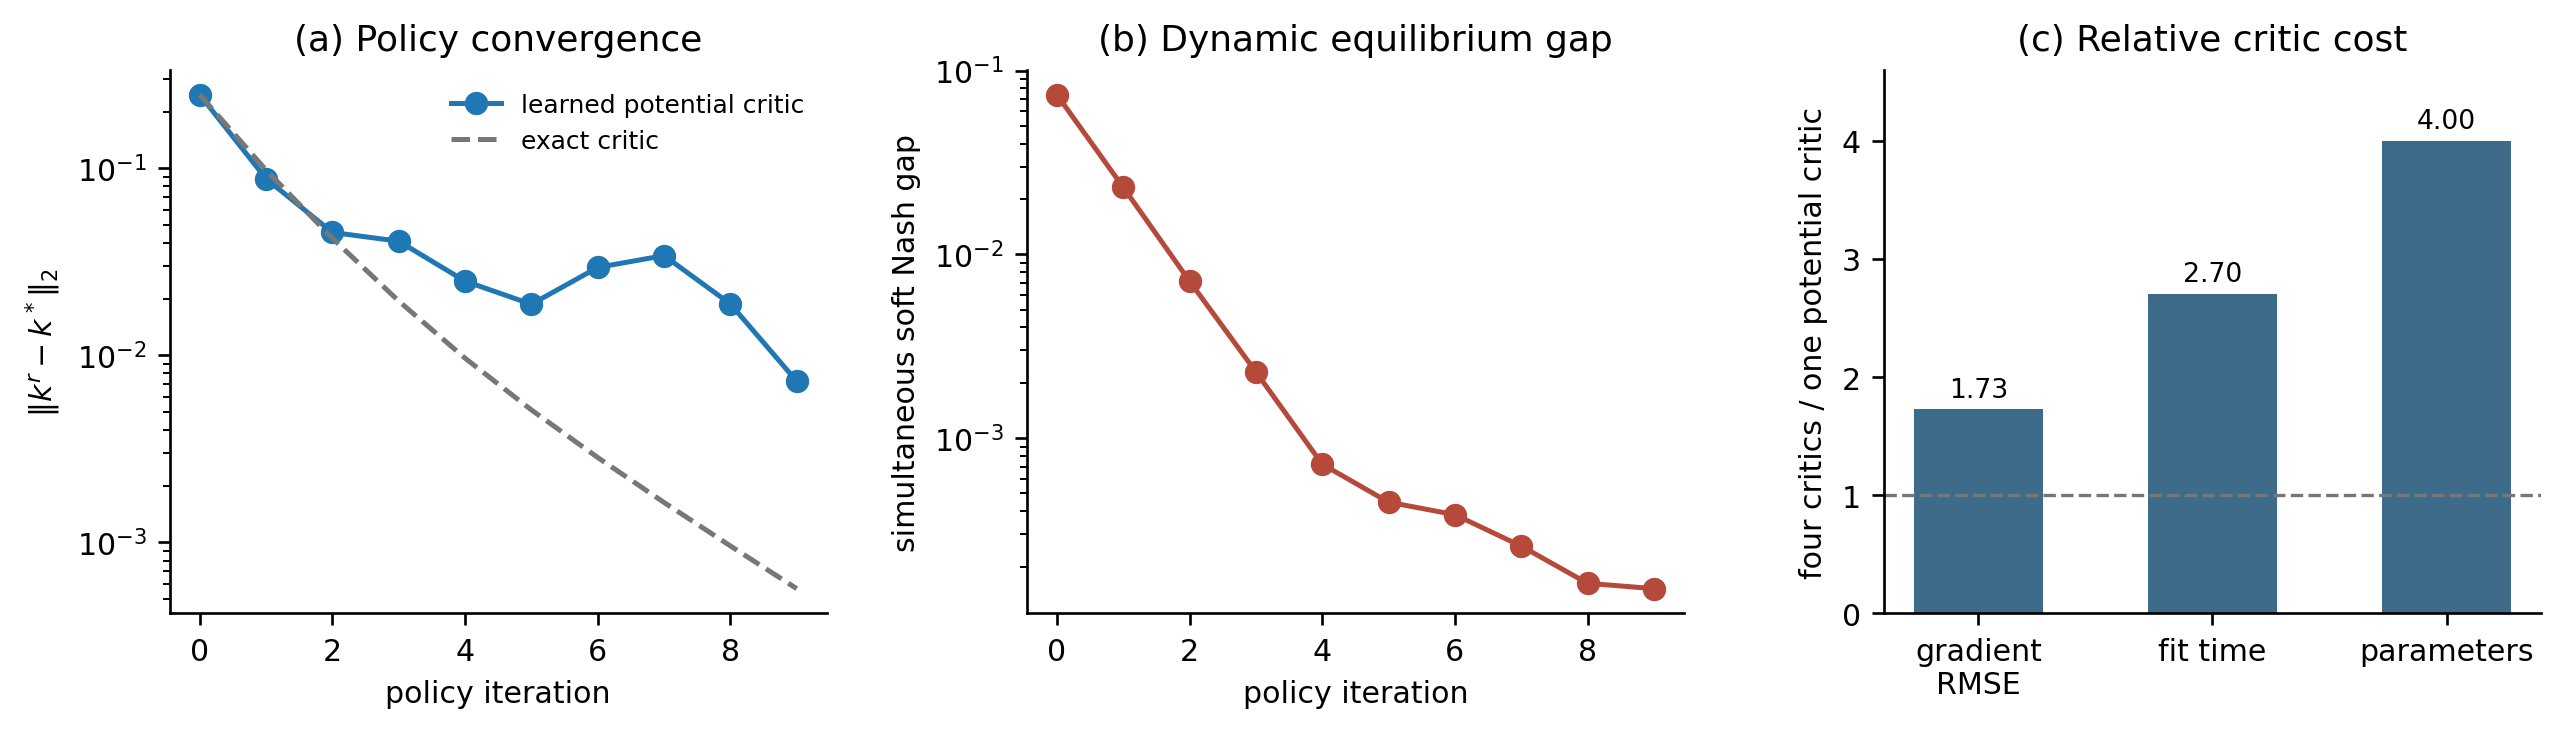

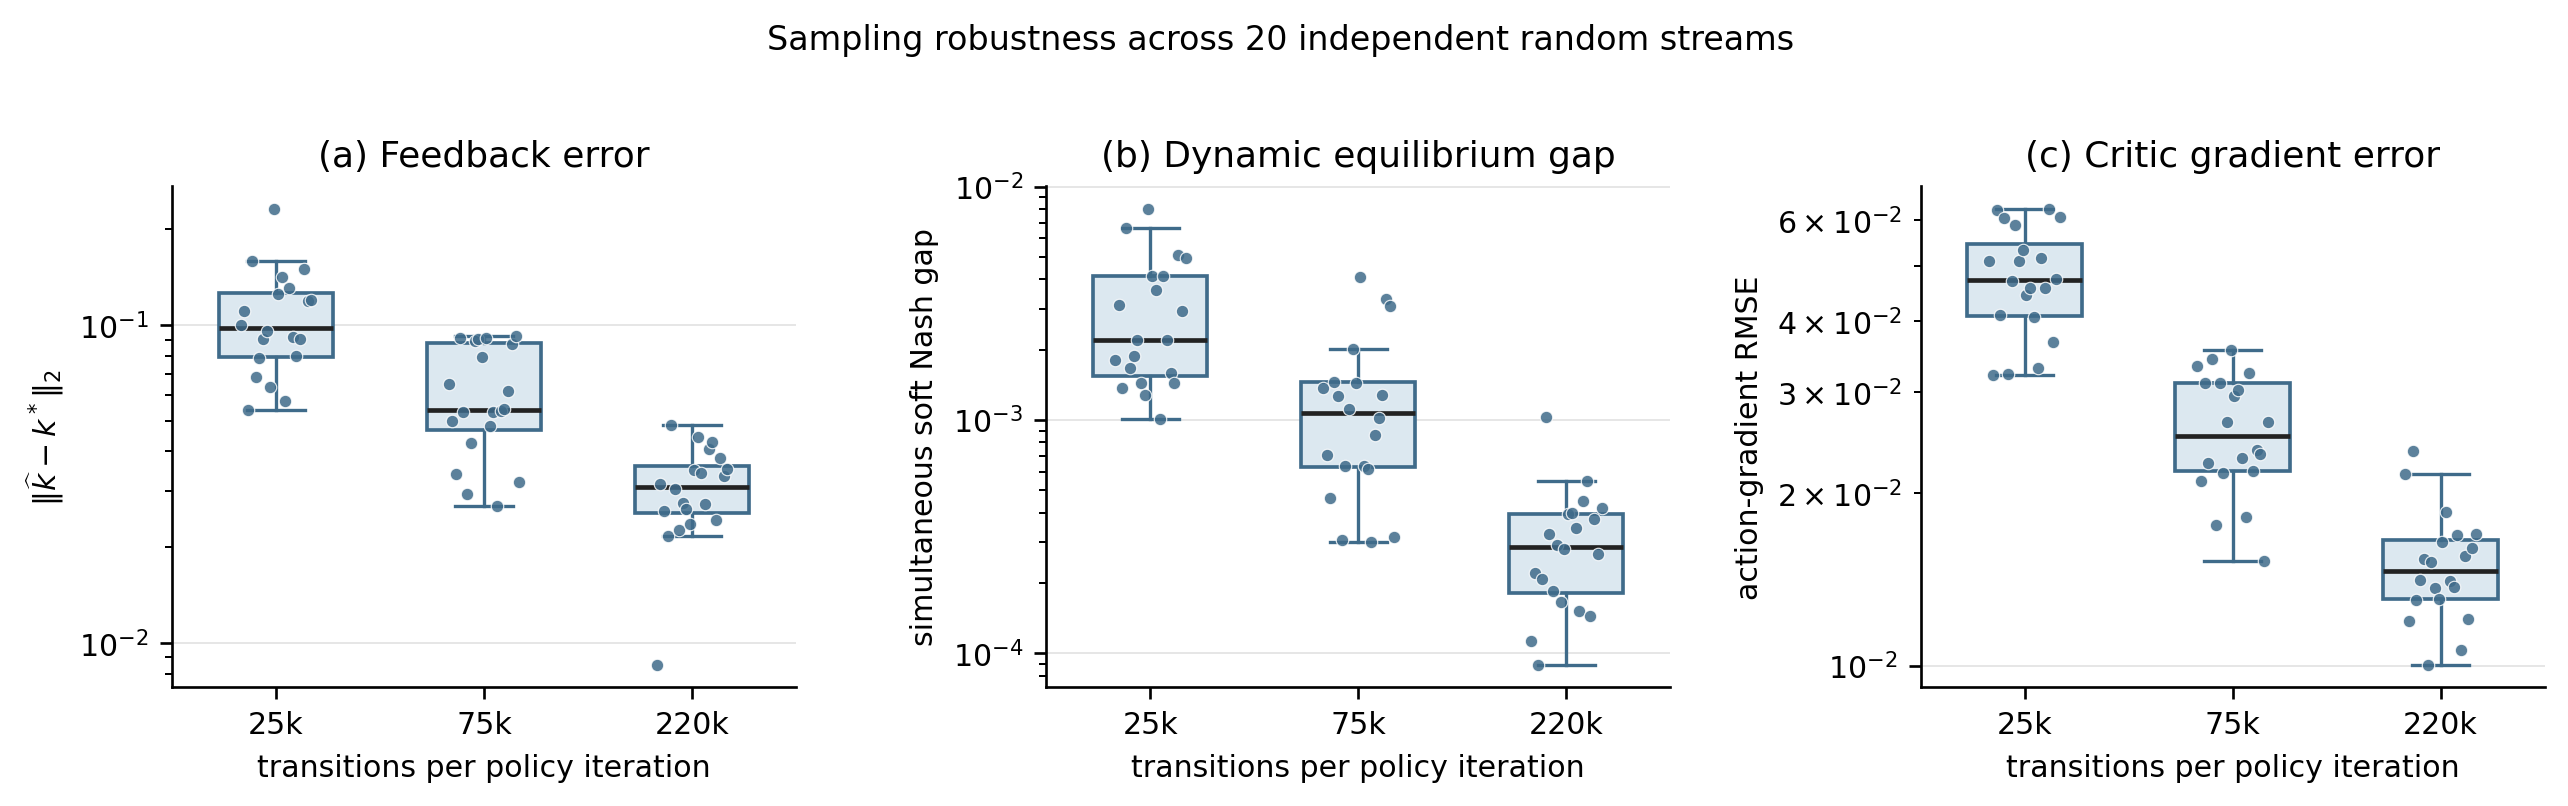

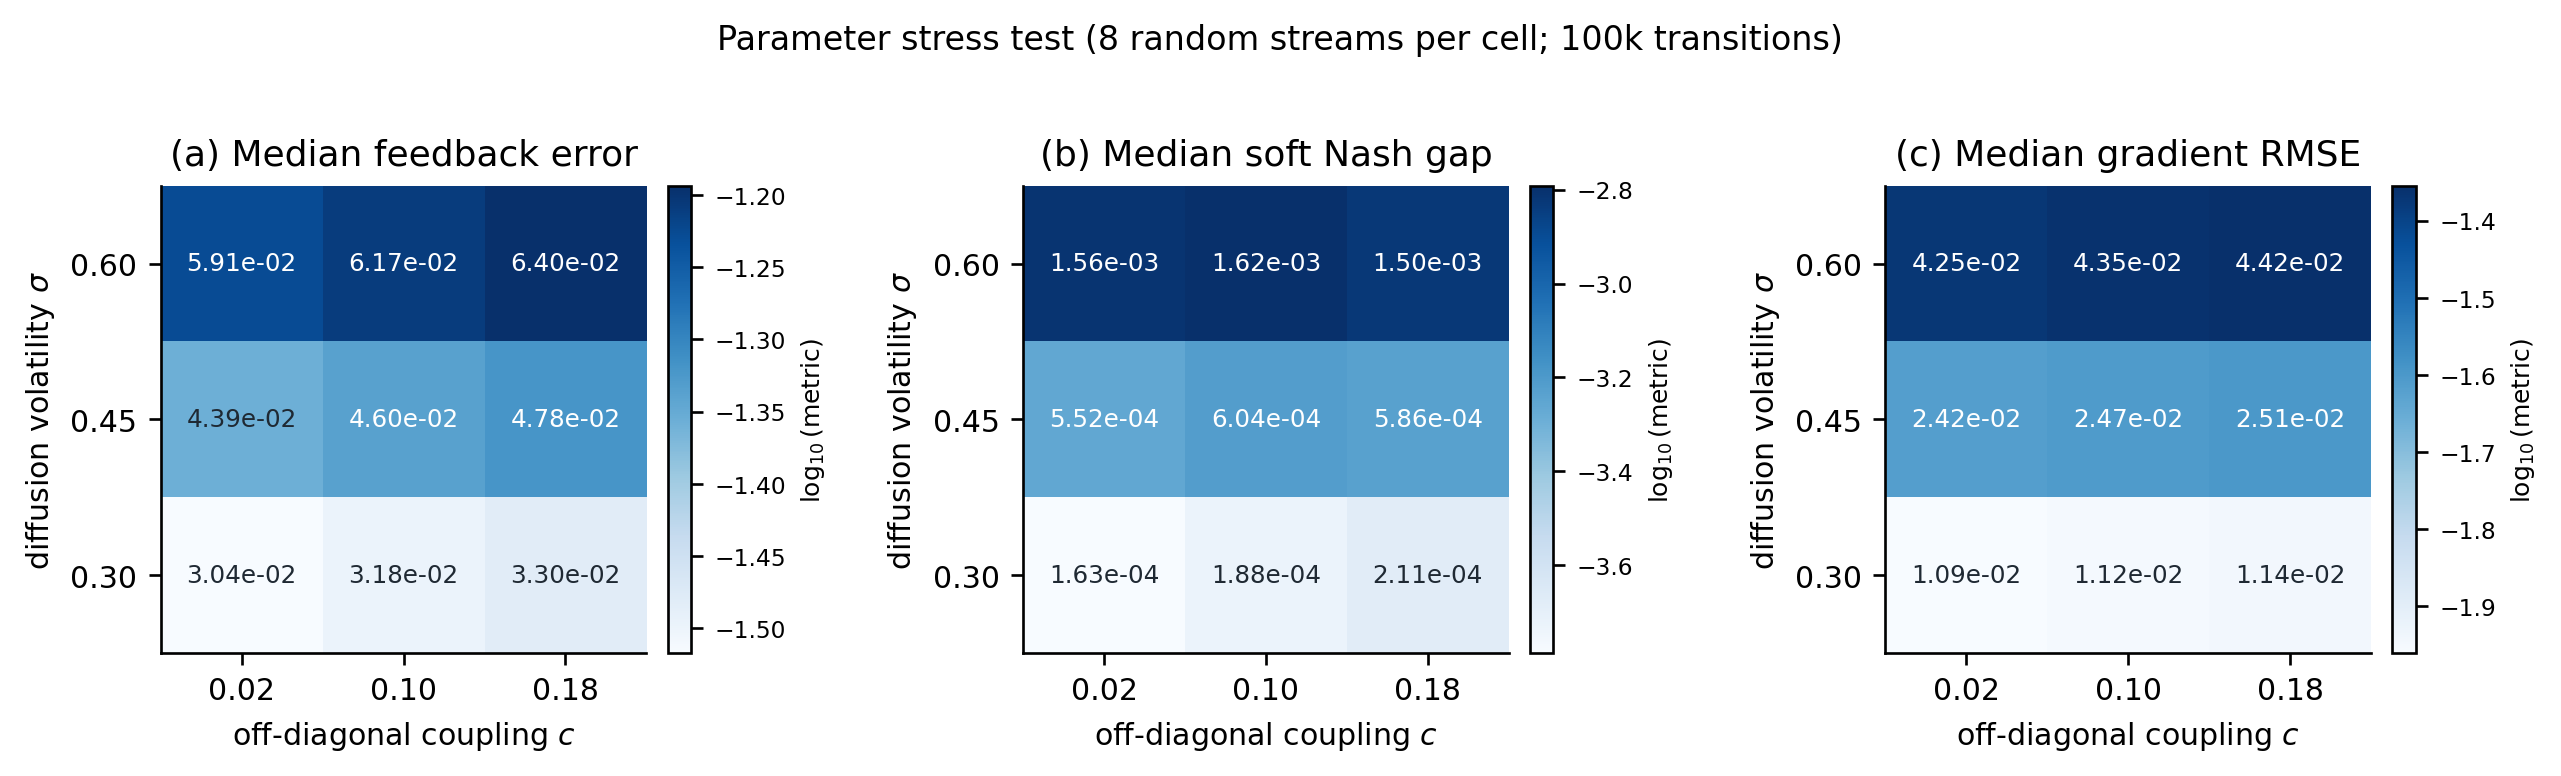

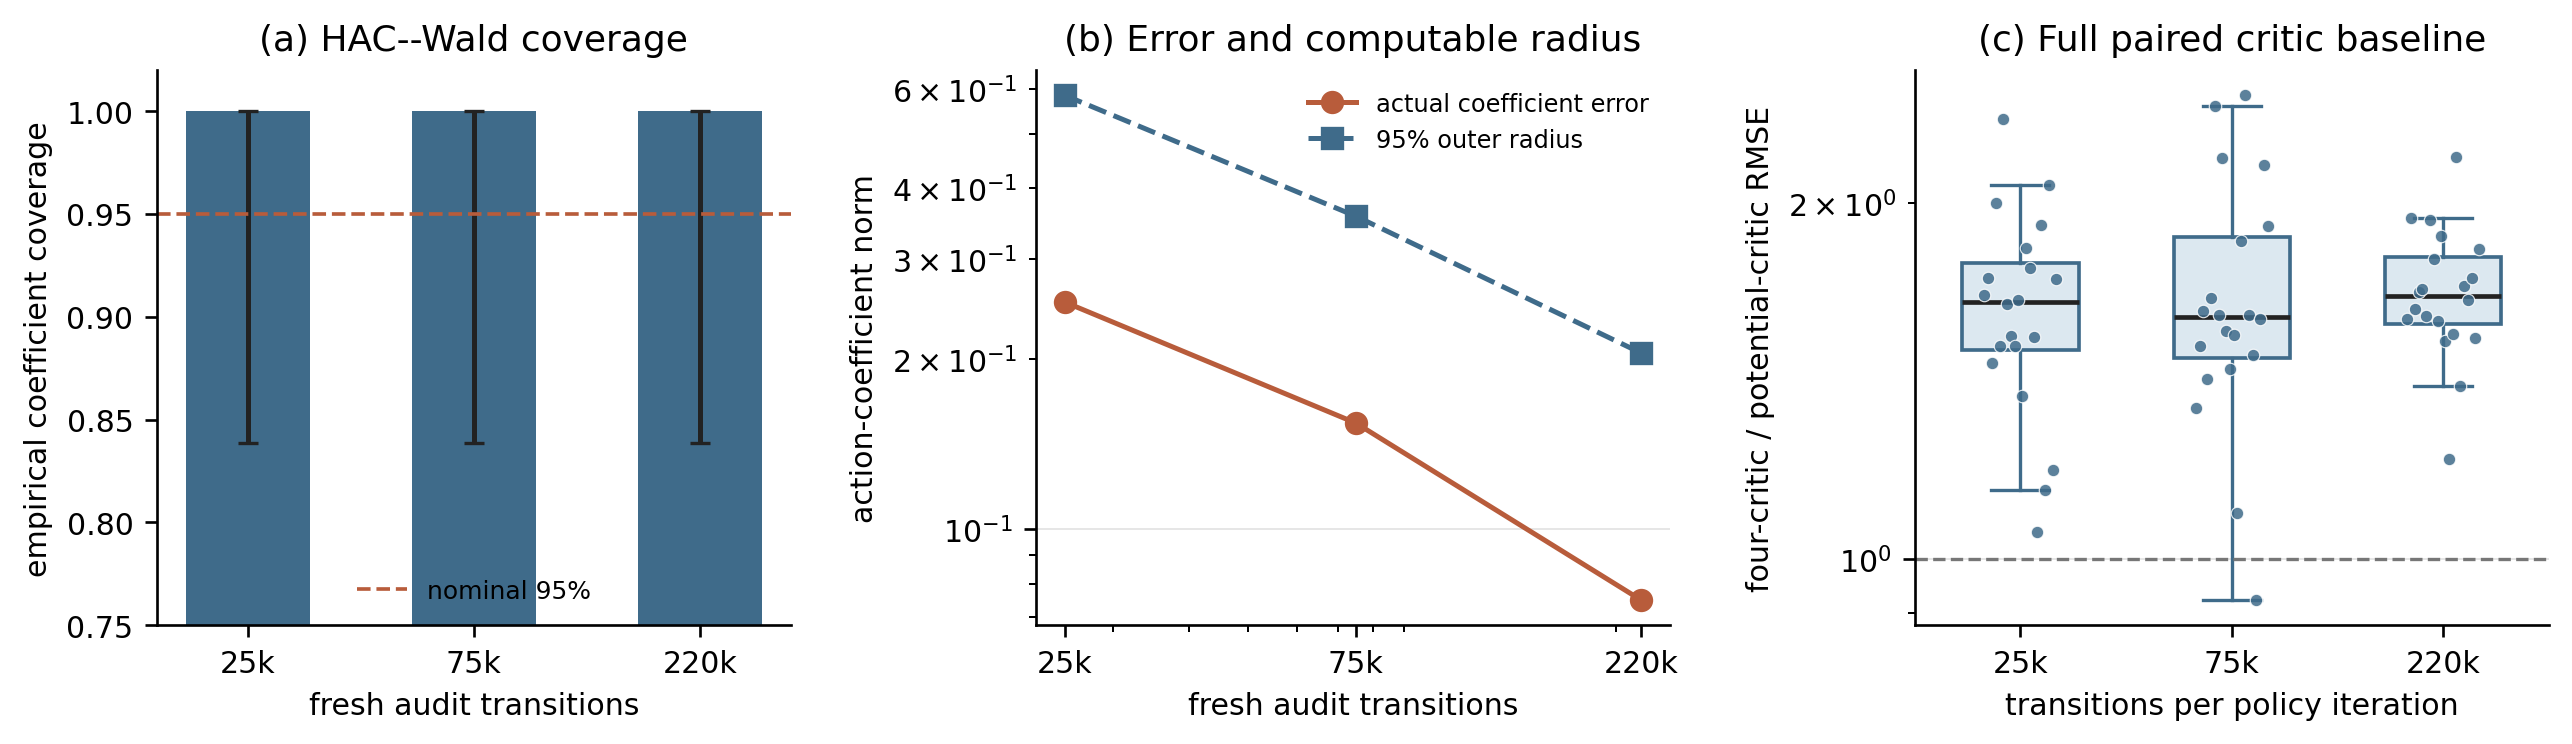

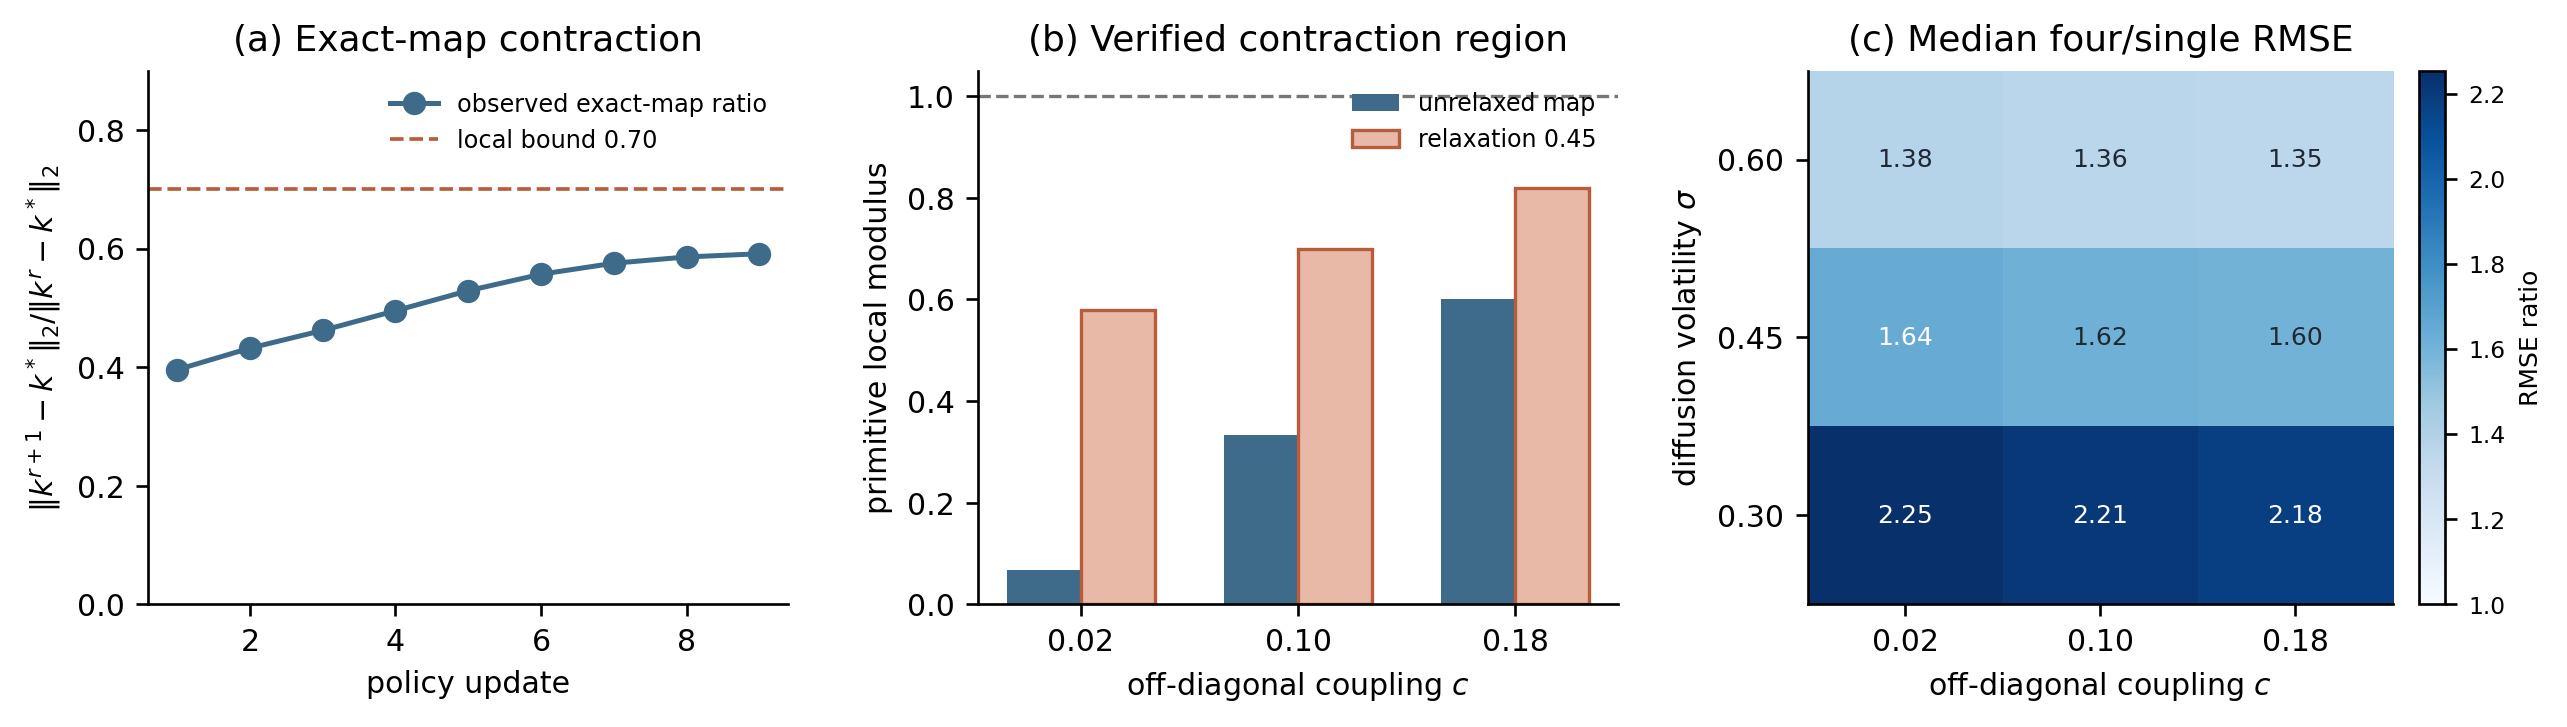

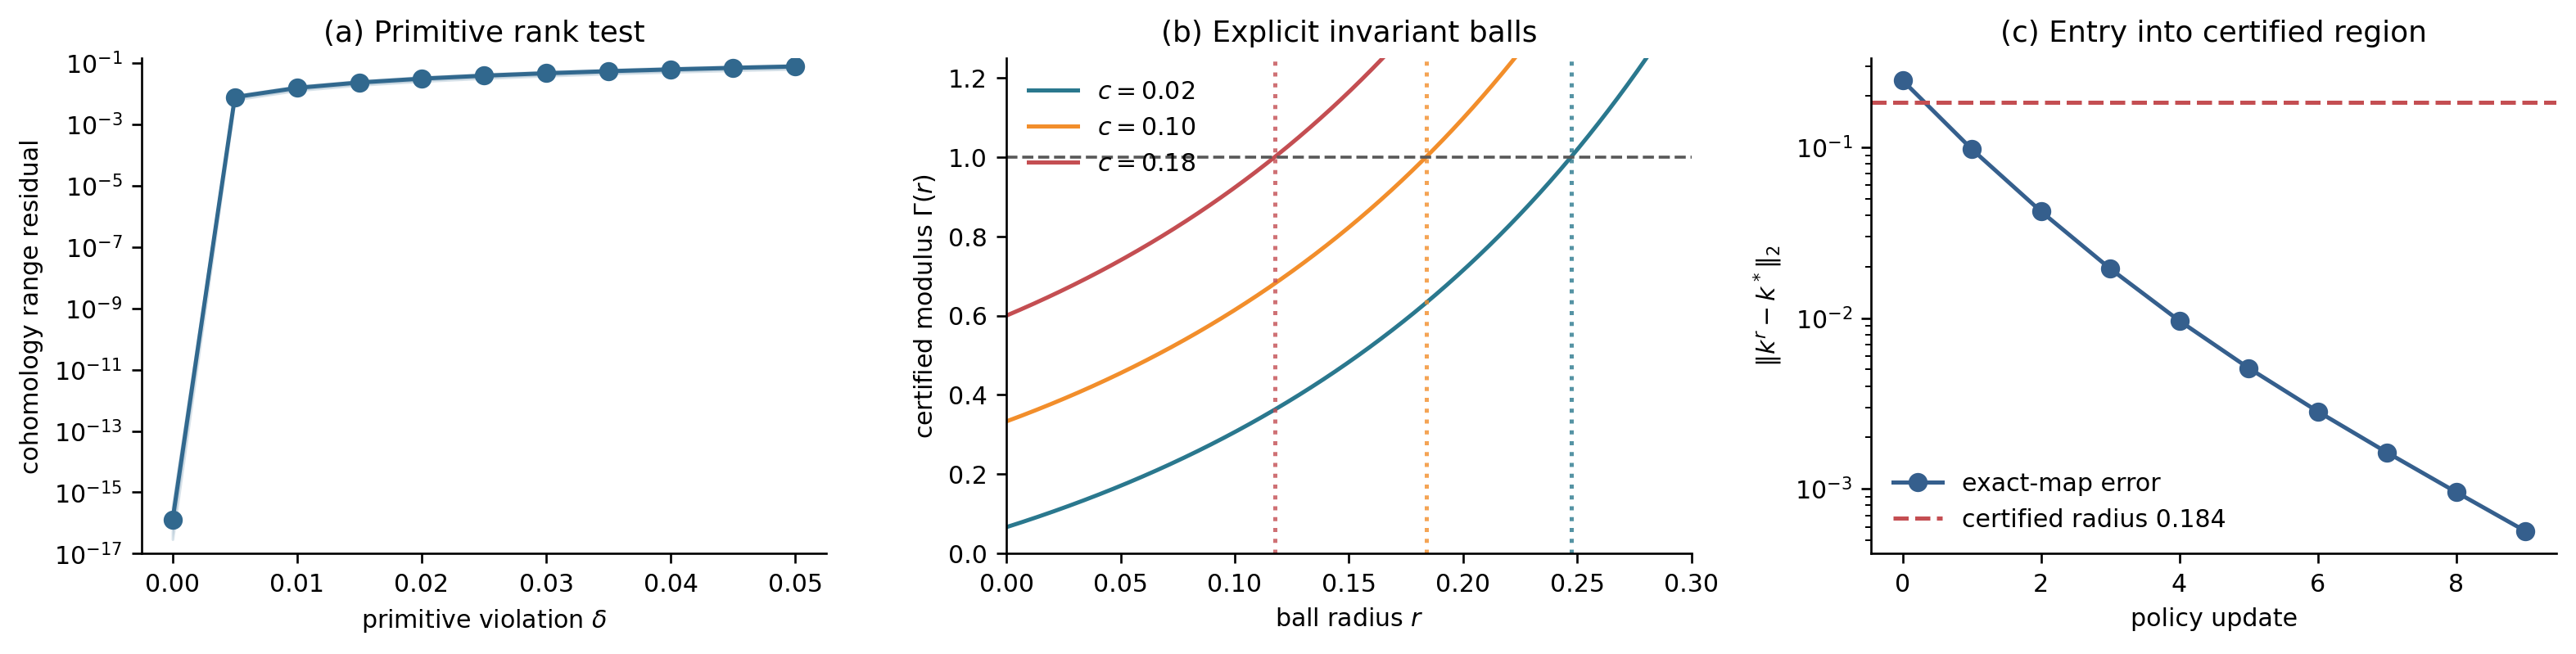

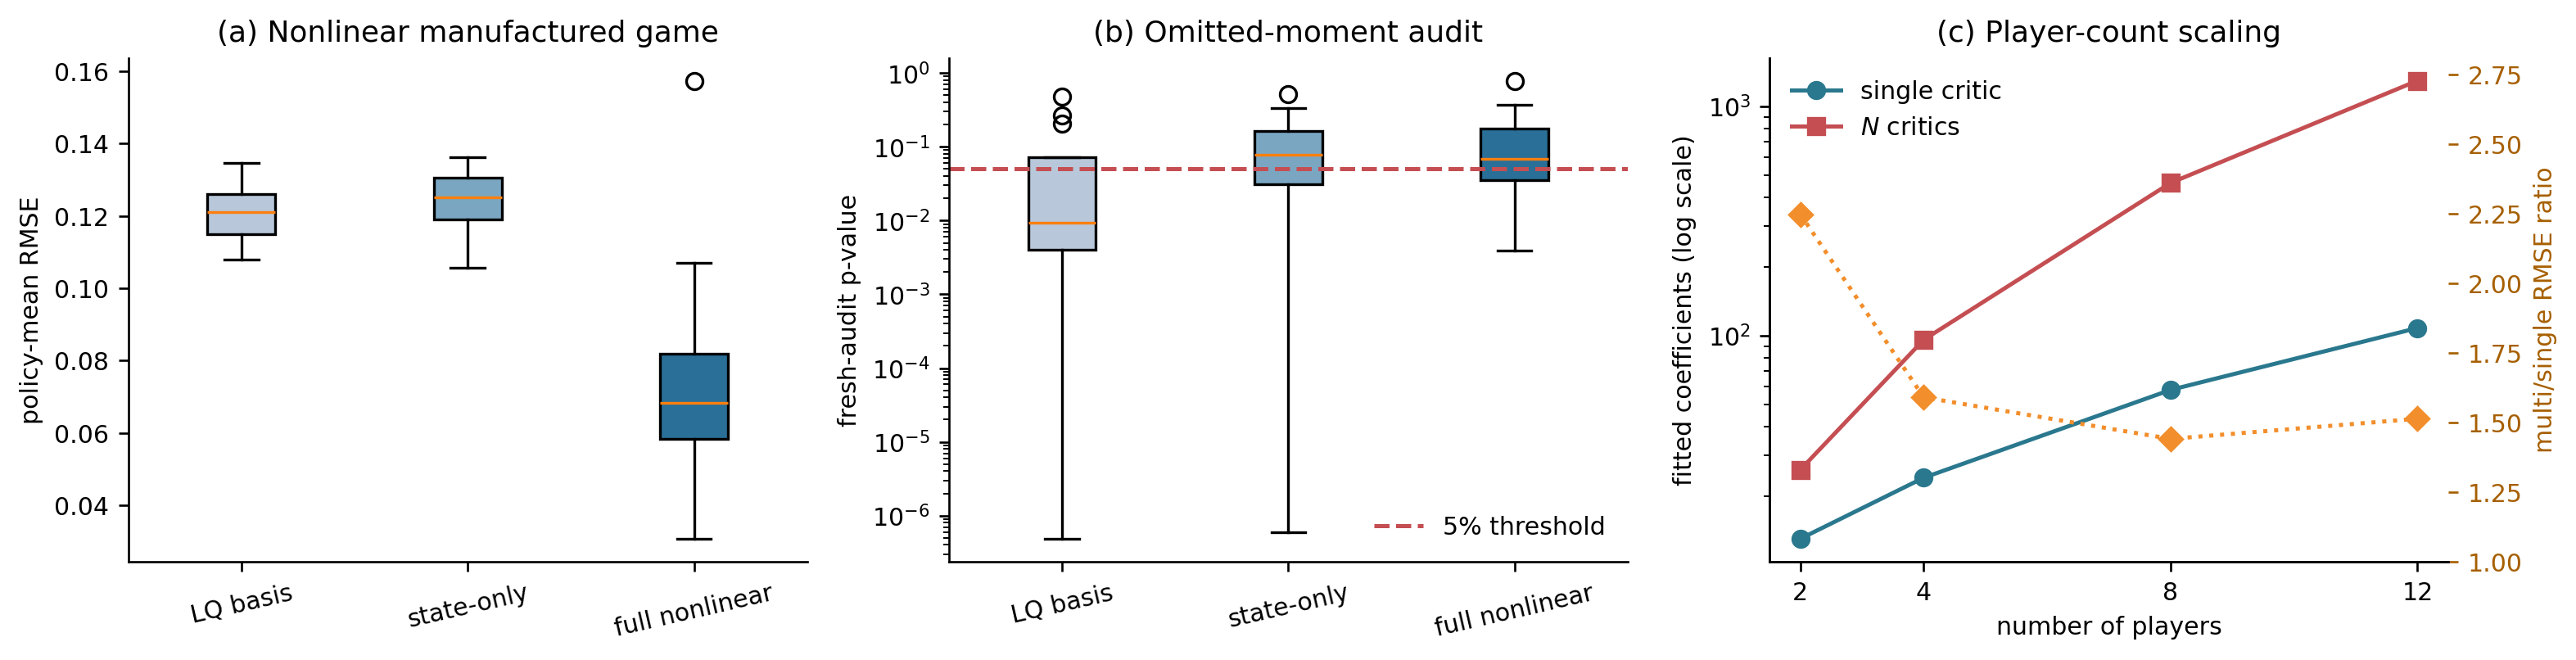

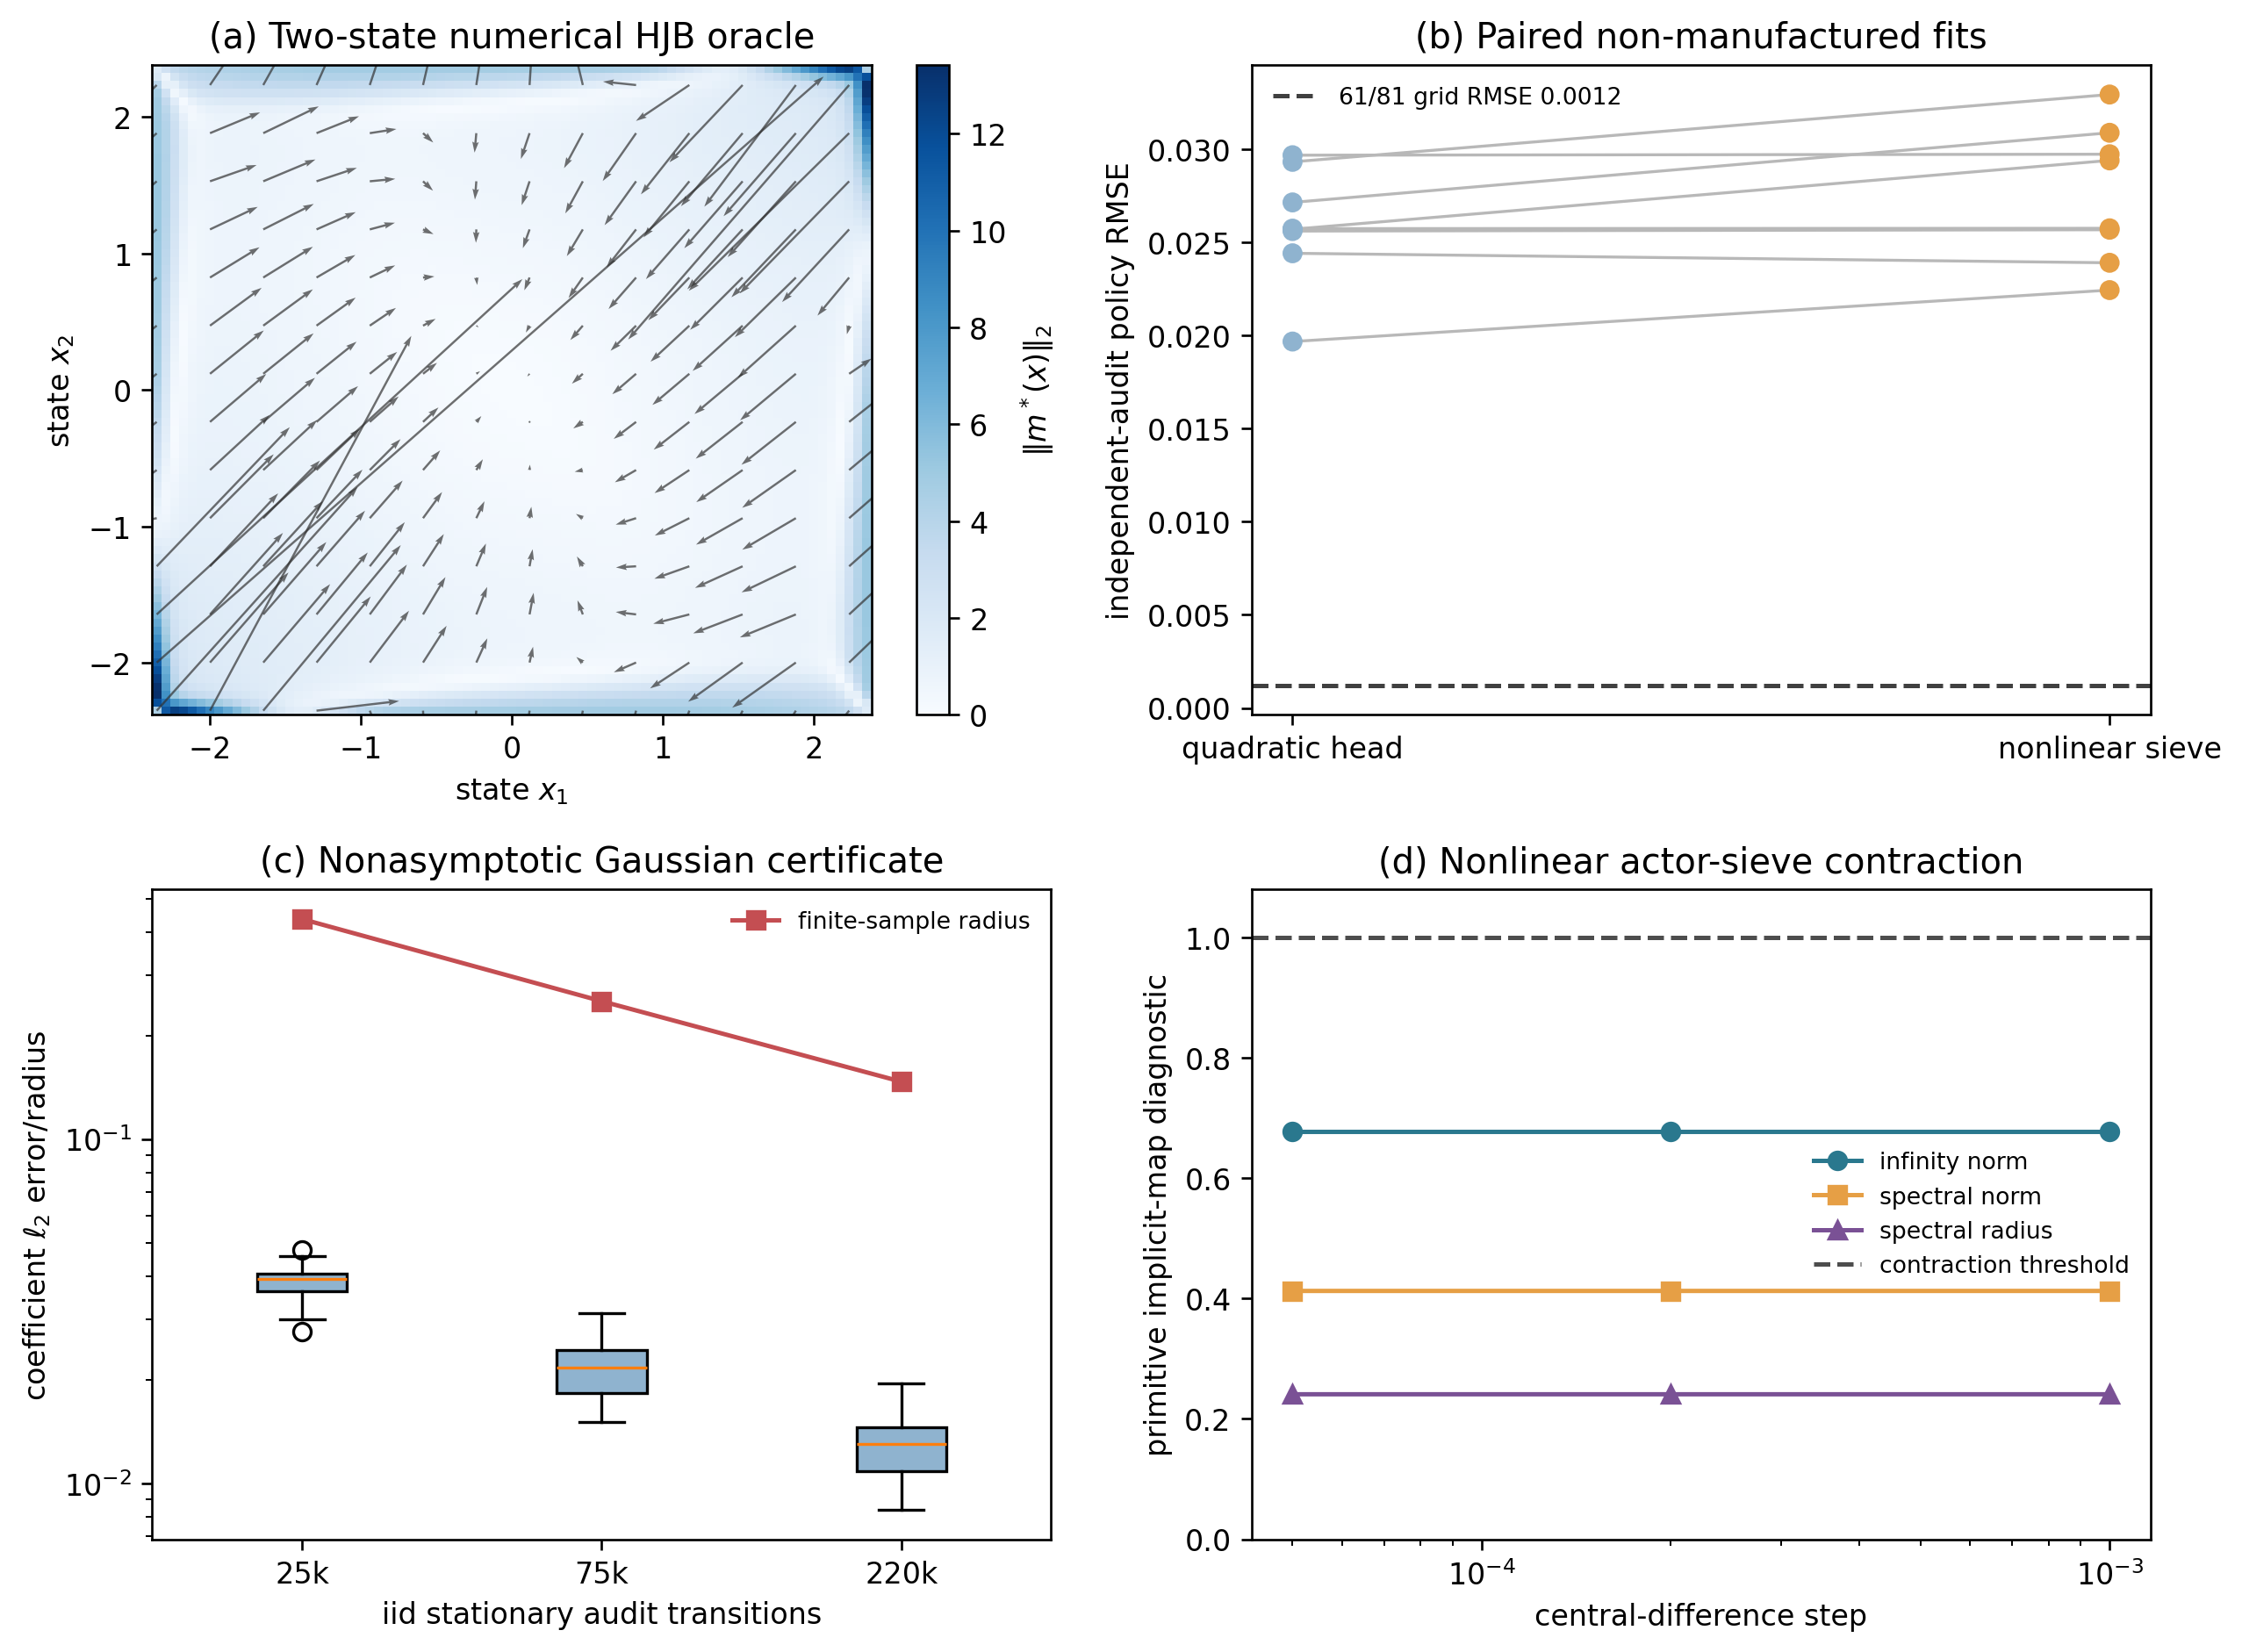

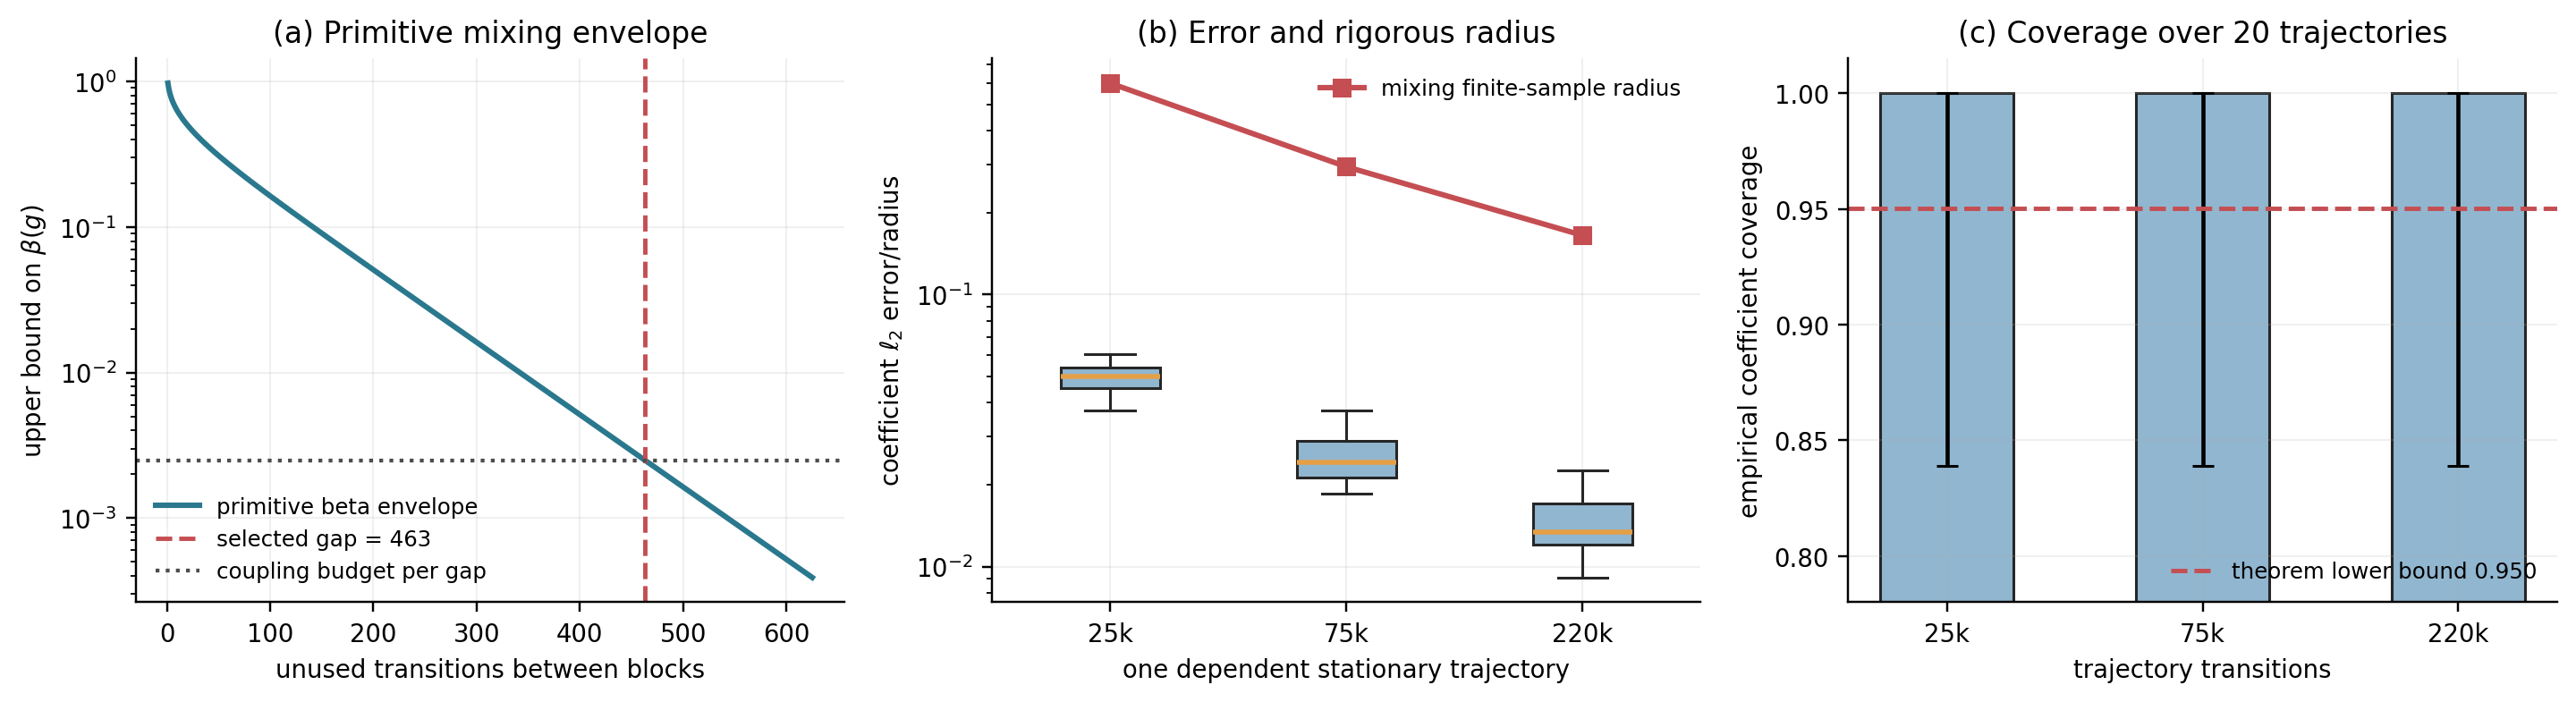

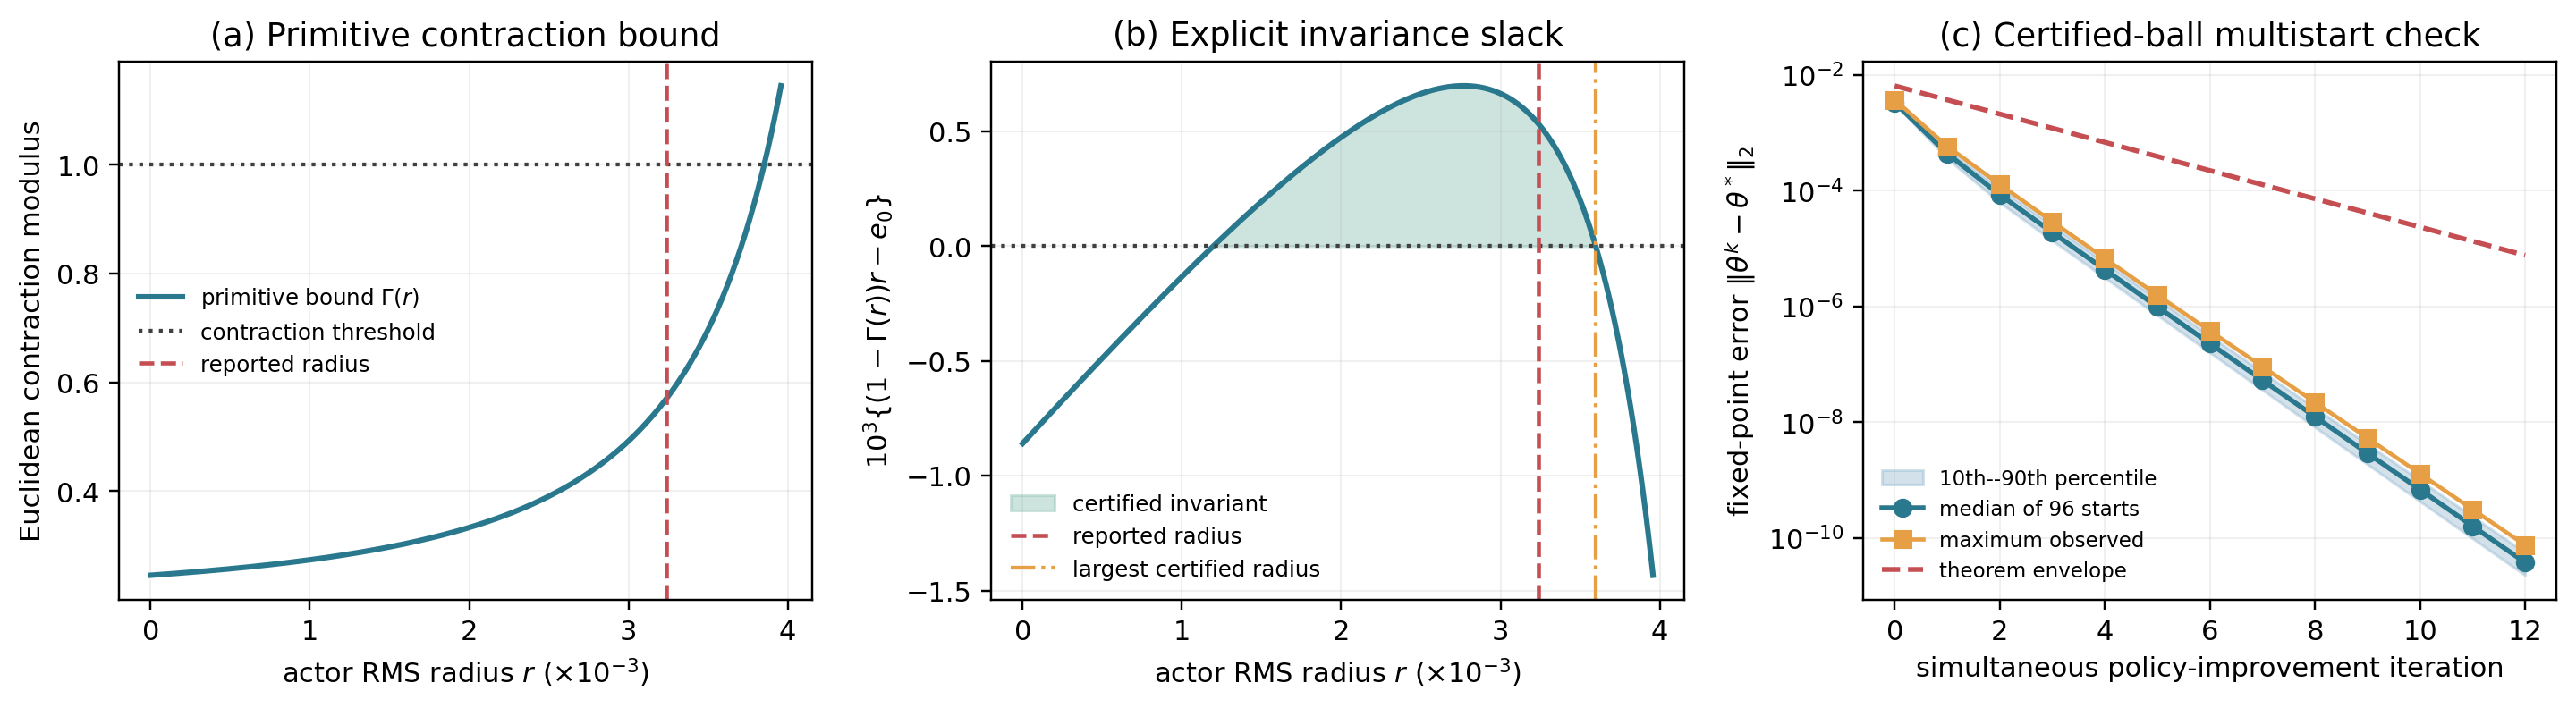

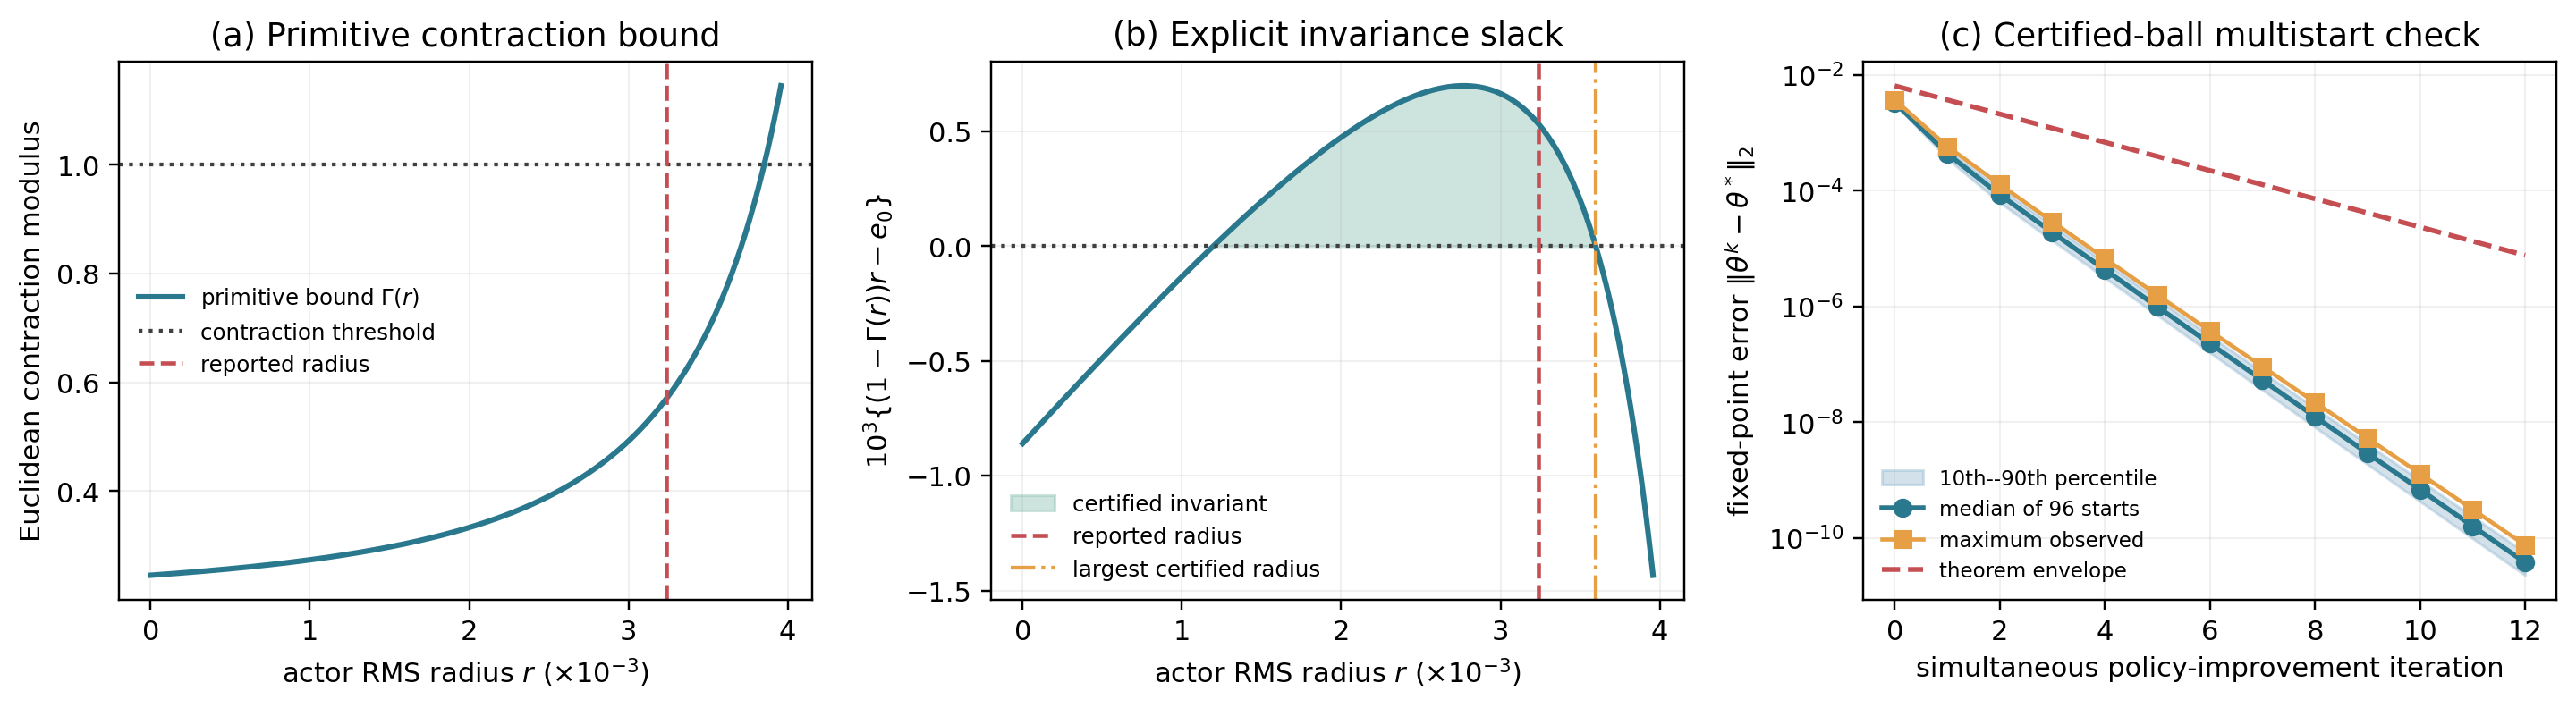

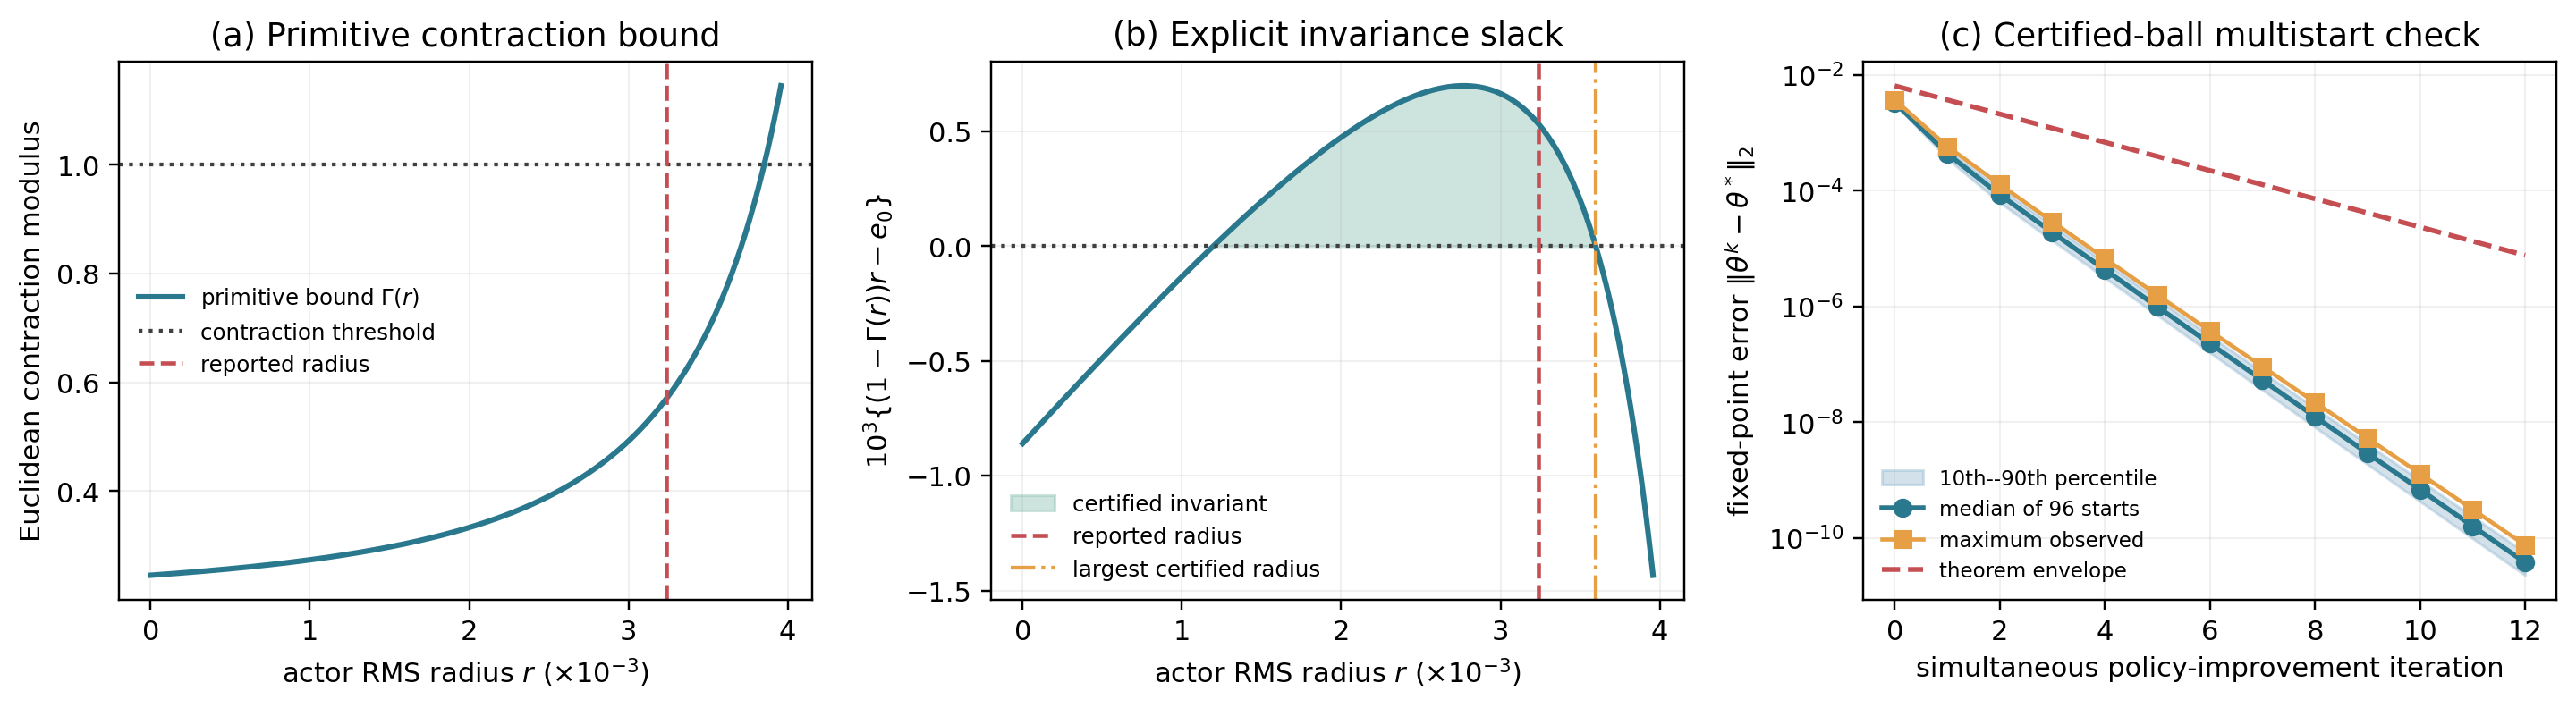

In [23]:
main_summary = json.loads(
    (NOTEBOOK_OUTPUT / "dynamic_lq_summary.json").read_text(encoding="utf-8")
)
three_front_summary = json.loads(
    (NOTEBOOK_OUTPUT / "three_front_validation_summary.json").read_text(encoding="utf-8")
)
nonlinear_ball_summary = json.loads(
    (NOTEBOOK_OUTPUT / "nonlinear_primitive_invariant_ball_summary.json").read_text(encoding="utf-8")
)
nonlinear_ball_summary = json.loads(
    (NOTEBOOK_OUTPUT / "nonlinear_primitive_invariant_ball_summary.json").read_text(encoding="utf-8")
)
nonlinear_ball_summary = json.loads(
    (NOTEBOOK_OUTPUT / "nonlinear_primitive_invariant_ball_summary.json").read_text(encoding="utf-8")
)
mixing_summary = json.loads(
    (NOTEBOOK_OUTPUT / "mixing_finite_sample_summary.json").read_text(encoding="utf-8")
)
higher_order_summary = json.loads(
    (NOTEBOOK_OUTPUT / "higher_order_validation_summary.json").read_text(encoding="utf-8")
)
robustness_summary = json.loads(
    (NOTEBOOK_OUTPUT / "dynamic_lq_robustness_summary.json").read_text(
        encoding="utf-8"
    )
)

headline = {
    "illustrative_feedback_error": main_summary["final_feedback_error"],
    "illustrative_soft_nash_gap": main_summary[
        "final_simultaneous_nash_gap"
    ],
    "220k_feedback_error_median": robustness_summary["sampling_results"][
        "feedback_error"
    ]["220000"]["median"],
    "220k_soft_nash_gap_median": robustness_summary["sampling_results"][
        "simultaneous_nash_gap"
    ]["220000"]["median"],
    "parameter_grid_soft_nash_gap_median": robustness_summary[
        "parameter_results"
    ]["simultaneous_nash_gap"]["overall_median"],
    "single_parameter_count": main_summary["single_parameter_count"],
    "four_critic_parameter_count": main_summary["n_critic_parameter_count"],
    "baseline_lq_local_modulus": main_summary["lq_local_contraction_modulus"],
    "baseline_relaxed_contraction_bound": main_summary["relaxed_local_contraction_bound"],
    "220k_audit_coverage": robustness_summary["audit_results"]["220000"]["empirical_coverage"],
    "220k_median_multi_to_single_rmse_ratio": robustness_summary["audit_results"]["220000"]["median_multi_to_single_rmse_ratio"],
}
print(json.dumps(headline, indent=2))

figure_files = [
    "fig_dynamic_lq_learning.png",
    "fig_dynamic_lq_sampling_robustness.png",
    "fig_dynamic_lq_parameter_stress.png",
    "fig_dynamic_lq_audit_coverage.png",
    "fig_dynamic_lq_contraction_baseline.png",
    "fig_primitive_cohomology_global_contraction.png",
    "fig_nonlinear_and_scaling.png",
    "fig_three_front_validation.png",
    "fig_mixing_finite_sample_certificate.png",
    "fig_nonlinear_primitive_invariant_ball.png",
    "fig_nonlinear_primitive_invariant_ball.png",
    "fig_nonlinear_primitive_invariant_ball.png",
]
for figure_name in figure_files:
    display(Image(filename=str(NOTEBOOK_OUTPUT / figure_name)))

## Reproducibility checks

In [24]:
with (NOTEBOOK_OUTPUT / "dynamic_lq_iterations.csv").open(
    newline="", encoding="utf-8"
) as stream:
    iteration_rows = list(csv.DictReader(stream))
with (NOTEBOOK_OUTPUT / "dynamic_lq_sampling_robustness.csv").open(
    newline="", encoding="utf-8"
) as stream:
    sampling_rows = list(csv.DictReader(stream))
with (NOTEBOOK_OUTPUT / "dynamic_lq_parameter_stress.csv").open(
    newline="", encoding="utf-8"
) as stream:
    parameter_rows = list(csv.DictReader(stream))

metrics = ["feedback_error", "simultaneous_nash_gap", "critic_gradient_rmse"]
learned_feedback = np.asarray(main_summary["learned_feedback"])
analytic_feedback = np.asarray(main_summary["analytic_feedback_star"])
recomputed_feedback_error = float(np.linalg.norm(learned_feedback - analytic_feedback))

recomputed_sampling_medians = {}
for metric in metrics:
    recomputed_sampling_medians[metric] = {}
    for sample_size in (25_000, 75_000, 220_000):
        values = [
            float(row[metric])
            for row in sampling_rows
            if int(row["samples_per_iteration"]) == sample_size
        ]
        recomputed_sampling_medians[metric][sample_size] = float(np.median(values))

audit_coverages = {
    sample_size: np.mean(
        [
            row["audit_estimator_covered"] == "True"
            for row in sampling_rows
            if int(row["samples_per_iteration"]) == sample_size
        ]
    )
    for sample_size in (25_000, 75_000, 220_000)
}
all_figures = [
    "fig_dynamic_lq_learning.pdf",
    "fig_dynamic_lq_sampling_robustness.pdf",
    "fig_dynamic_lq_parameter_stress.pdf",
    "fig_dynamic_lq_audit_coverage.pdf",
    "fig_dynamic_lq_contraction_baseline.pdf",
    "fig_primitive_cohomology_global_contraction.pdf",
    "fig_nonlinear_and_scaling.pdf",
    "fig_three_front_validation.pdf",
    "fig_mixing_finite_sample_certificate.pdf",
    "fig_nonlinear_primitive_invariant_ball.pdf",
    "fig_nonlinear_primitive_invariant_ball.pdf",
    "fig_nonlinear_primitive_invariant_ball.pdf",
]

checks = {
    "ten main evaluation rounds": len(iteration_rows) == 10,
    "main feedback error recomputes": np.isclose(
        recomputed_feedback_error, main_summary["final_feedback_error"], rtol=1e-12
    ),
    "60 sampling-study runs": len(sampling_rows) == 60,
    "72 parameter-stress runs": len(parameter_rows) == 72,
    "all primary metrics are finite and nonnegative": all(
        np.isfinite(float(row[metric])) and float(row[metric]) >= 0.0
        for row in sampling_rows + parameter_rows
        for metric in metrics
    ),
    "all four-critic baselines were fitted": all(
        np.isfinite(float(row["multi_critic_mean_gradient_rmse"]))
        and float(row["multi_critic_mean_gradient_rmse"]) >= 0.0
        for row in sampling_rows + parameter_rows
    ),
    "20 runs at each sample size": all(
        sum(int(row["samples_per_iteration"]) == size for row in sampling_rows) == 20
        for size in (25_000, 75_000, 220_000)
    ),
    "8 runs in every parameter cell": all(
        sum(
            np.isclose(float(row["sigma"]), sigma)
            and np.isclose(float(row["offdiag_coupling"]), coupling)
            for row in parameter_rows
        ) == 8
        for sigma in (0.30, 0.45, 0.60)
        for coupling in (0.02, 0.10, 0.18)
    ),
    "sampling medians reproduce saved summary": all(
        np.isclose(
            recomputed_sampling_medians[metric][size],
            robustness_summary["sampling_results"][metric][str(size)]["median"],
            rtol=1e-12,
        )
        for metric in metrics
        for size in (25_000, 75_000, 220_000)
    ),
    "all three median errors decrease with sample size": all(
        recomputed_sampling_medians[metric][25_000]
        > recomputed_sampling_medians[metric][75_000]
        > recomputed_sampling_medians[metric][220_000]
        for metric in metrics
    ),
    "fresh-audit empirical coverage is at least 90 percent": all(
        coverage >= 0.90 for coverage in audit_coverages.values()
    ),
    "operational radius covers every frozen critic in this design": all(
        row["operational_audit_covered"] == "True"
        for row in sampling_rows + parameter_rows
    ),
    "primitive LQ contraction condition holds in every cell": all(
        float(row["lq_local_contraction_modulus"]) < 1.0
        and float(row["relaxed_local_contraction_bound"]) < 1.0
        for row in parameter_rows
    ),
    "exact-map observed ratios respect baseline local bound": all(
        float(iteration_rows[k]["exact_feedback_error"])
        / float(iteration_rows[k - 1]["exact_feedback_error"])
        <= main_summary["relaxed_local_contraction_bound"] + 1e-12
        for k in range(1, len(iteration_rows))
    ),
    "parameter accounting": main_summary["single_parameter_count"] == 24
    and main_summary["n_critic_parameter_count"] == 96,
    "all ten final figures exist": all((NOTEBOOK_OUTPUT / name).exists() for name in all_figures),
}

with (NOTEBOOK_OUTPUT / "higher_order_validation_summary.json").open(encoding="utf-8") as stream:
    higher_order_summary = json.load(stream)
checks.update({
    "primitive exact game passes range test": higher_order_summary[
        "primitive_exact_max_residual"
    ] < 1e-12,
    "primitive violation is detected": higher_order_summary[
        "primitive_largest_perturbation_median_residual"
    ] > 1e-3,
    "all coupling cells have a positive certified nonlocal radius": all(
        float(radius) > 0.10
        for radius in higher_order_summary["certified_nonlocal_radii"].values()
    ),
    "nonlinear enrichment improves deployed policy error": higher_order_summary[
        "nonlinear_policy_rmse_medians"
    ]["fully_enriched"] < higher_order_summary[
        "nonlinear_policy_rmse_medians"
    ]["quadratic"],
    "player scaling reaches twelve players": higher_order_summary["scaling"]["12"][
        "multi_parameter_count"
    ] == 12 * higher_order_summary["scaling"]["12"]["single_parameter_count"],
})
three_front_summary = json.loads(
    (NOTEBOOK_OUTPUT / "three_front_validation_summary.json").read_text(encoding="utf-8")
)
checks.update({
    "two-state HJB oracle is grid stable": three_front_summary[
        "nonmanufactured_grid_policy_rmse_61_vs_81"
    ] < 2e-3,
    "two-state trajectories remain inside the oracle grid": three_front_summary[
        "maximum_state_outside_oracle_grid_rate"
    ] == 0.0,
    "non-manufactured critic error is finite": all(
        np.isfinite(value) and value < 0.10
        for value in three_front_summary["nonmanufactured_policy_rmse_medians"].values()
    ),
    "negative nonlinear-sieve result is retained": three_front_summary[
        "nonlinear_sieve_paired_policy_wins"
    ] < 4,
    "finite-sample restart certificate covers all reported streams": all(
        three_front_summary["mom"][str(size)]["coverage"] == 1.0
        for size in (25_000, 75_000, 220_000)
    ),
    "finite-sample restart radius shrinks with n":
        three_front_summary["mom"]["25000"]["radius"]
        > three_front_summary["mom"]["75000"]["radius"]
        > three_front_summary["mom"]["220000"]["radius"],
    "nonlinear primitive implicit map is contractive": max(
        row["jacobian_infinity_norm"]
        for row in three_front_summary["nonlinear_contraction"]
    ) < 1.0,
})
mixing_summary = json.loads(
    (NOTEBOOK_OUTPUT / "mixing_finite_sample_summary.json").read_text(encoding="utf-8")
)
checks.update({
    "mixing theorem spends at most five percent failure probability":
        mixing_summary["total_failure_bound"] <= 0.05,
    "dependent mixing certificate covers all reported trajectories": all(
        mixing_summary["results"][str(size)]["coverage"] == 1.0
        for size in (25_000, 75_000, 220_000)
    ),
    "dependent finite-sample radius shrinks with n":
        mixing_summary["results"]["25000"]["radius"]
        > mixing_summary["results"]["75000"]["radius"]
        > mixing_summary["results"]["220000"]["radius"],
    "primitive stationary variance matches dependent paths":
        mixing_summary["median_relative_state_variance_error"] < 0.10,
    "primitive AR coefficient matches dependent paths":
        mixing_summary["median_absolute_lag1_correlation_error"] < 0.01,
})


nonlinear_ball_summary = json.loads(
    (NOTEBOOK_OUTPUT / "nonlinear_primitive_invariant_ball_summary.json").read_text(encoding="utf-8")
)
checks.update({
    "nonlinear primitive invariant radius is positive":
        nonlinear_ball_summary["certified_radius"] > 0.0,
    "nonlinear primitive modulus is strictly contractive":
        nonlinear_ball_summary["certificate"]["modulus"] < 1.0,
    "nonlinear primitive invariance slack is positive":
        nonlinear_ball_summary["certificate"]["invariance_slack"] > 0.0,
    "nonlinear evaluation remains invertible on the certified ball":
        nonlinear_ball_summary["certificate"]["inverse_margin"] > 0.0,
    "all nonlinear boundary starts remain inside the theorem envelope":
        nonlinear_ball_summary["stress_test"]["all_fixed_point_errors_below_theoretical_envelope"],
    "all nonlinear boundary images remain inside the ball":
        nonlinear_ball_summary["stress_test"]["all_first_images_inside_ball"],
    "all nonlinear multistart iterates remain inside the ball":
        nonlinear_ball_summary["stress_test"]["all_iterates_inside_ball"],
})
assert all(checks.values()), checks
for name, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")


[PASS] ten main evaluation rounds
[PASS] main feedback error recomputes
[PASS] 60 sampling-study runs
[PASS] 72 parameter-stress runs
[PASS] all primary metrics are finite and nonnegative
[PASS] all four-critic baselines were fitted
[PASS] 20 runs at each sample size
[PASS] 8 runs in every parameter cell
[PASS] sampling medians reproduce saved summary
[PASS] all three median errors decrease with sample size
[PASS] fresh-audit empirical coverage is at least 90 percent
[PASS] operational radius covers every frozen critic in this design
[PASS] primitive LQ contraction condition holds in every cell
[PASS] exact-map observed ratios respect baseline local bound
[PASS] parameter accounting
[PASS] all ten final figures exist
[PASS] primitive exact game passes range test
[PASS] primitive violation is detected
[PASS] all coupling cells have a positive certified nonlocal radius
[PASS] nonlinear enrichment improves deployed policy error
[PASS] player scaling reaches twelve players
[PASS] two-state

## Takeaways

1. Larger samples reduce policy error, exact dynamic Nash gap, and critic-gradient error across independent streams.
2. The fresh-trajectory HAC--Wald audit is fully computable from the frozen critic and audit moments. Its empirical coefficient coverage is reported rather than assumed.
3. In the exactly specified LQ family, the structural curl and projection errors are zero; the reported audit therefore isolates statistical error and moment conditioning.
4. The Riccati policy map has the explicit local modulus \(\max_i\sum_{j\ne i}|R_{ij}|/R_{ii}\). Every tested coupling cell lies below one, and the observed exact-map ratios respect the relaxed local bound.
5. All four player critics are refitted for every one of the 132 panel runs. The potential critic retains the exact 24-versus-96 coefficient advantage; timing remains machine dependent.
6. The primitive cohomology rank residual is zero in the exact game and positive under a non-realizable reward perturbation.
7. The nonlocal LQ theorem certifies an explicit invariant ball in every coupling cell.
8. A manufactured nonlinear diffusion exposes LQ-basis misspecification, while the player-scaling study separates shared-input growth from critic replication. These experiments do not establish general nonparametric robustness.
9. The two-state non-manufactured HJB benchmark is grid-stable and all audit trajectories remain inside its domain; the richer nonlinear sieve has lower population approximation bias but loses to the quadratic head in 7 of 8 finite-sample policy comparisons.
10. Independent stationary restarts permit a genuine finite-sample median-of-means certificate for the unbounded Gaussian LQ critic; this conclusion does not extend to a single dependent trajectory.
11. The nonlinear actor-sieve evaluation and improvement matrices give a stable local implicit-map Jacobian; this diagnostic is now separated from the global-on-a-ball certificate.
12. One stationary dependent trajectory now has a rigorous finite-sample coefficient certificate: the primitive Gaussian AR mixing envelope selects the block gap, the complete failure bound is below 5%, and the radius shrinks over all three sample sizes. This does not cover nonstationary or unknown-mixing dynamics.
13. The two-state nonlinear control-affine sieve has a fully explicit residual-centered invariant ball. All primitive constants, the positive radius, the contraction modulus, and the invariance slack are saved; 96 boundary starts satisfy the deterministic theorem envelope.